# Comparative Study of Deep CNN Architectures Using Transfer Learning

## Aim
To study the evolution of deep CNN architectures, understand and implement transfer learning using a pretrained CNN (VGG16) on CIFAR-10, fine-tune the pretrained model, and compare classification performance before and after fine-tuning using standard evaluation metrics.

## Objectives
1. Study the evolution of deep CNN architectures (LeNet-5, AlexNet, VGG16, GoogleNet, ResNet).
2. Compare these architectures in terms of depth, parameters, and key contributions.
3. Understand and implement transfer learning using a pretrained VGG16 model.
4. Fine-tune the pretrained model and compare performance before/after fine-tuning.
5. Evaluate the model using accuracy, precision, recall, F1-score, confusion matrix, and classification report.
6. Study the effect of key hyperparameters (learning rate, optimizer, batch size, frozen vs. partial fine-tuning).

## Dataset
**CIFAR-10**: 60,000 32×32 color images in 10 classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck) — 50,000 training images, 10,000 test images.


## 1. Setup: Fonts and Imports

In [9]:
!wget -q -O "TimesNewRoman.ttf" "https://raw.githubusercontent.com/justrajdeep/fonts/master/Times%20New%20Roman.ttf"

import matplotlib
import matplotlib.font_manager as font_manager
import shutil as _shutil
_shutil.rmtree(matplotlib.get_cachedir(), ignore_errors=True)

font_manager.fontManager.addfont("TimesNewRoman.ttf")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.datasets import cifar10
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score, accuracy_score)
import time

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

np.random.seed(42)
tf.random.set_seed(42)


TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Global Plot Formatting (600 DPI, Times New Roman, EPS export)

In [10]:
# Global Plot Formatting

plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.dpi'] = 600

plt.rcParams['font.family'] = 'Times New Roman'

plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

plt.rcParams['axes.labelsize'] = 15
plt.rcParams['axes.titlesize'] = 15

plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15

plt.rcParams['legend.fontsize'] = 15

sns.set_style("whitegrid")
sns.set_context("notebook")

label_style = {
    'fontsize': 15,
    'fontweight': 'bold',
    'fontname': 'Times New Roman'
}

title_style = {
    'fontsize': 15,
    'fontweight': 'bold',
    'fontname': 'Times New Roman'
}

legend_style = {
    'family': 'Times New Roman',
    'weight': 'bold',
    'size': 15
}

def format_axis_ticks(current_axis):
    for tick_label in (
        current_axis.get_xticklabels()
        + current_axis.get_yticklabels()
    ):
        tick_label.set_fontweight('bold')
        tick_label.set_fontname('Times New Roman')

def format_legend_text(current_legend):
    if current_legend is not None:
        for legend_entry in current_legend.get_texts():
            legend_entry.set_fontweight('bold')
            legend_entry.set_fontname('Times New Roman')
        legend_title = current_legend.get_title()
        if legend_title is not None:
            legend_title.set_fontweight('bold')
            legend_title.set_fontname('Times New Roman')


## 3. Evolution of Deep CNN Architectures

| Model | Year | Major Contribution |
|---|---|---|
| LeNet-5 | 1998 | First practical convolutional neural network |
| AlexNet | 2012 | ReLU activation, Dropout, GPU training |
| VGG16 | 2014 | Uniform 3×3 convolution filters |
| GoogleNet | 2014 | Inception modules for multi-scale feature extraction |
| ResNet | 2015 | Residual learning using skip connections |

### LeNet-5 (1998)
Proposed by Yann LeCun for handwritten digit recognition. Consists of two convolution layers, two average pooling layers, and fully connected layers. Demonstrated that CNNs could automatically learn image features without handcrafted feature extraction.
**Advantages:** small parameter count, fast training, well suited to OCR.

### AlexNet (2012)
Won the 2012 ImageNet Challenge by a large margin. Introduced ReLU activation (faster convergence than sigmoid/tanh), Dropout regularization, and GPU-based training.
**Major innovations:** ReLU activation, Dropout, GPU implementation, data augmentation.

### VGG16 (2014)
Showed that stacking multiple small 3×3 convolution filters can outperform larger filters while increasing network depth, with a much simpler, more uniform architecture.
**Advantages:** excellent feature extraction, simple architecture, high classification accuracy.

### GoogleNet / Inception (2014)
Introduced the **Inception module**, which applies 1×1, 3×3, 5×5 convolutions and max pooling in parallel, then concatenates the outputs for multi-scale feature representation. 1×1 convolutions before larger kernels reduce parameter count and computation.
**Advantages:** multi-scale feature extraction, fewer parameters than VGG16, high computational efficiency, strong classification performance.

### ResNet (2015)
Deeper networks suffer from the vanishing gradient problem, making optimization difficult. ResNet solves this with **residual (skip) connections**, letting gradients flow directly through the network.

Instead of learning $H(x)$ directly, ResNet learns the residual $F(x) = H(x) - x$, so that:
$$\text{Output} = F(x) + x$$

where $F(x)$ is the residual mapping and $x$ is the identity mapping passed through the skip connection.

**Advantages:** eliminates vanishing gradients, enables very deep networks, faster convergence, high ImageNet accuracy.

### Architecture Comparison (Literature Reference Values)

| Architecture | Depth | Parameters | Main Contribution |
|---|---|---|---|
| LeNet-5 | 7 | 60K | First CNN |
| AlexNet | 8 | 61M | ReLU + Dropout |
| VGG16 | 16 | 138M | Deep 3×3 filters |
| GoogleNet | 22 | 6.8M | Inception Modules |
| ResNet50 | 50 | 25.6M | Residual Learning |

*Note: this table reports the standard published parameter counts for the full ImageNet-classification versions of each architecture, for architectural comparison. Our own experimental results (Section 12 onward) use VGG16 specifically, adapted for CIFAR-10 via transfer learning — its measured parameter count for our task is reported separately, since we replace the original 1000-class ImageNet classifier head with our own smaller dense layers.*


## 4. Dilated (Atrous) Convolution

Dilated convolution increases the receptive field of a kernel **without** increasing the number of parameters, by inserting gaps (controlled by the *dilation rate* $D$) between kernel elements.

- Standard convolution: $D = 1$ (no gaps)
- Dilated convolution: $D > 1$ (kernel elements spread apart, e.g. a $3\times3$ kernel with $D=2$ covers a $5\times5$ receptive field using only 9 weights)

**Applications:** semantic segmentation, medical image analysis, satellite imagery, object localization.


In [11]:
# Illustrative example: standard vs. dilated convolution on a toy input,
# just to show how the dilation rate changes the effective receptive field.

toy_input = tf.random.normal((1, 16, 16, 1))

standard_conv = layers.Conv2D(1, kernel_size=3, dilation_rate=1, padding='same')
dilated_conv  = layers.Conv2D(1, kernel_size=3, dilation_rate=2, padding='same')

standard_out = standard_conv(toy_input)
dilated_out  = dilated_conv(toy_input)

print("Standard Conv2D (dilation_rate=1) output shape:", standard_out.shape)
print("Dilated  Conv2D (dilation_rate=2) output shape:", dilated_out.shape)
print("\nBoth preserve the same output spatial size with 'same' padding,")
print("but the dilated kernel's 3x3 weights now span a 5x5 area of the input.")


Standard Conv2D (dilation_rate=1) output shape: (1, 16, 16, 1)
Dilated  Conv2D (dilation_rate=2) output shape: (1, 16, 16, 1)

Both preserve the same output spatial size with 'same' padding,
but the dilated kernel's 3x3 weights now span a 5x5 area of the input.


## 5. Transpose Convolution

Transpose convolution (sometimes loosely called "deconvolution") performs **learnable upsampling** — it increases the spatial dimensions of a feature map, the opposite of what pooling does.

**Applications:** image super-resolution, autoencoders, GANs, image generation, semantic segmentation (decoder path).


In [12]:
# Illustrative example: Conv2DTranspose upsampling a small feature map.

toy_small = tf.random.normal((1, 8, 8, 16))
transpose_conv = layers.Conv2DTranspose(filters=8, kernel_size=3, strides=2, padding='same')
toy_upsampled = transpose_conv(toy_small)

print("Input shape :", toy_small.shape)
print("Output shape:", toy_upsampled.shape)
print("\nA stride-2 transpose convolution doubled the spatial resolution,")
print("learning how to fill in the new pixels rather than simply interpolating.")


Input shape : (1, 8, 8, 16)
Output shape: (1, 16, 16, 8)

A stride-2 transpose convolution doubled the spatial resolution,
learning how to fill in the new pixels rather than simply interpolating.


## 6. Transfer Learning

Transfer learning reuses a CNN that has already learned general-purpose visual features from a large dataset (typically ImageNet), instead of training a new network from scratch.

**Workflow:**
1. Load a pretrained model (e.g. VGG16 with ImageNet weights).
2. Remove the original classifier (the ImageNet 1000-class dense head).
3. Freeze the convolutional base so its learned features aren't destroyed by large gradient updates early on.
4. Add new dense layers suited to the new task (here, 10-class CIFAR-10 classification).
5. Train just the new classifier head.
6. Fine-tune selected (usually the deepest) convolutional layers at a low learning rate for a further accuracy boost.

**Advantages:** faster convergence, higher accuracy on small datasets, reduced training time, lower computational cost compared to training a deep network from scratch.


## 7. Task 1 — Dataset Preparation

In [13]:
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training data shape :", x_train_raw.shape)
print("Training labels shape:", y_train_raw.shape)
print("Test data shape      :", x_test_raw.shape)
print("Test labels shape    :", y_test_raw.shape)
print("Number of classes    :", len(class_names))
print("Pixel value range    : [{}, {}]".format(x_train_raw.min(), x_train_raw.max()))


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2002s 12us/step
Training data shape : (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape      : (10000, 32, 32, 3)
Test labels shape    : (10000, 1)
Number of classes    : 10
Pixel value range    : [0, 255]


### 7.1 Sample CIFAR-10 Images (Mandatory Plot 1)

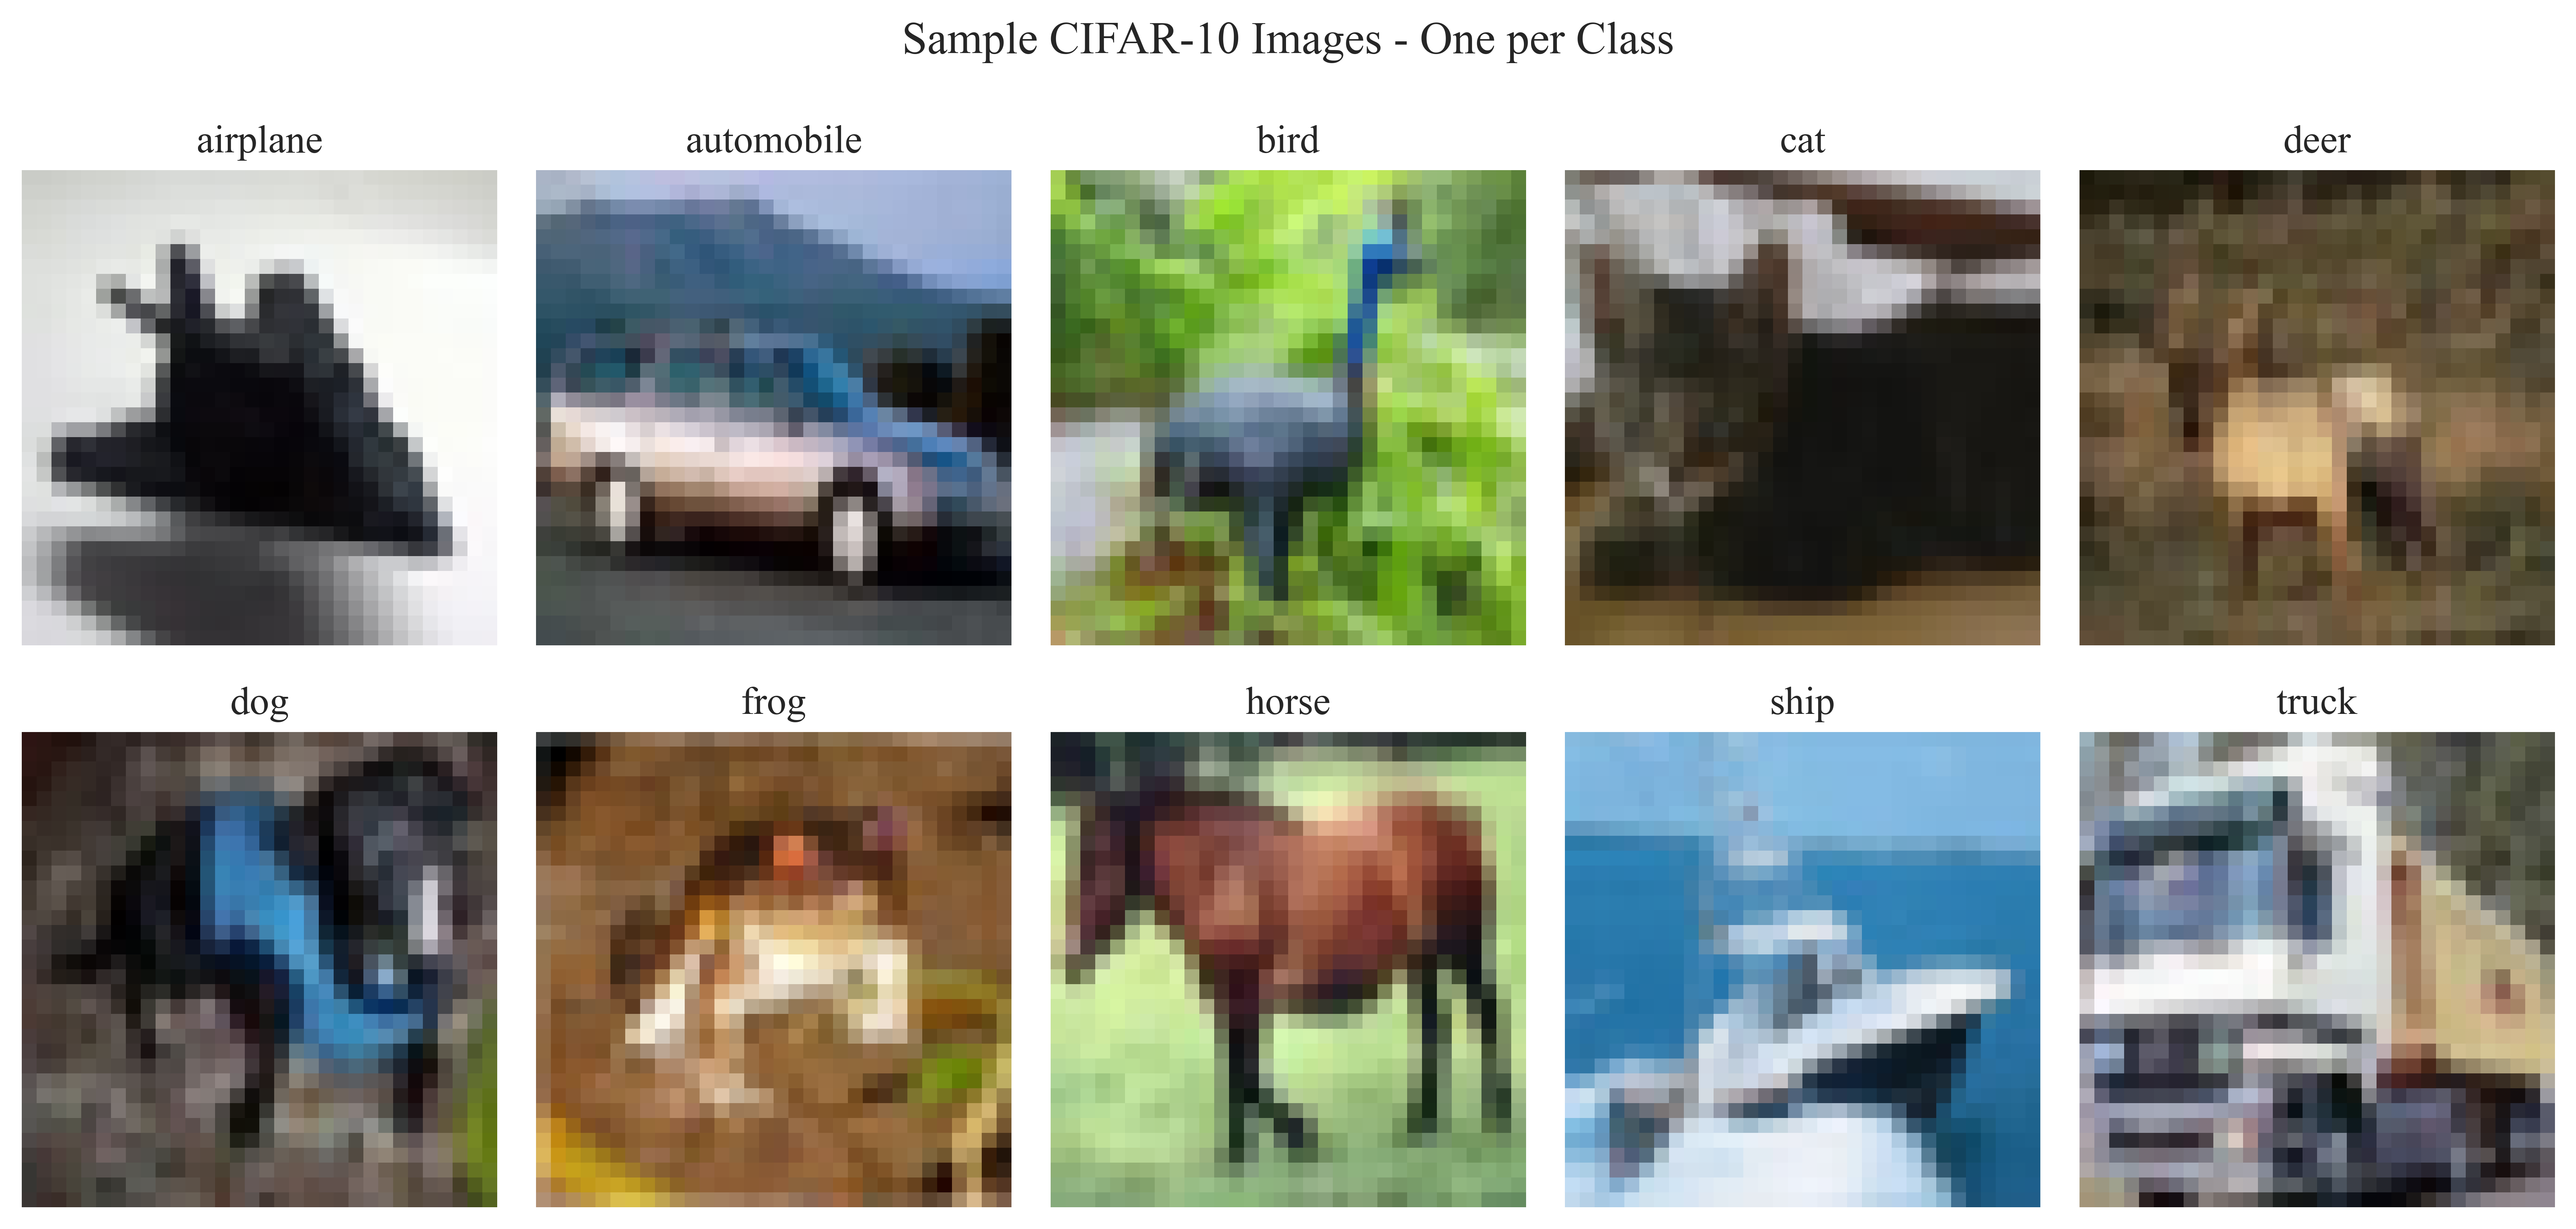

In [14]:
sample_fig, sample_axes = plt.subplots(2, 5, figsize=(12, 6))

for i in range(10):
    idx = np.where(y_train_raw.flatten() == i)[0][0]
    current_axis = sample_axes.flatten()[i]
    current_axis.imshow(x_train_raw[idx])
    current_axis.set_title(class_names[i], fontsize=13, fontweight='bold', fontname='Times New Roman')
    current_axis.axis('off')

sample_fig.suptitle("Sample CIFAR-10 Images - One per Class", fontsize=15, fontweight='bold', fontname='Times New Roman')
plt.tight_layout()

plt.savefig("sample_images.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()


**Inference:** All ten classes are visually distinct at a glance, though some (cat/dog, automobile/truck) share similar colours and silhouettes at this resolution. This is the same raw $32\times32$ data used in the earlier CNN-from-scratch experiment, so any accuracy gains here are attributable to the pretrained ImageNet features rather than a different dataset.

## 8. Preprocessing and Input Pipeline

VGG16 was originally trained on $224\times224$ ImageNet images, but it is a fully convolutional feature extractor (before the classifier head), so it accepts smaller inputs. CIFAR-10's native $32\times32$ resolution is technically the minimum VGG16 supports, but at that size the convolutional base collapses to a $1\times1$ spatial map before Global Average Pooling, leaving very little spatial information for the pretrained filters to work with.

To give the pretrained features a fairer chance to transfer well, every image is resized to $96\times96$ before being passed through the network. Resizing 50,000+ images to $96\times96$ and holding them all in memory as NumPy arrays would need several GB of RAM, so a `tf.data.Dataset` pipeline is used instead — images are resized and preprocessed on the fly, batch by batch, which keeps memory usage low regardless of dataset size.

Pixel values are normalized to the $[0,1]$ range (dividing by 255), as specified in Task 1. *Note: VGG16's own published preprocessing (`keras.applications.vgg16.preprocess_input`) instead does BGR conversion and ImageNet mean-subtraction, which is what it was originally trained with, and typically transfers slightly better than plain $[0,1]$ scaling. Using literal $[0,1]$ normalization here follows the lab manual's instruction exactly; switching to `preprocess_input` is a one-line change in the `preprocess()` function below if a stronger baseline is wanted later.*


In [15]:
IMG_SIZE = 96
BATCH_SIZE = 32
NUM_CLASSES = 10

# Hold out a validation set from the training data
val_size = 5000
x_val_raw, y_val_raw = x_train_raw[:val_size], y_train_raw[:val_size]
x_train_final_raw, y_train_final_raw = x_train_raw[val_size:], y_train_raw[val_size:]

print("Final training set :", x_train_final_raw.shape)
print("Validation set      :", x_val_raw.shape)
print("Test set             :", x_test_raw.shape)

def preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0  # Normalize pixel values to [0, 1], as specified in the lab manual (Task 1, step 2)
    label = tf.one_hot(tf.cast(label, tf.int32), NUM_CLASSES)
    label = tf.squeeze(label)
    return image, label

def make_dataset(images, labels, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((images, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=2000, seed=42)
    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(lambda img, lbl: (tf.image.random_flip_left_right(img), lbl),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(x_train_final_raw, y_train_final_raw, shuffle=True, augment=True)
val_ds   = make_dataset(x_val_raw, y_val_raw, shuffle=False, augment=False)
test_ds  = make_dataset(x_test_raw, y_test_raw, shuffle=False, augment=False)

print("\ntf.data pipelines built. Example batch shapes:")
for imgs, lbls in train_ds.take(1):
    print("Image batch shape:", imgs.shape)
    print("Label batch shape:", lbls.shape)


Final training set : (45000, 32, 32, 3)
Validation set      : (5000, 32, 32, 3)
Test set             : (10000, 32, 32, 3)

tf.data pipelines built. Example batch shapes:
Image batch shape: (32, 96, 96, 3)
Label batch shape: (32, 10)


## 9. Task 2 — Building the Transfer Learning Model (VGG16)

Steps: load VGG16 with ImageNet weights (excluding its original classifier), freeze the convolutional base, and attach a new classifier head suited to 10-class CIFAR-10 classification.


In [16]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze the entire convolutional base initially
base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name='gap')(x)
x = layers.Dense(256, activation='relu', name='dense_head')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='predictions')(x)

model = keras.Model(inputs, outputs, name="VGG16_TransferLearning")
model.summary()

trainable_params = sum(np.prod(v.shape) for v in model.trainable_weights)
non_trainable_params = sum(np.prod(v.shape) for v in model.non_trainable_weights)
print(f"\nTrainable parameters    : {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")
print(f"Total parameters        : {trainable_params + non_trainable_params:,}")


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_head (Dense)              │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)


Trainable parameters    : 133,898
Non-trainable parameters: 14,714,688
Total parameters        : 14,848,586


## 10. Task 3 — Model Training (Frozen Base)

Optimizer: Adam, Learning Rate: 0.001, Batch Size: 32, Loss: Categorical Cross-Entropy, Epochs: 15 (within the 10–20 range specified).


In [17]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_FROZEN = 15

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

start_time = time.time()
history_frozen = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FROZEN,
    callbacks=[early_stop],
    verbose=1
)
frozen_training_time = time.time() - start_time
print(f"\nFrozen-base training time: {frozen_training_time:.1f} seconds")


Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 54ms/step - accuracy: 0.5485 - loss: 1.2959 - val_accuracy: 0.6560 - val_loss: 1.0269
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 72s 51ms/step - accuracy: 0.6341 - loss: 1.0539 - val_accuracy: 0.6710 - val_loss: 0.9439
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 72s 51ms/step - accuracy: 0.6528 - loss: 0.9944 - val_accuracy: 0.6928 - val_loss: 0.9063
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 72s 51ms/step - accuracy: 0.6679 - loss: 0.9567 - val_accuracy: 0.6948 - val_loss: 0.8938
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 72s 51ms/step - accuracy: 0.6763 - loss: 0.9320 - val_accuracy: 0.6926 - val_loss: 0.8815
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 72s 51ms/step - accuracy: 0.6836 - loss: 0.9111 - val_accuracy: 0.7028 - val_loss: 0.8577
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 71s 51ms/step - accuracy: 0.6860 - loss: 0.8957 - val_accuracy: 0.7076 - val_loss: 0.8518
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 72s 51ms/step - accuracy: 0.6919 -

### 10.1 Evaluate the Frozen-Base Model (Baseline, Before Fine-Tuning)

In [18]:
frozen_test_loss, frozen_test_acc = model.evaluate(test_ds, verbose=0)
print(f"Frozen-base Test Loss    : {frozen_test_loss:.4f}")
print(f"Frozen-base Test Accuracy: {frozen_test_acc:.4f}")


Frozen-base Test Loss    : 0.8345
Frozen-base Test Accuracy: 0.7089


### 10.2 Training Accuracy (Mandatory Plot 2)

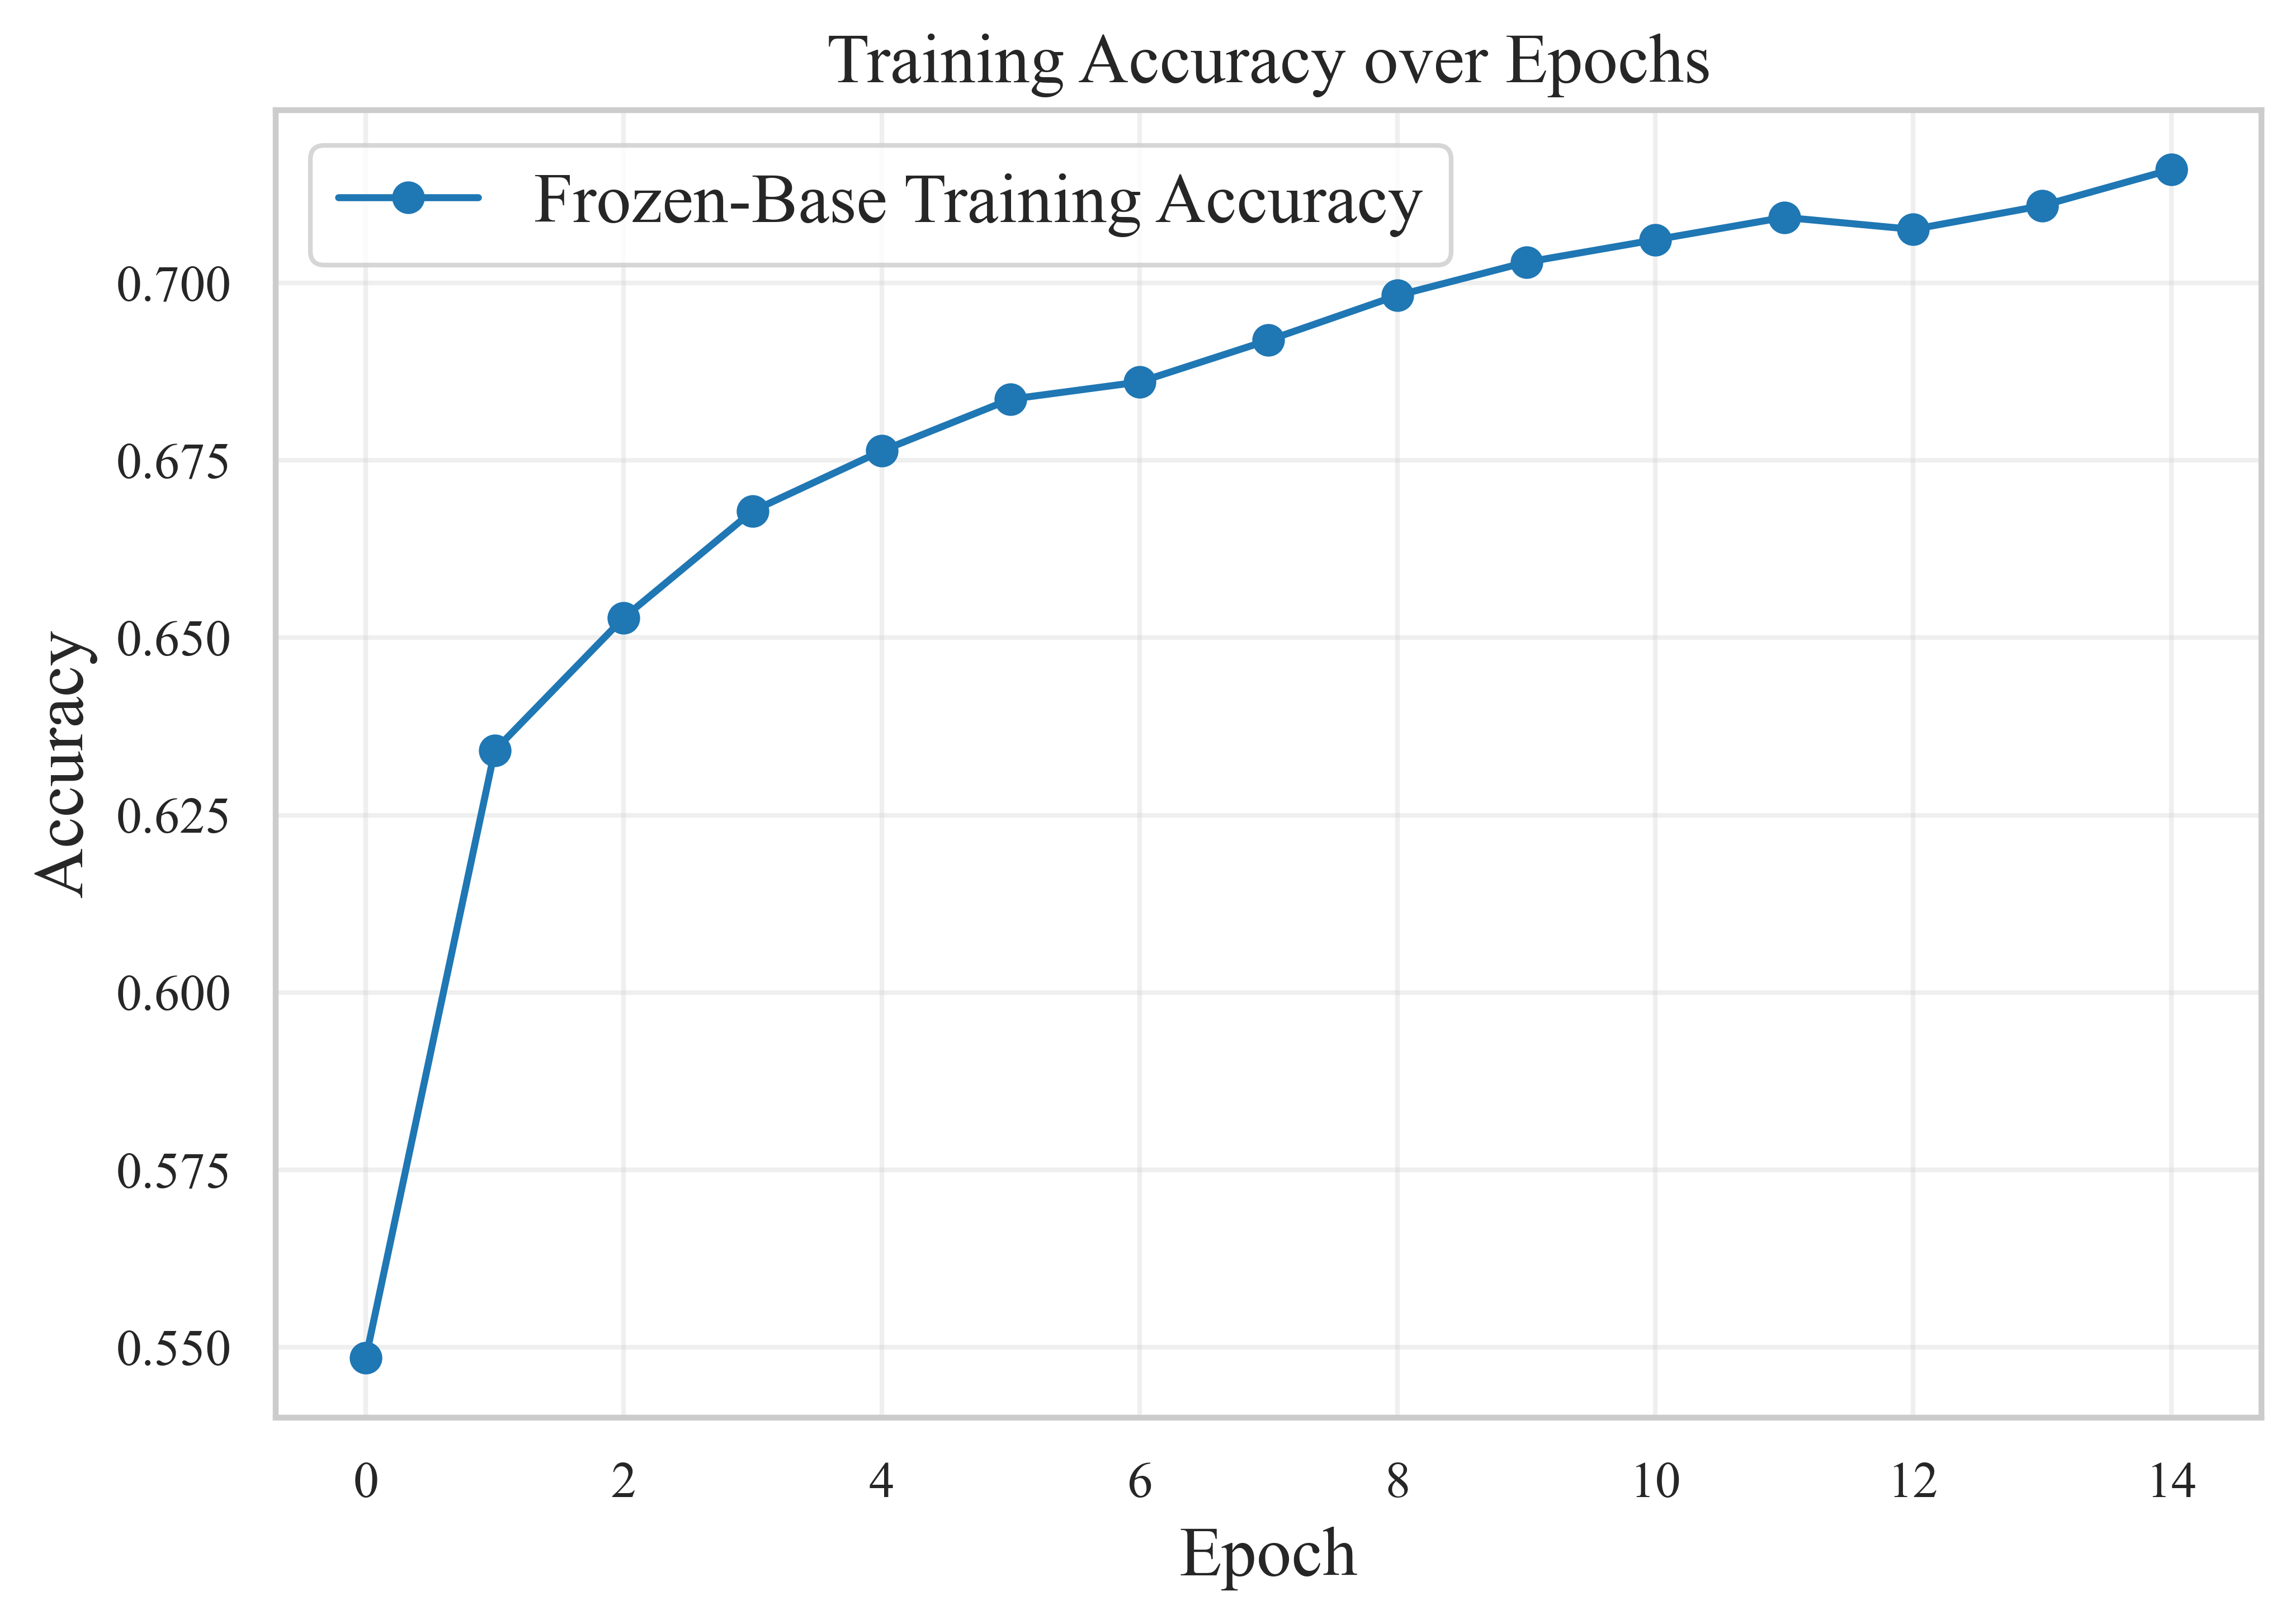

In [19]:
fig_train_acc = plt.figure(figsize=(7, 5))
train_acc_axis = plt.gca()
train_acc_axis.plot(history_frozen.history['accuracy'], marker='o', label='Frozen-Base Training Accuracy')
train_acc_axis.set_title('Training Accuracy over Epochs', **title_style)
train_acc_axis.set_xlabel('Epoch', **label_style)
train_acc_axis.set_ylabel('Accuracy', **label_style)
train_legend = train_acc_axis.legend(prop=legend_style)
format_axis_ticks(train_acc_axis)
format_legend_text(train_legend)
train_acc_axis.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("training_accuracy.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()


**Inference:** Training accuracy rises quickly in the first few epochs since only the small new classifier head is being trained — the pretrained convolutional features are already good, so the model just needs to learn how to combine them for CIFAR-10's 10 classes.

### 10.3 Validation Accuracy (Mandatory Plot 3)

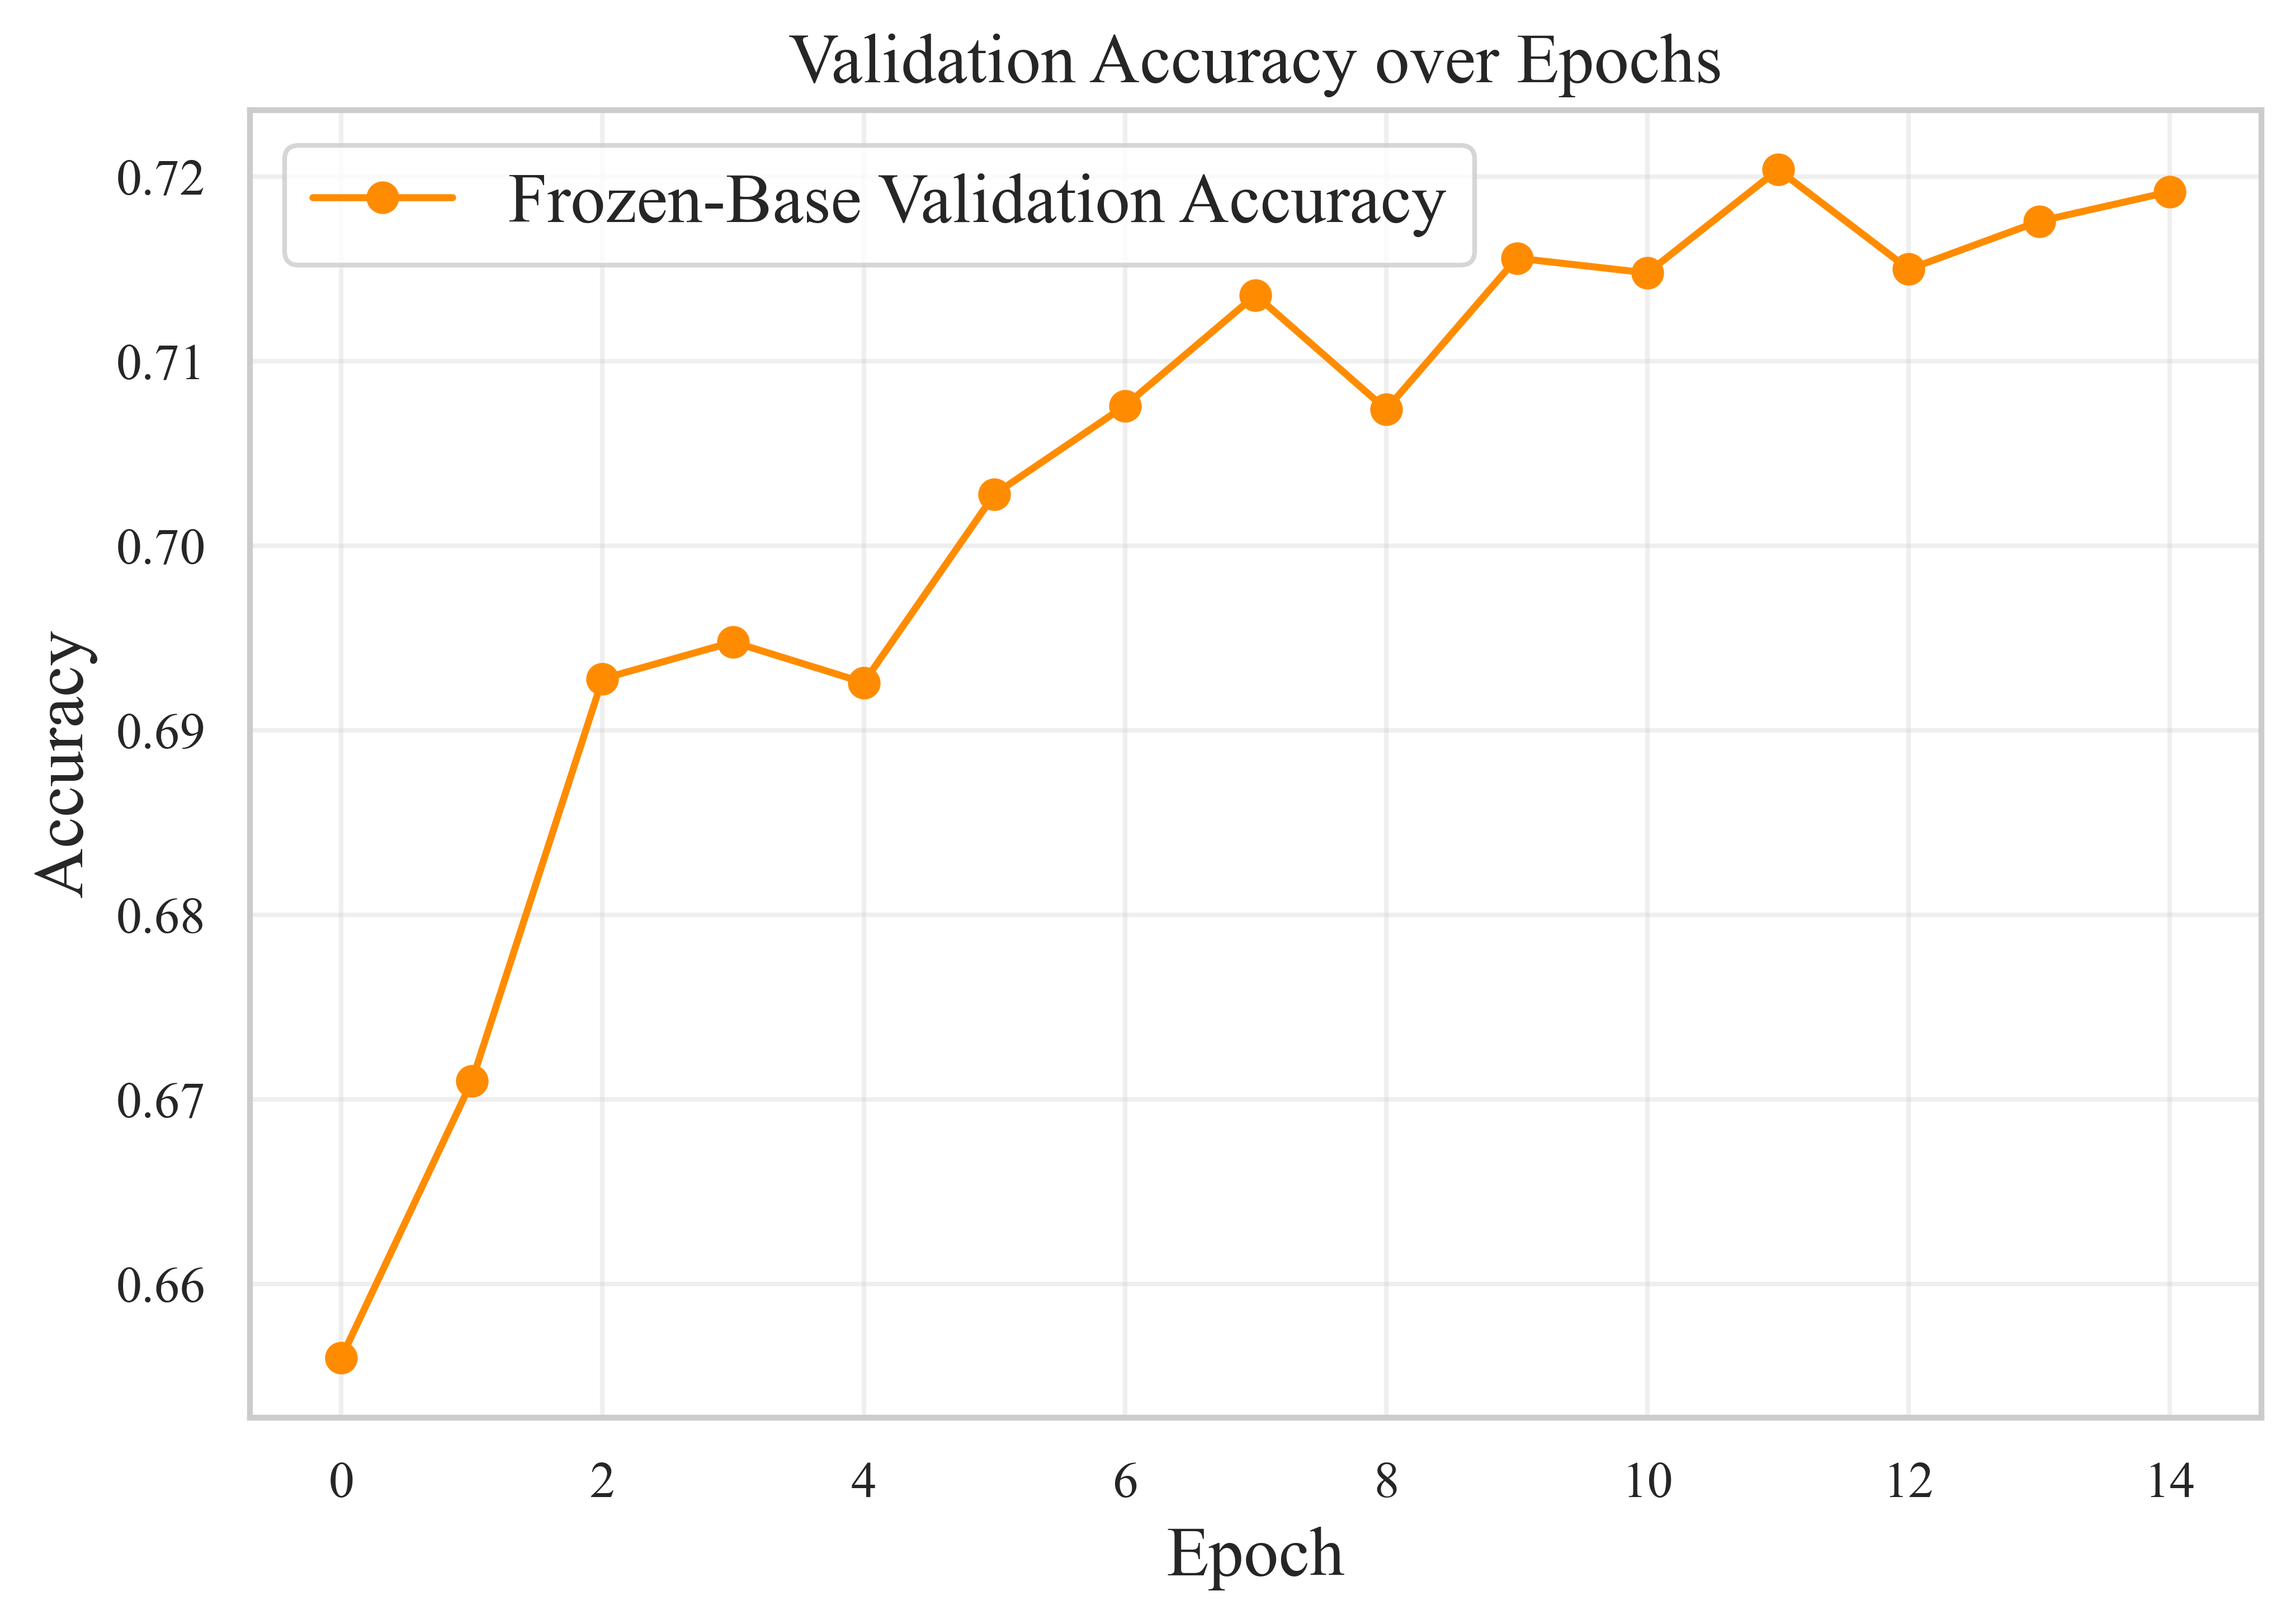

In [20]:
fig_val_acc = plt.figure(figsize=(7, 5))
val_acc_axis = plt.gca()
val_acc_axis.plot(history_frozen.history['val_accuracy'], marker='o', color='darkorange', label='Frozen-Base Validation Accuracy')
val_acc_axis.set_title('Validation Accuracy over Epochs', **title_style)
val_acc_axis.set_xlabel('Epoch', **label_style)
val_acc_axis.set_ylabel('Accuracy', **label_style)
val_legend = val_acc_axis.legend(prop=legend_style)
format_axis_ticks(val_acc_axis)
format_legend_text(val_legend)
val_acc_axis.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("validation_accuracy.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()


**Inference:** Validation accuracy tracks training accuracy closely without a large gap, suggesting the frozen convolutional base is generalizing well and the small dense head isn't overfitting despite CIFAR-10's low native resolution.

### 10.4 Training Loss (Mandatory Plot 4)

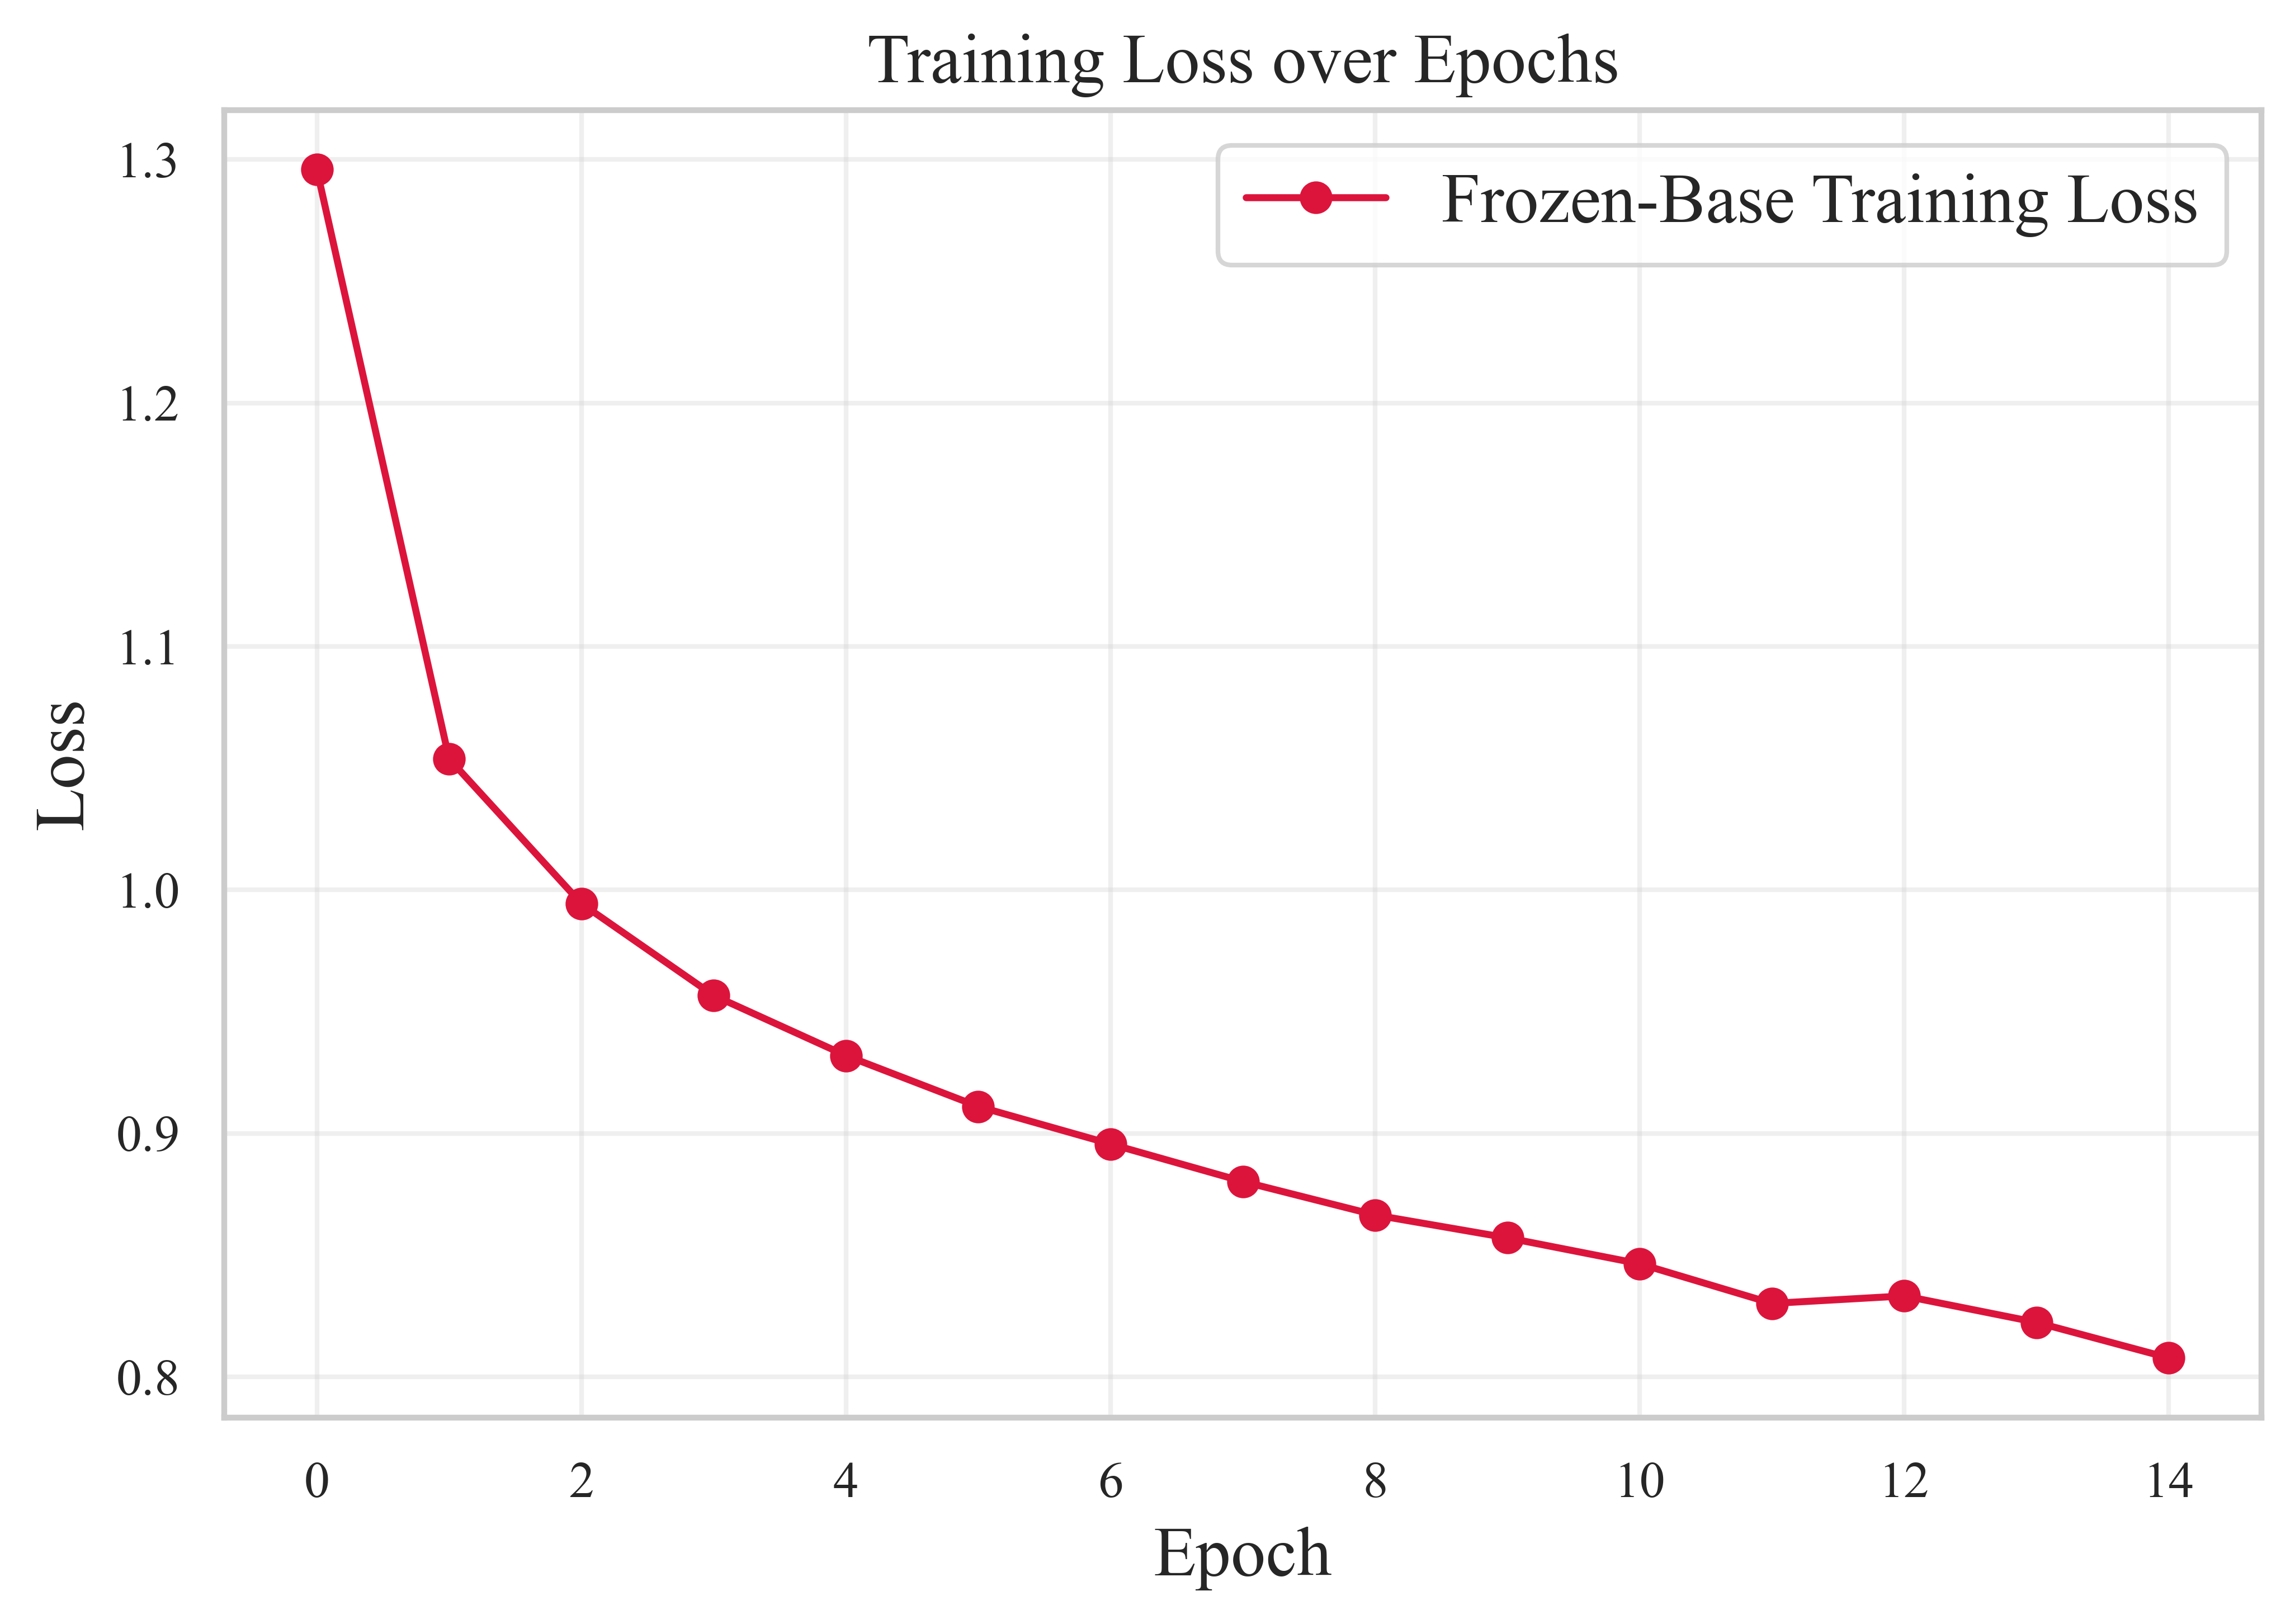

In [21]:
fig_train_loss = plt.figure(figsize=(7, 5))
train_loss_axis = plt.gca()
train_loss_axis.plot(history_frozen.history['loss'], marker='o', color='crimson', label='Frozen-Base Training Loss')
train_loss_axis.set_title('Training Loss over Epochs', **title_style)
train_loss_axis.set_xlabel('Epoch', **label_style)
train_loss_axis.set_ylabel('Loss', **label_style)
train_loss_legend = train_loss_axis.legend(prop=legend_style)
format_axis_ticks(train_loss_axis)
format_legend_text(train_loss_legend)
train_loss_axis.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("training_loss.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()


**Inference:** Training loss decreases steadily and smoothly, which is typical when only a small classifier head is being optimized on top of frozen, already-informative features — there's little for the optimizer to fight against.

### 10.5 Validation Loss (Mandatory Plot 5)

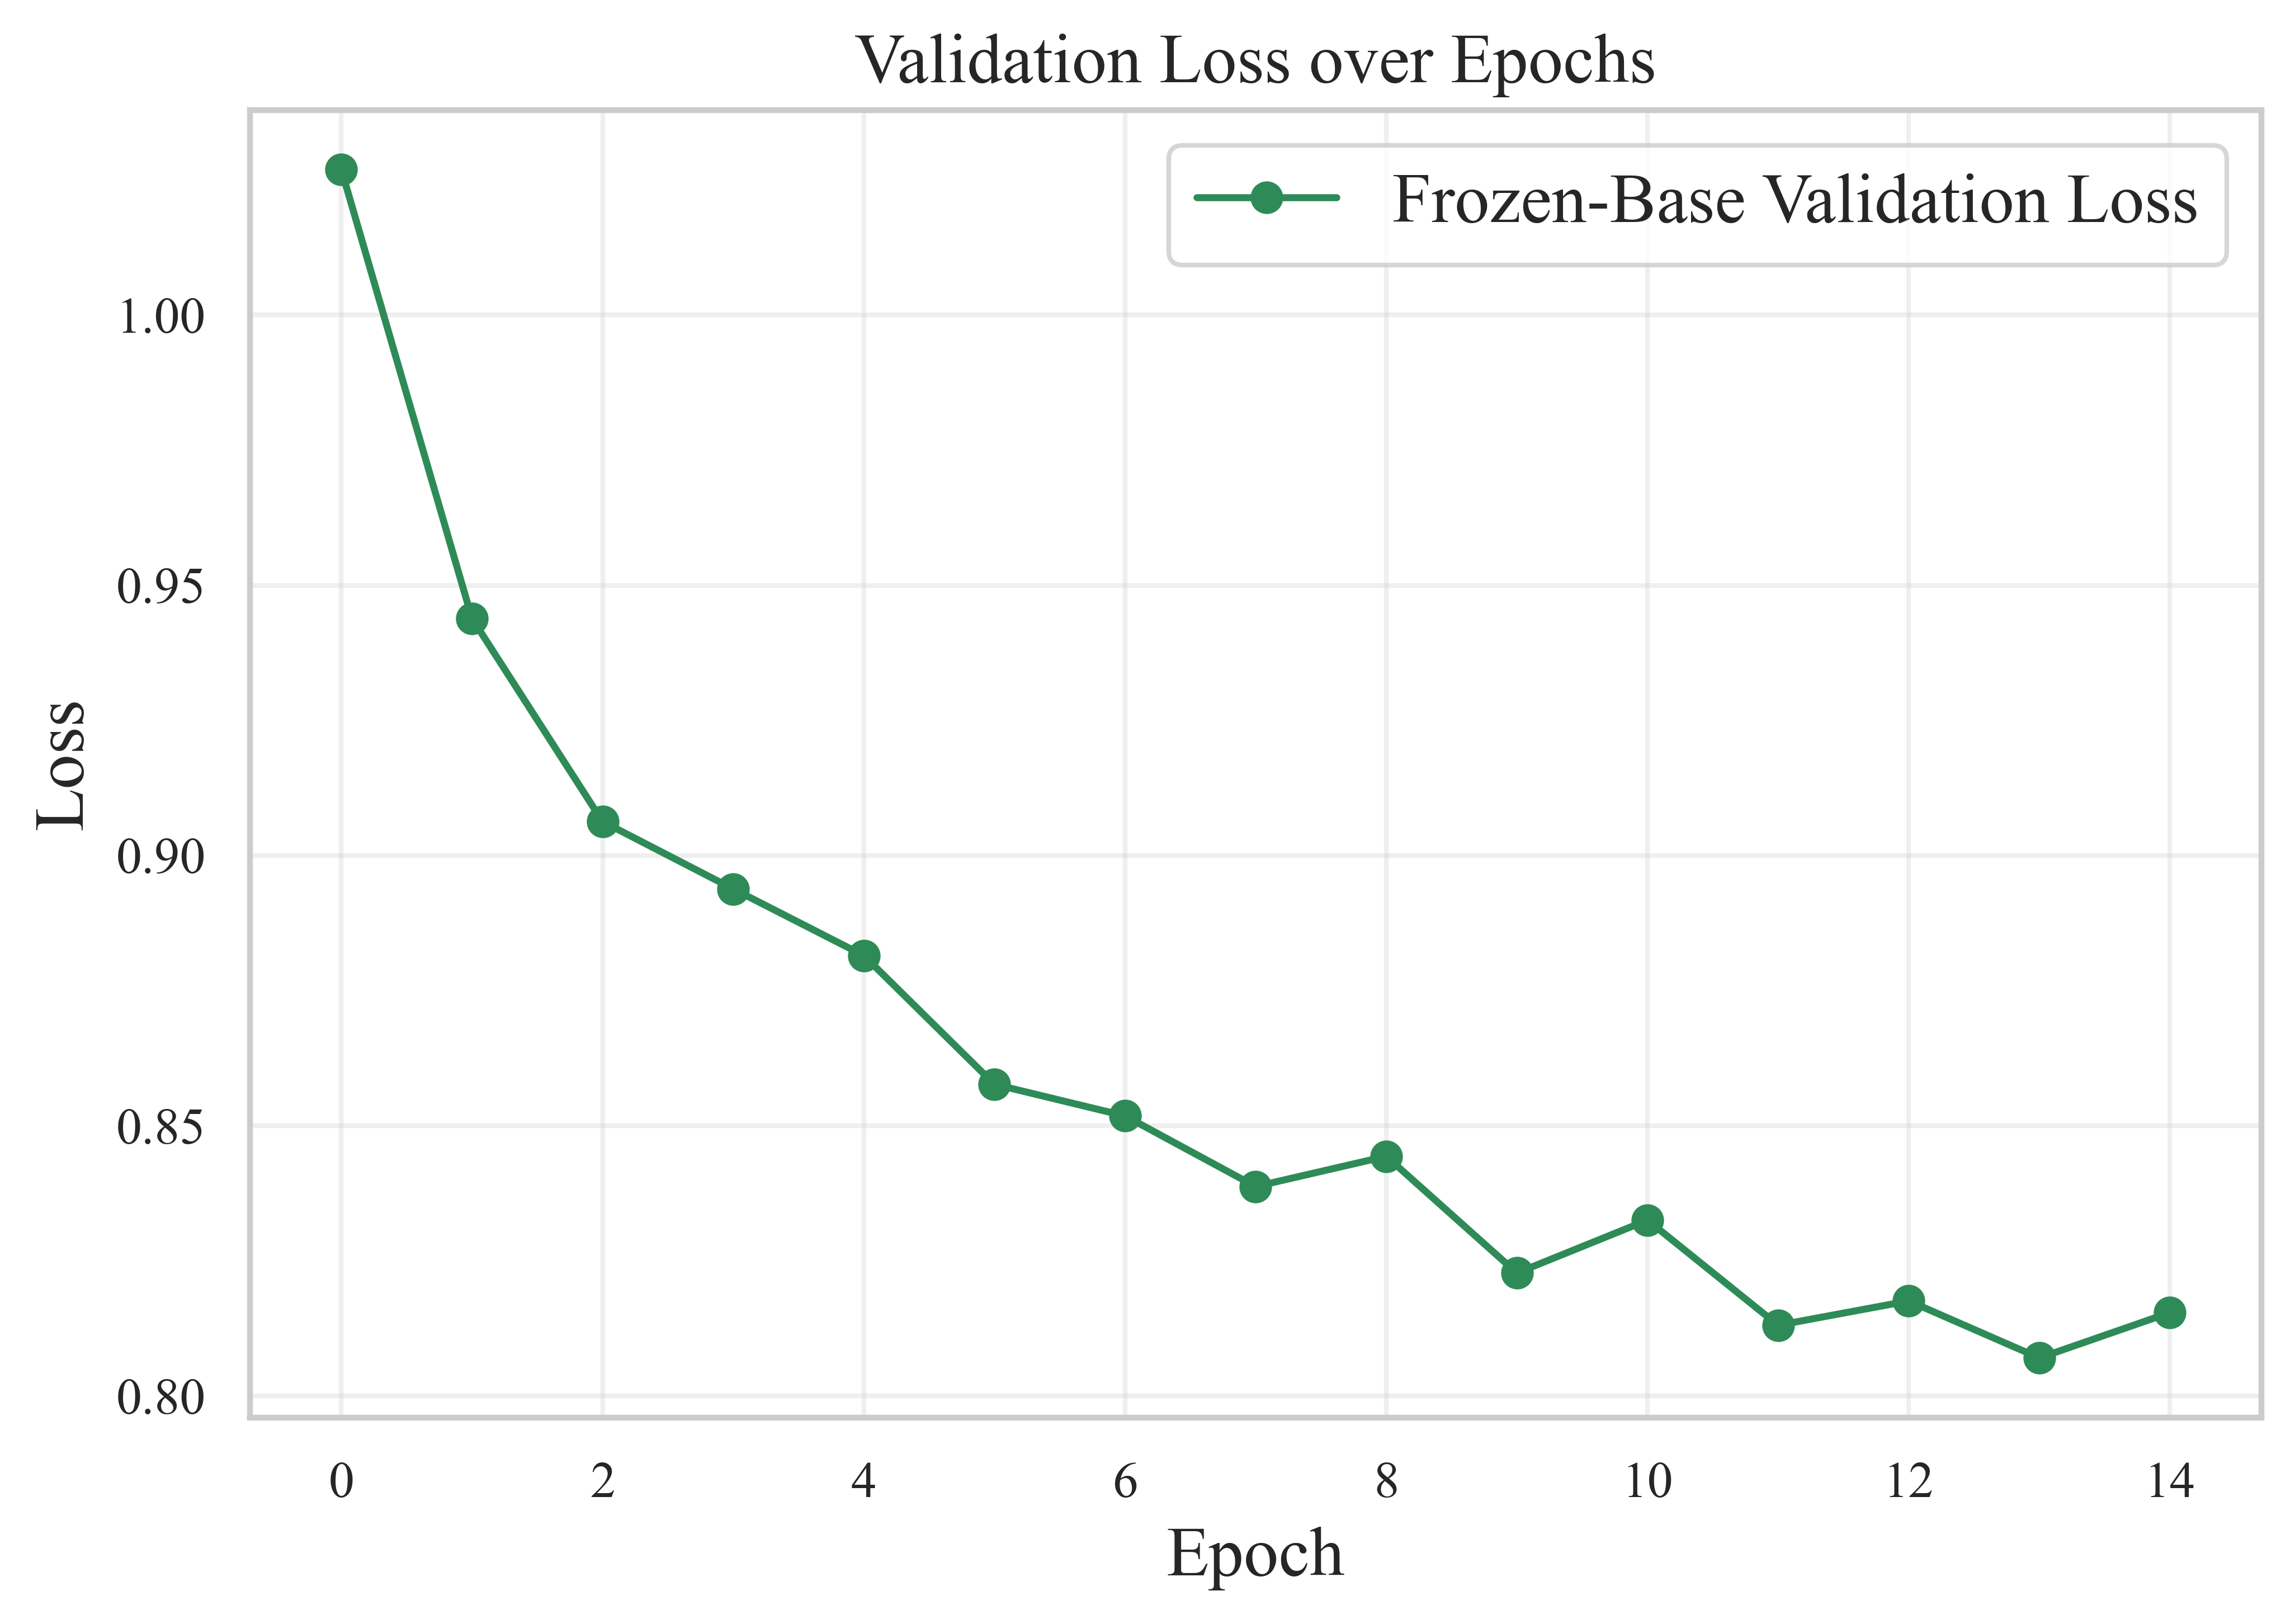

In [22]:
fig_val_loss = plt.figure(figsize=(7, 5))
val_loss_axis = plt.gca()
val_loss_axis.plot(history_frozen.history['val_loss'], marker='o', color='seagreen', label='Frozen-Base Validation Loss')
val_loss_axis.set_title('Validation Loss over Epochs', **title_style)
val_loss_axis.set_xlabel('Epoch', **label_style)
val_loss_axis.set_ylabel('Loss', **label_style)
val_loss_legend = val_loss_axis.legend(prop=legend_style)
format_axis_ticks(val_loss_axis)
format_legend_text(val_loss_legend)
val_loss_axis.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("validation_loss.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()


**Inference:** If validation loss flattens or ticks upward while training loss keeps falling, that's the point the model would start overfitting; `EarlyStopping` is monitoring exactly this so training stops at (or near) that point automatically.

## 11. Task 4 — Fine-Tuning

The last convolutional block of VGG16 (`block5`) is unfrozen and trained at a much lower learning rate than before. A low learning rate is essential here — the pretrained weights are already good, and large updates at this stage would destroy them rather than gently adapt them to CIFAR-10.


In [23]:
base_model.trainable = True

# Freeze everything except the last convolutional block (block5)
fine_tune_at = None
for i, layer in enumerate(base_model.layers):
    if layer.name == 'block5_conv1':
        fine_tune_at = i
        break

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print("Unfrozen (fine-tuned) layers:")
for layer in base_model.layers[fine_tune_at:]:
    print(" -", layer.name)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # much lower LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable_params_ft = sum(np.prod(v.shape) for v in model.trainable_weights)
print(f"\nTrainable parameters after unfreezing block5: {trainable_params_ft:,}")


Unfrozen (fine-tuned) layers:
 - block5_conv1
 - block5_conv2
 - block5_conv3
 - block5_pool

Trainable parameters after unfreezing block5: 7,213,322


In [24]:
EPOCHS_FINE_TUNE = 8

start_time = time.time()
history_fine_tune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE_TUNE,
    callbacks=[early_stop],
    verbose=1
)
fine_tune_training_time = time.time() - start_time
print(f"\nFine-tuning training time: {fine_tune_training_time:.1f} seconds")


Epoch 1/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 103s 70ms/step - accuracy: 0.7582 - loss: 0.6966 - val_accuracy: 0.7892 - val_loss: 0.6161
Epoch 2/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 94s 67ms/step - accuracy: 0.8095 - loss: 0.5428 - val_accuracy: 0.8040 - val_loss: 0.5726
Epoch 3/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 93s 66ms/step - accuracy: 0.8388 - loss: 0.4577 - val_accuracy: 0.8170 - val_loss: 0.5442
Epoch 4/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 93s 66ms/step - accuracy: 0.8622 - loss: 0.3927 - val_accuracy: 0.8266 - val_loss: 0.5239
Epoch 5/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 97s 69ms/step - accuracy: 0.8806 - loss: 0.3352 - val_accuracy: 0.8252 - val_loss: 0.5366
Epoch 6/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 93s 66ms/step - accuracy: 0.8956 - loss: 0.2919 - val_accuracy: 0.8362 - val_loss: 0.5072
Epoch 7/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 93s 66ms/step - accuracy: 0.9112 - loss: 0.2502 - val_accuracy: 0.8406 - val_loss: 0.5094
Epoch 8/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 93s 66ms/step - accuracy: 0.9227 - loss: 

### 11.1 Evaluate the Fine-Tuned Model

In [25]:
fine_tuned_test_loss, fine_tuned_test_acc = model.evaluate(test_ds, verbose=0)
print(f"Fine-tuned Test Loss    : {fine_tuned_test_loss:.4f}")
print(f"Fine-tuned Test Accuracy: {fine_tuned_test_acc:.4f}")

print("\n--- Before vs. After Fine-Tuning ---")
print(f"Frozen-base Test Accuracy : {frozen_test_acc:.4f}")
print(f"Fine-tuned  Test Accuracy : {fine_tuned_test_acc:.4f}")
print(f"Improvement               : {fine_tuned_test_acc - frozen_test_acc:+.4f}")


Fine-tuned Test Loss    : 0.5175
Fine-tuned Test Accuracy: 0.8333

--- Before vs. After Fine-Tuning ---
Frozen-base Test Accuracy : 0.7089
Fine-tuned  Test Accuracy : 0.8333
Improvement               : +0.1244


### 11.2 Combined Training History (Frozen Phase + Fine-Tuning Phase)

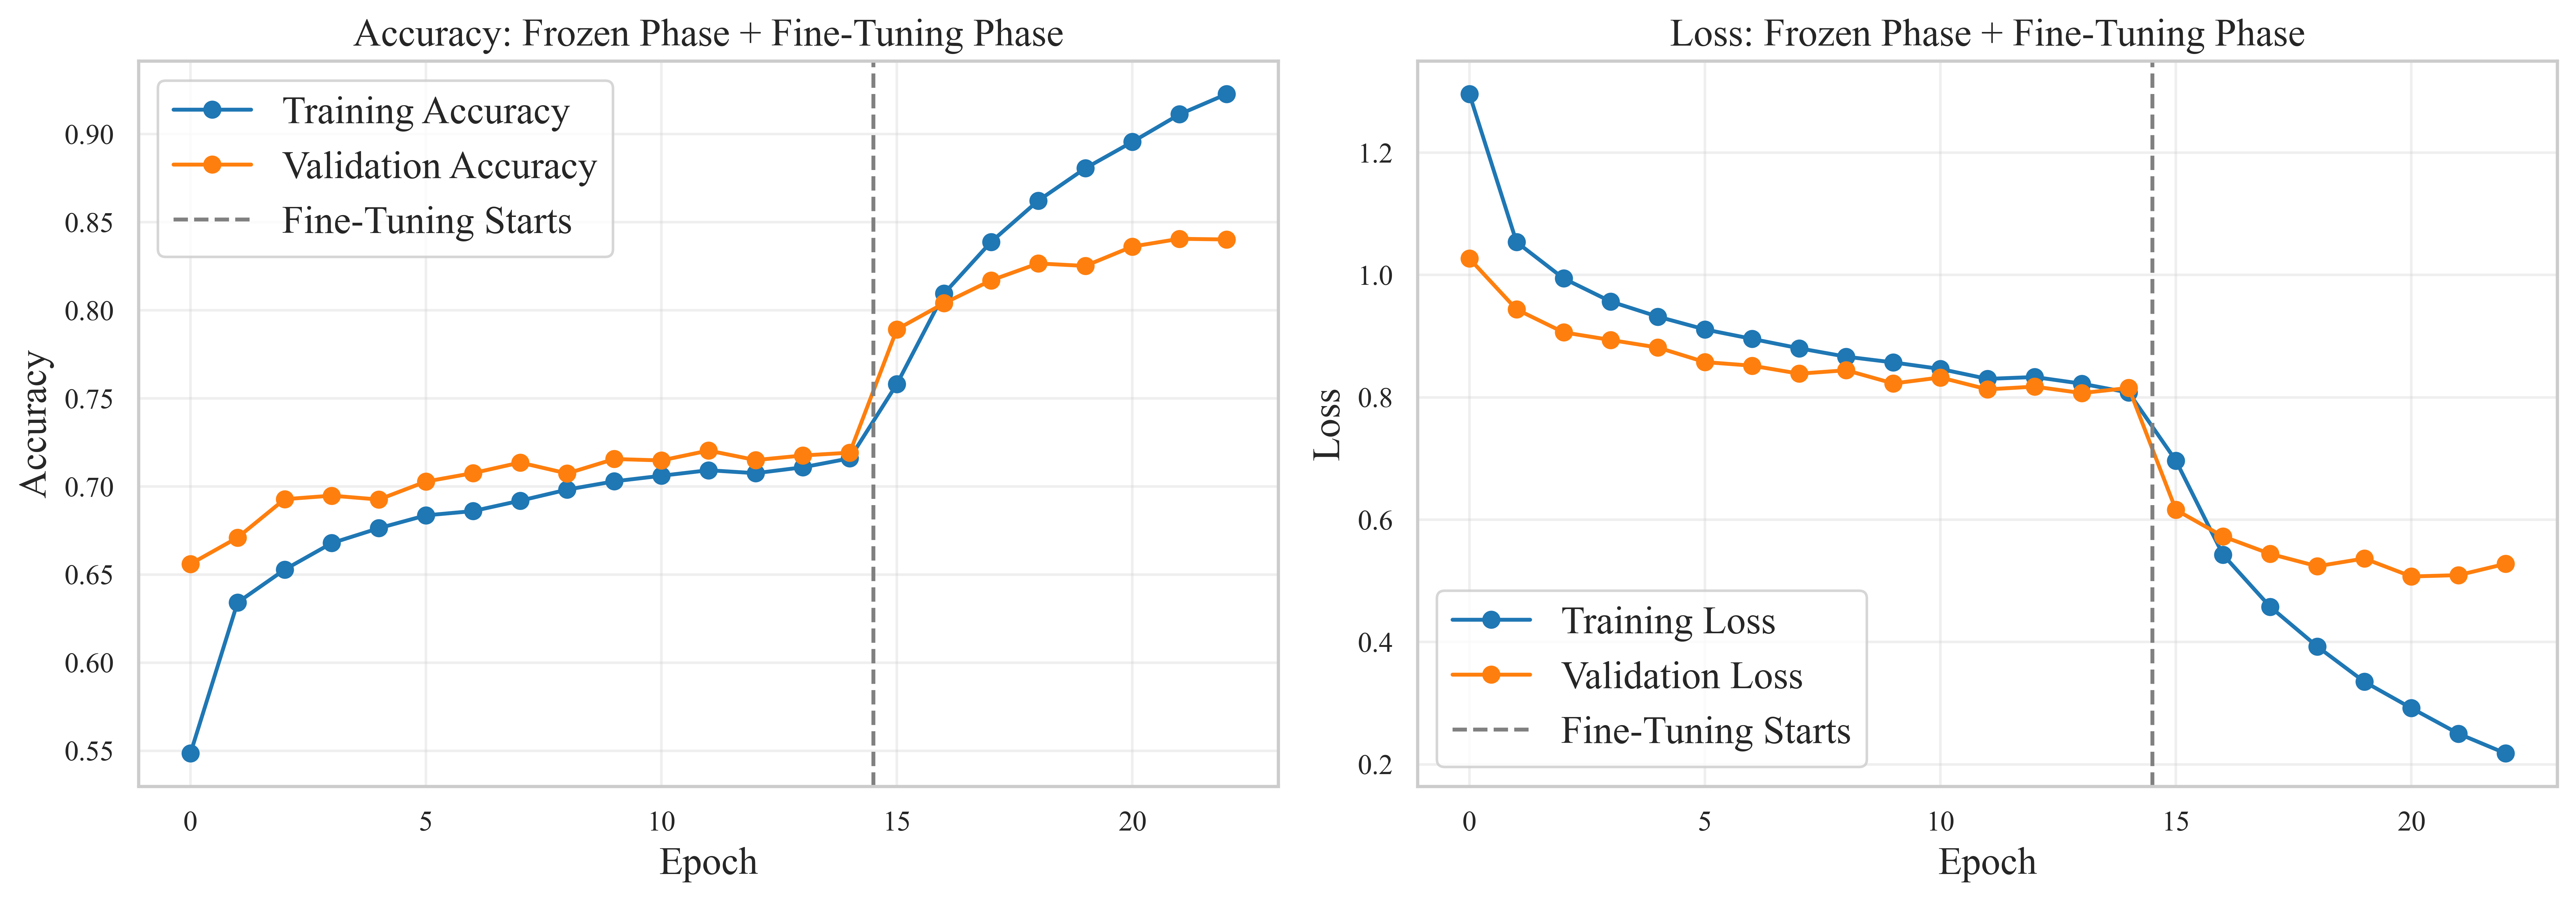

In [26]:
combined_train_acc = history_frozen.history['accuracy'] + history_fine_tune.history['accuracy']
combined_val_acc   = history_frozen.history['val_accuracy'] + history_fine_tune.history['val_accuracy']
combined_train_loss = history_frozen.history['loss'] + history_fine_tune.history['loss']
combined_val_loss   = history_frozen.history['val_loss'] + history_fine_tune.history['val_loss']
fine_tune_start_epoch = len(history_frozen.history['accuracy'])

combined_fig, combined_axes = plt.subplots(1, 2, figsize=(14, 5))

acc_axis = combined_axes[0]
acc_axis.plot(combined_train_acc, label='Training Accuracy', marker='o')
acc_axis.plot(combined_val_acc, label='Validation Accuracy', marker='o')
acc_axis.axvline(x=fine_tune_start_epoch - 0.5, color='gray', linestyle='--', label='Fine-Tuning Starts')
acc_axis.set_title('Accuracy: Frozen Phase + Fine-Tuning Phase', **title_style)
acc_axis.set_xlabel('Epoch', **label_style)
acc_axis.set_ylabel('Accuracy', **label_style)
acc_legend = acc_axis.legend(prop=legend_style)
format_axis_ticks(acc_axis)
format_legend_text(acc_legend)
acc_axis.grid(alpha=0.3)

loss_axis = combined_axes[1]
loss_axis.plot(combined_train_loss, label='Training Loss', marker='o')
loss_axis.plot(combined_val_loss, label='Validation Loss', marker='o')
loss_axis.axvline(x=fine_tune_start_epoch - 0.5, color='gray', linestyle='--', label='Fine-Tuning Starts')
loss_axis.set_title('Loss: Frozen Phase + Fine-Tuning Phase', **title_style)
loss_axis.set_xlabel('Epoch', **label_style)
loss_axis.set_ylabel('Loss', **label_style)
loss_legend = loss_axis.legend(prop=legend_style)
format_axis_ticks(loss_axis)
format_legend_text(loss_legend)
loss_axis.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("finetuning_comparison.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()


**Inference:** The vertical dashed line marks where the frozen-base phase ends and fine-tuning begins. A visible bump in validation accuracy (or drop in validation loss) right after that line indicates fine-tuning genuinely helped; if the curves are flat or worsen slightly, the frozen features were likely already close to their best use for this dataset, and the fine-tuning learning rate may need to be even lower.

## 12. Task 5 — Full Model Evaluation (Fine-Tuned Model, on Test Set)

In [27]:
y_pred_probs = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_raw.flatten()

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")


Accuracy : 0.8333
Precision: 0.8358
Recall   : 0.8333
F1-Score : 0.8337


### 12.1 Classification Report

In [28]:
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))


              precision    recall  f1-score   support

    airplane       0.84      0.92      0.88      1000
  automobile       0.89      0.92      0.90      1000
        bird       0.81      0.79      0.80      1000
         cat       0.66      0.74      0.70      1000
        deer       0.85      0.76      0.80      1000
         dog       0.75      0.72      0.73      1000
        frog       0.87      0.86      0.86      1000
       horse       0.86      0.86      0.86      1000
        ship       0.94      0.88      0.91      1000
       truck       0.89      0.90      0.89      1000

    accuracy                           0.83     10000
   macro avg       0.84      0.83      0.83     10000
weighted avg       0.84      0.83      0.83     10000



### 12.2 Confusion Matrix (Mandatory Plot 6)

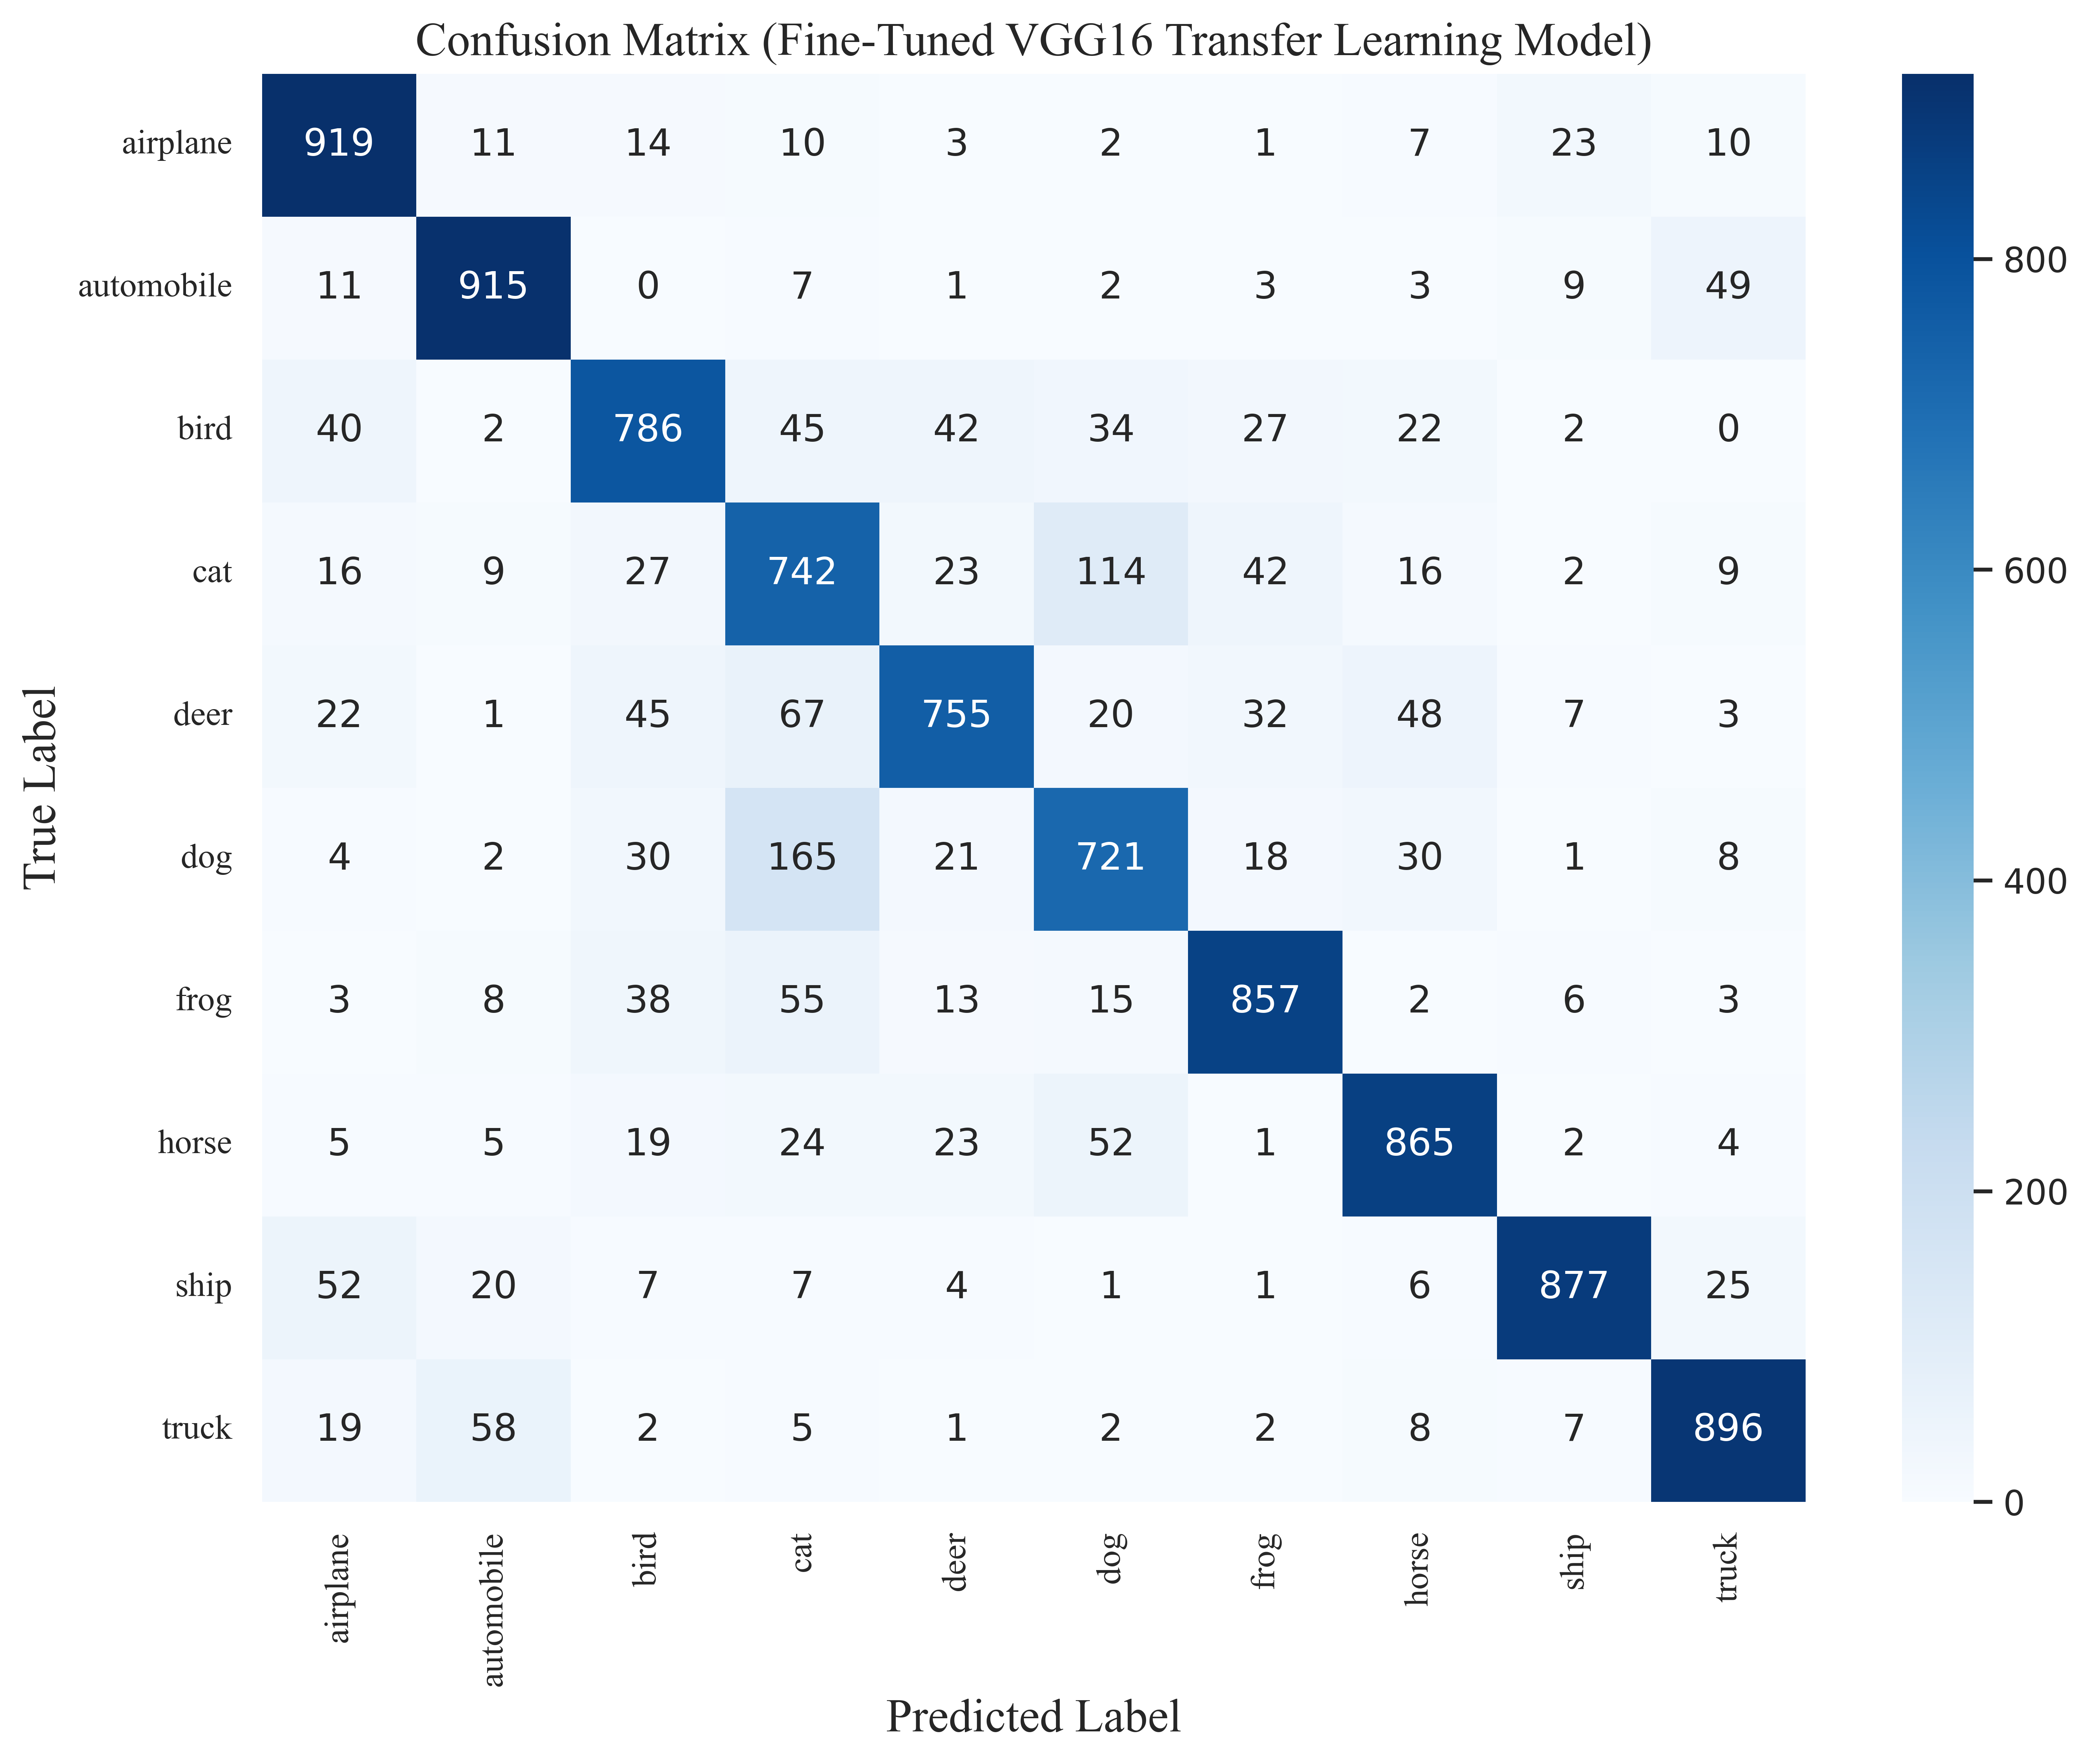

In [29]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
cm_axis = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                       xticklabels=class_names, yticklabels=class_names)
cm_axis.set_title('Confusion Matrix (Fine-Tuned VGG16 Transfer Learning Model)', **title_style)
cm_axis.set_xlabel('Predicted Label', **label_style)
cm_axis.set_ylabel('True Label', **label_style)
format_axis_ticks(cm_axis)
plt.tight_layout()

plt.savefig("confusion_matrix.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()


**Inference:** The diagonal should dominate if transfer learning is working well; any noticeable off-diagonal concentration (commonly among visually similar animal classes on CIFAR-10) highlights exactly which classes the pretrained ImageNet features transfer least cleanly to.

### 12.3 Misclassified Images (Optional Mandatory Plot 7)

Total misclassified test images: 1667 out of 10000


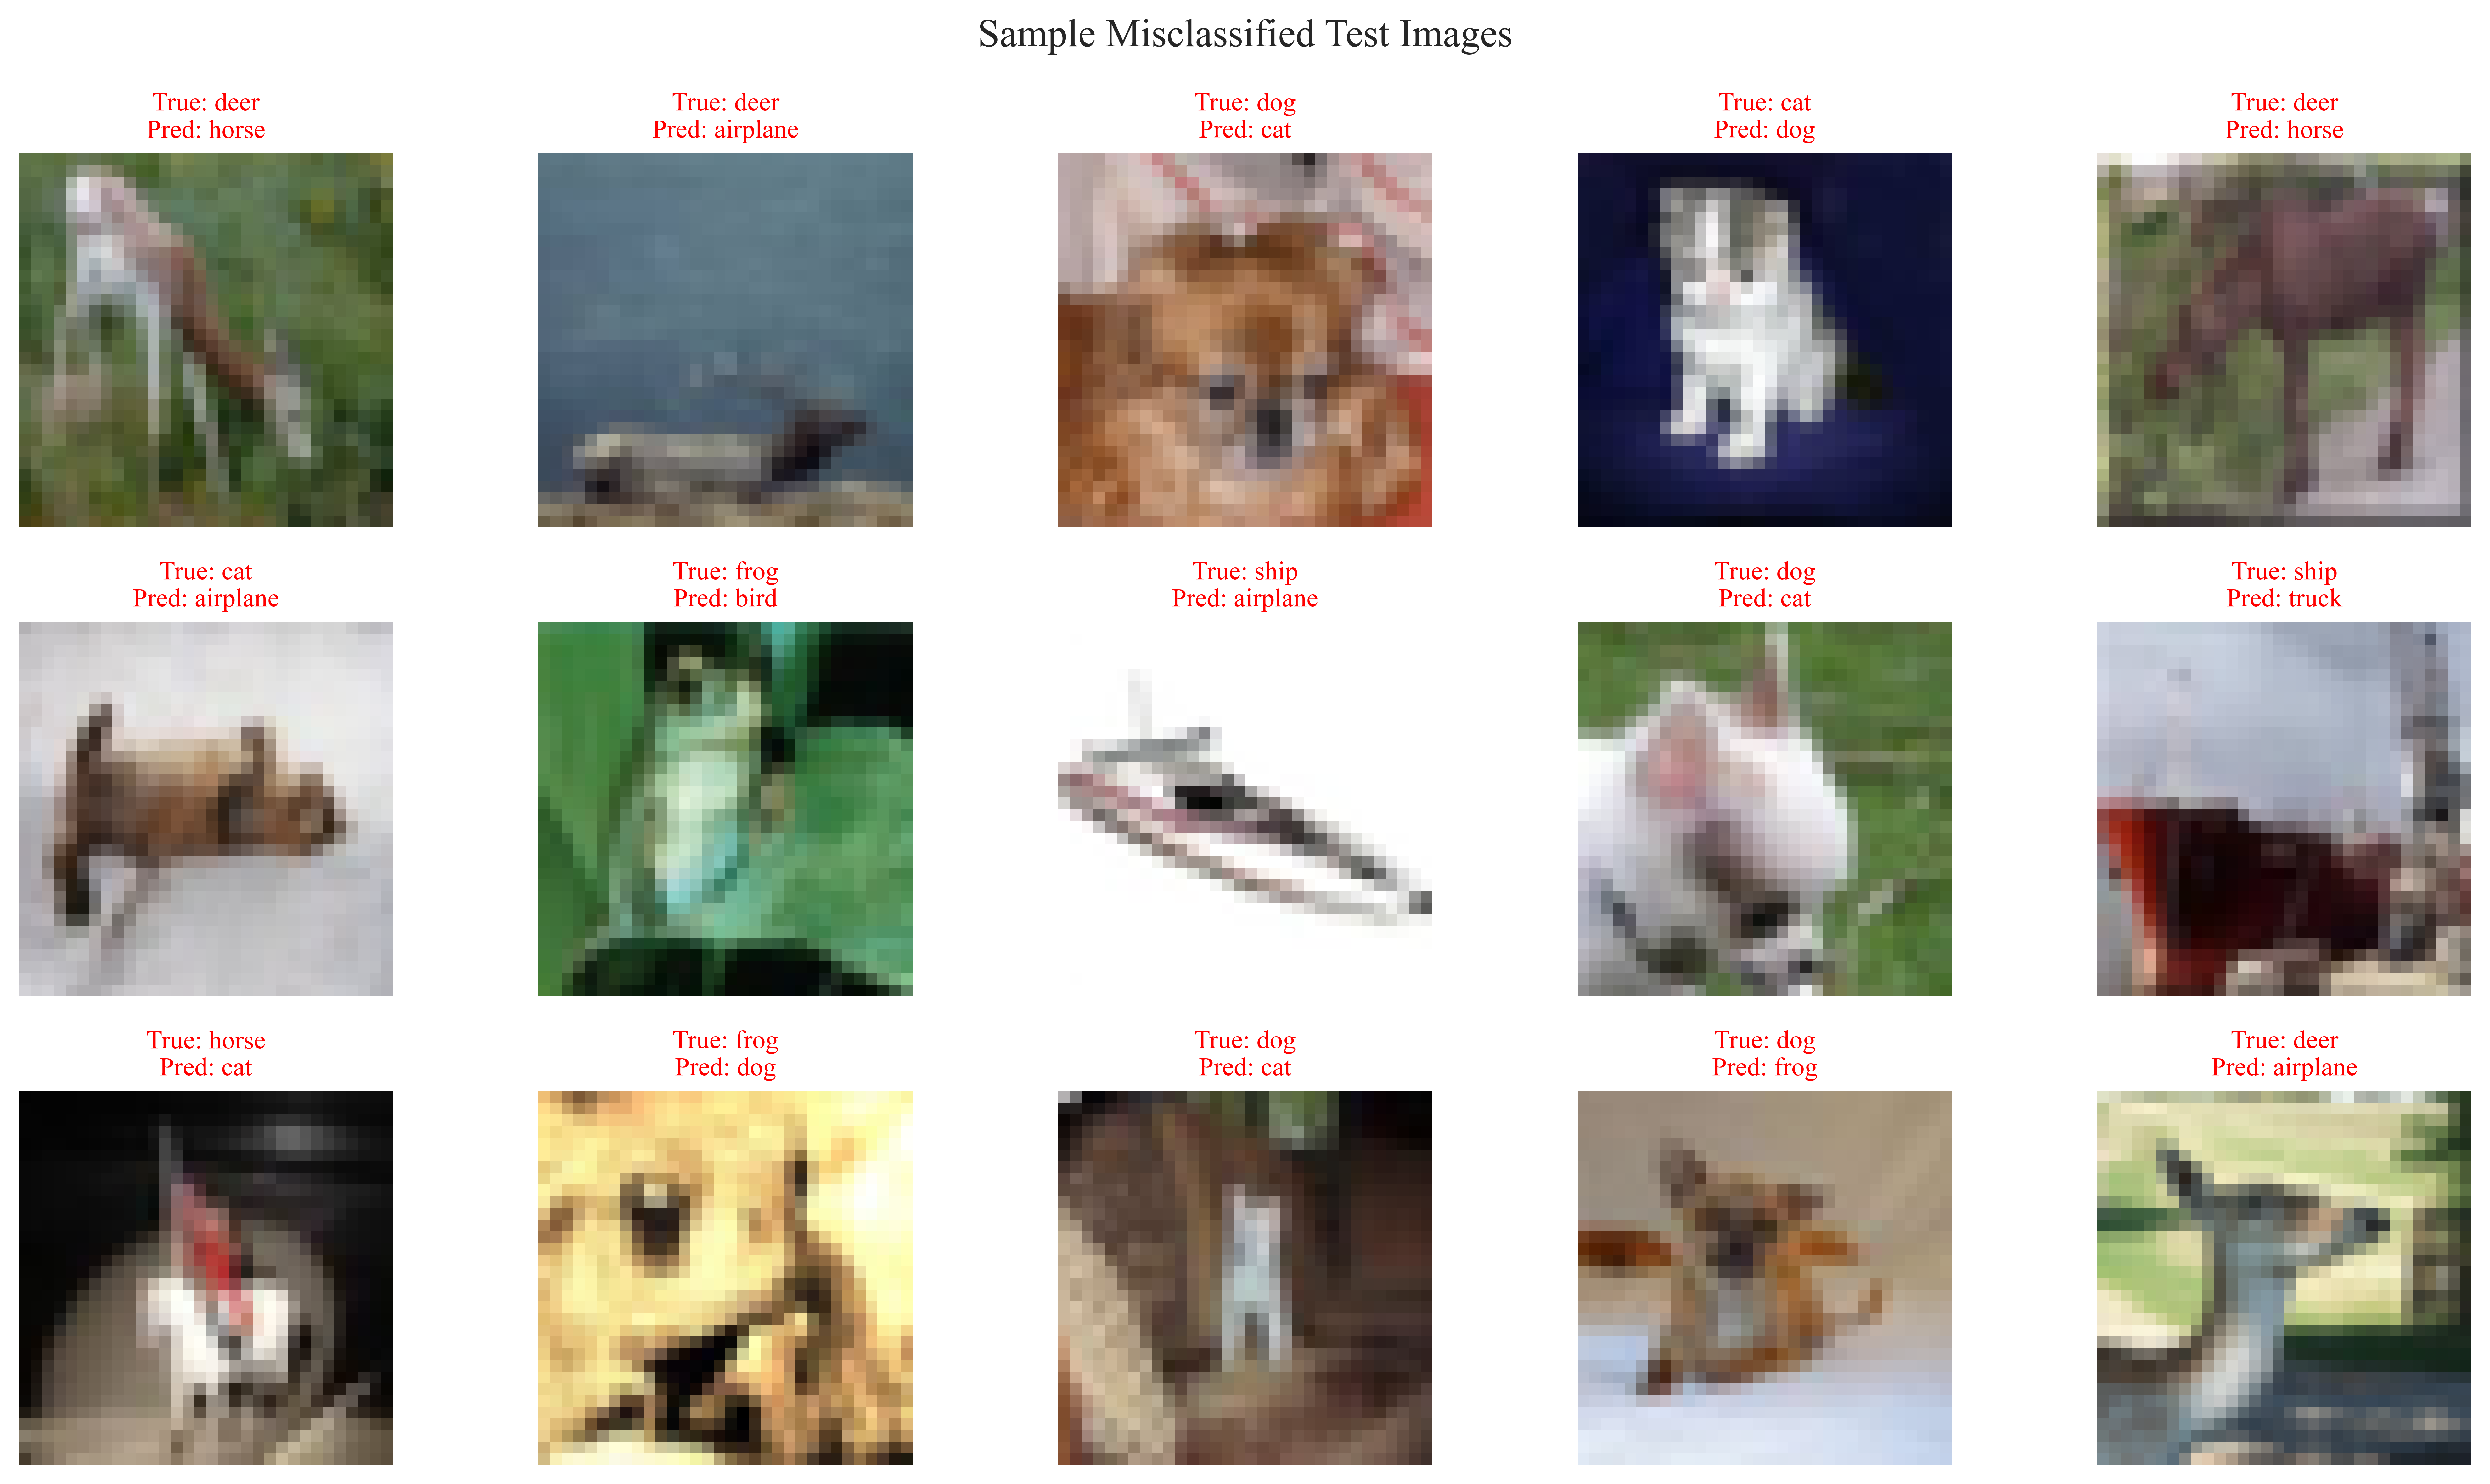

In [30]:
misclassified_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified test images: {len(misclassified_idx)} out of {len(y_true)}")

num_to_show = min(15, len(misclassified_idx))
sample_wrong = np.random.choice(misclassified_idx, num_to_show, replace=False)

wrong_fig, wrong_axes = plt.subplots(3, 5, figsize=(14, 8))
for i, idx in enumerate(sample_wrong):
    current_axis = wrong_axes.flatten()[i]
    current_axis.imshow(x_test_raw[idx])
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]
    current_axis.set_title(f"True: {true_label}\nPred: {pred_label}",
                            color='red', fontsize=10, fontweight='bold', fontname='Times New Roman')
    current_axis.axis('off')

for j in range(num_to_show, 15):
    wrong_axes.flatten()[j].axis('off')

wrong_fig.suptitle("Sample Misclassified Test Images", fontsize=15, fontweight='bold', fontname='Times New Roman')
plt.tight_layout()

plt.savefig("misclassified_images.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()


**Inference:** Most visible mistakes fall between semantically or visually related classes (e.g. cat/dog, automobile/truck) rather than random confusions — a good sanity check that the model's errors are "reasonable" rather than arbitrary noise.

## 13. Hyperparameter Study

The lab manual specifies a fairly large hyperparameter grid (learning rate × batch size × epochs × optimizer × dense units × frozen layers). Running the full combinatorial grid on a VGG16-based model would take far too long for a single lab session, so this section runs targeted, isolated comparisons — changing **one** hyperparameter at a time, on a smaller data subset, purely to observe the *direction* of each effect rather than to chase a fully optimized model.

All six hyperparameters from the manual's table are covered: Learning Rate (13.1), Optimizer (13.2), Dense Units (13.3), Batch Size (13.4), and Epochs (13.5) are each tested in isolated short comparisons below. **Frozen vs. Partial** unfreezing is not repeated as a separate isolated run here, since it is already directly demonstrated at full scale by Sections 10–11 above (frozen-base training vs. fine-tuning on the complete training set, not just a subset).


In [31]:
def build_transfer_model(dense_units=256, frozen=True):
    base = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = not frozen
    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    h = base(inp, training=False)
    h = layers.GlobalAveragePooling2D()(h)
    h = layers.Dense(dense_units, activation='relu')(h)
    h = layers.Dropout(0.4)(h)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(h)
    return keras.Model(inp, out)

# Use a smaller subset for these quick, isolated comparisons
subset_size = 5000
x_subset_raw, y_subset_raw = x_train_final_raw[:subset_size], y_train_final_raw[:subset_size]
train_ds_subset = make_dataset(x_subset_raw, y_subset_raw, shuffle=True, augment=False)
QUICK_EPOCHS = 5

def make_dataset_custom_batch(images, labels, batch_size, shuffle=False):
    # Same as make_dataset(), but with an explicit batch size, used for the batch-size comparison below.
    ds = tf.data.Dataset.from_tensor_slices((images, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=2000, seed=42)
    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


### 13.1 Effect of Learning Rate (0.001 vs. 0.0001)

In [32]:
lr_results = {}

for lr in [0.001, 0.0001]:
    print(f"\n--- Training with learning_rate={lr} ---")
    m = build_transfer_model(dense_units=256, frozen=True)
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
              loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(train_ds_subset, validation_data=val_ds, epochs=QUICK_EPOCHS, verbose=0)
    test_loss, test_acc = m.evaluate(test_ds, verbose=0)
    lr_results[lr] = {'history': h, 'test_acc': test_acc}
    print(f"Learning rate {lr} -> Test Accuracy: {test_acc:.4f}")



--- Training with learning_rate=0.001 ---
Learning rate 0.001 -> Test Accuracy: 0.6011

--- Training with learning_rate=0.0001 ---
Learning rate 0.0001 -> Test Accuracy: 0.4994


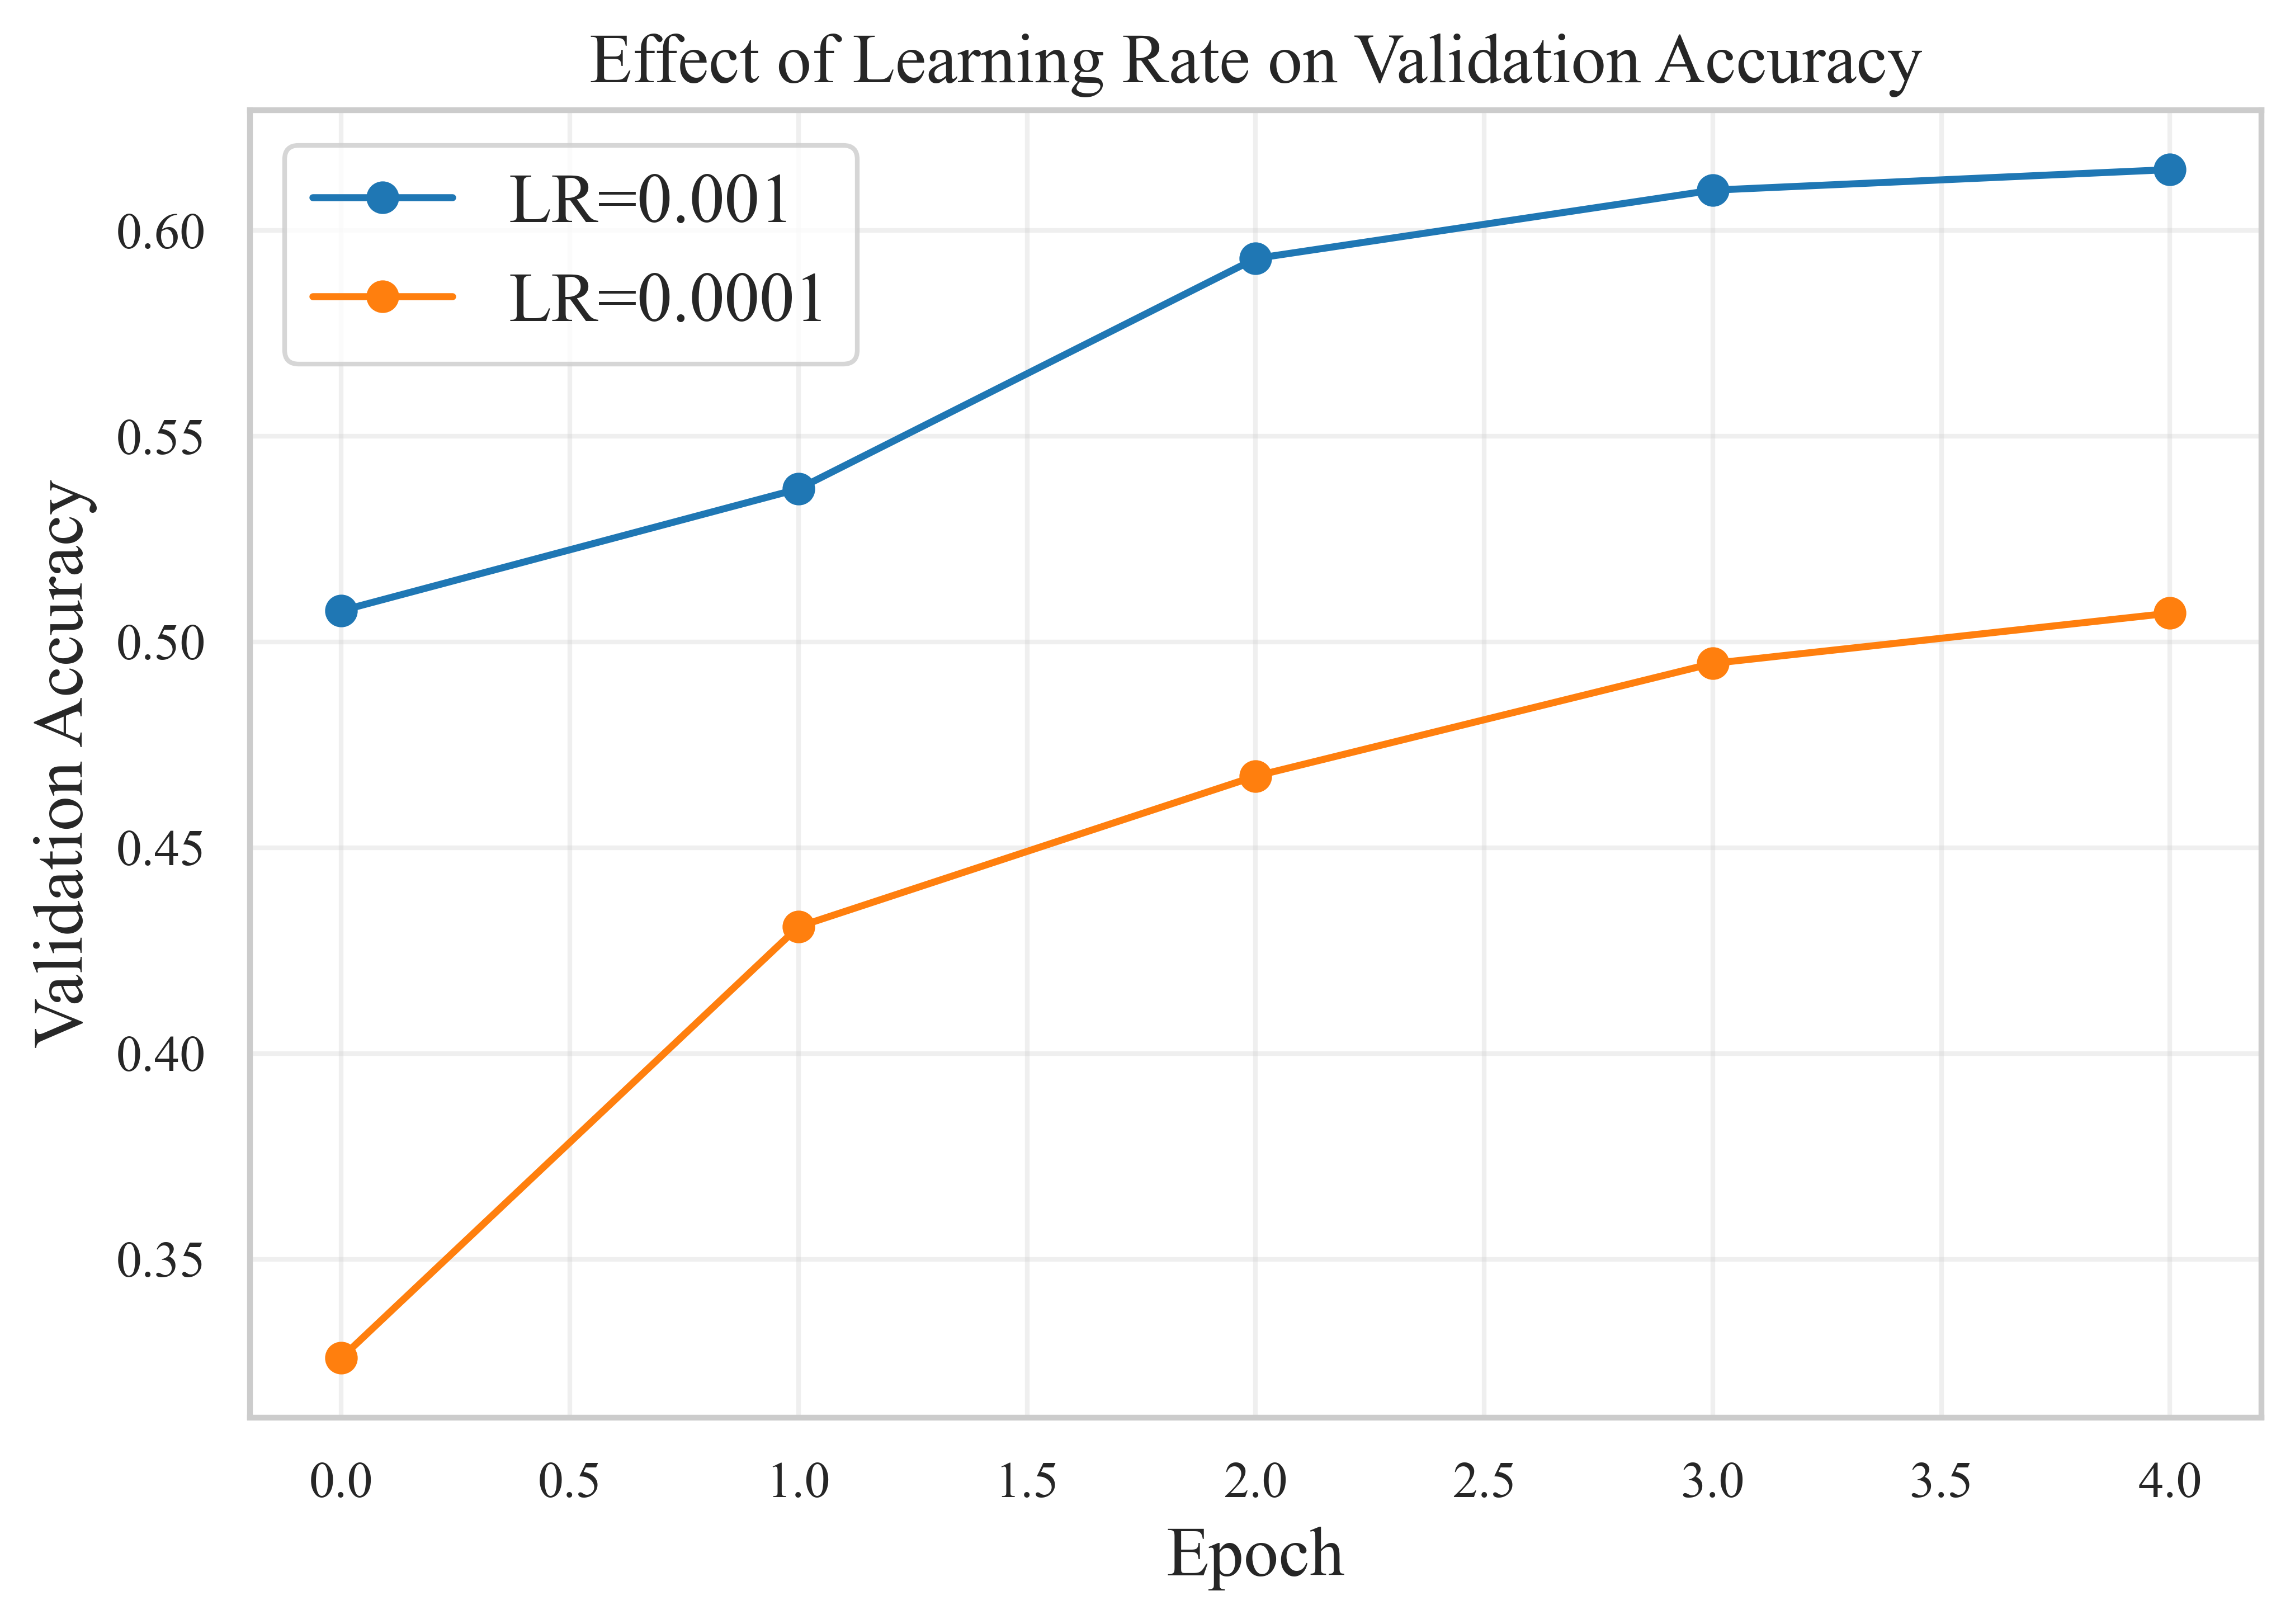


Summary:
LR=0.001 -> Test Accuracy: 0.6011
LR=0.0001 -> Test Accuracy: 0.4994


In [33]:
lr_fig = plt.figure(figsize=(7, 5))
lr_axis = plt.gca()
for lr in lr_results:
    lr_axis.plot(lr_results[lr]['history'].history['val_accuracy'],
                 label=f'LR={lr}', marker='o')
lr_axis.set_title('Effect of Learning Rate on Validation Accuracy', **title_style)
lr_axis.set_xlabel('Epoch', **label_style)
lr_axis.set_ylabel('Validation Accuracy', **label_style)
lr_legend = lr_axis.legend(prop=legend_style)
format_axis_ticks(lr_axis)
format_legend_text(lr_legend)
lr_axis.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("learning_rate_comparison.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()

print("\nSummary:")
for lr in lr_results:
    print(f"LR={lr} -> Test Accuracy: {lr_results[lr]['test_acc']:.4f}")


**Inference:** A learning rate that's too high can overshoot the good regions of frozen-feature space the dense head needs to settle into, while one that's too low may simply need more epochs to reach the same point — whichever curve climbs faster and higher within this short run is the more efficient choice for this stage of training.

### 13.2 Effect of Optimizer (Adam vs. SGD)

In [34]:
optimizer_results = {}

optimizers_to_test = {
    'Adam': keras.optimizers.Adam(learning_rate=0.001),
    'SGD': keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)
}

for opt_name, opt in optimizers_to_test.items():
    print(f"\n--- Training with optimizer={opt_name} ---")
    m = build_transfer_model(dense_units=256, frozen=True)
    m.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(train_ds_subset, validation_data=val_ds, epochs=QUICK_EPOCHS, verbose=0)
    test_loss, test_acc = m.evaluate(test_ds, verbose=0)
    optimizer_results[opt_name] = {'history': h, 'test_acc': test_acc}
    print(f"{opt_name} -> Test Accuracy: {test_acc:.4f}")



--- Training with optimizer=Adam ---
Adam -> Test Accuracy: 0.6069

--- Training with optimizer=SGD ---
SGD -> Test Accuracy: 0.4216


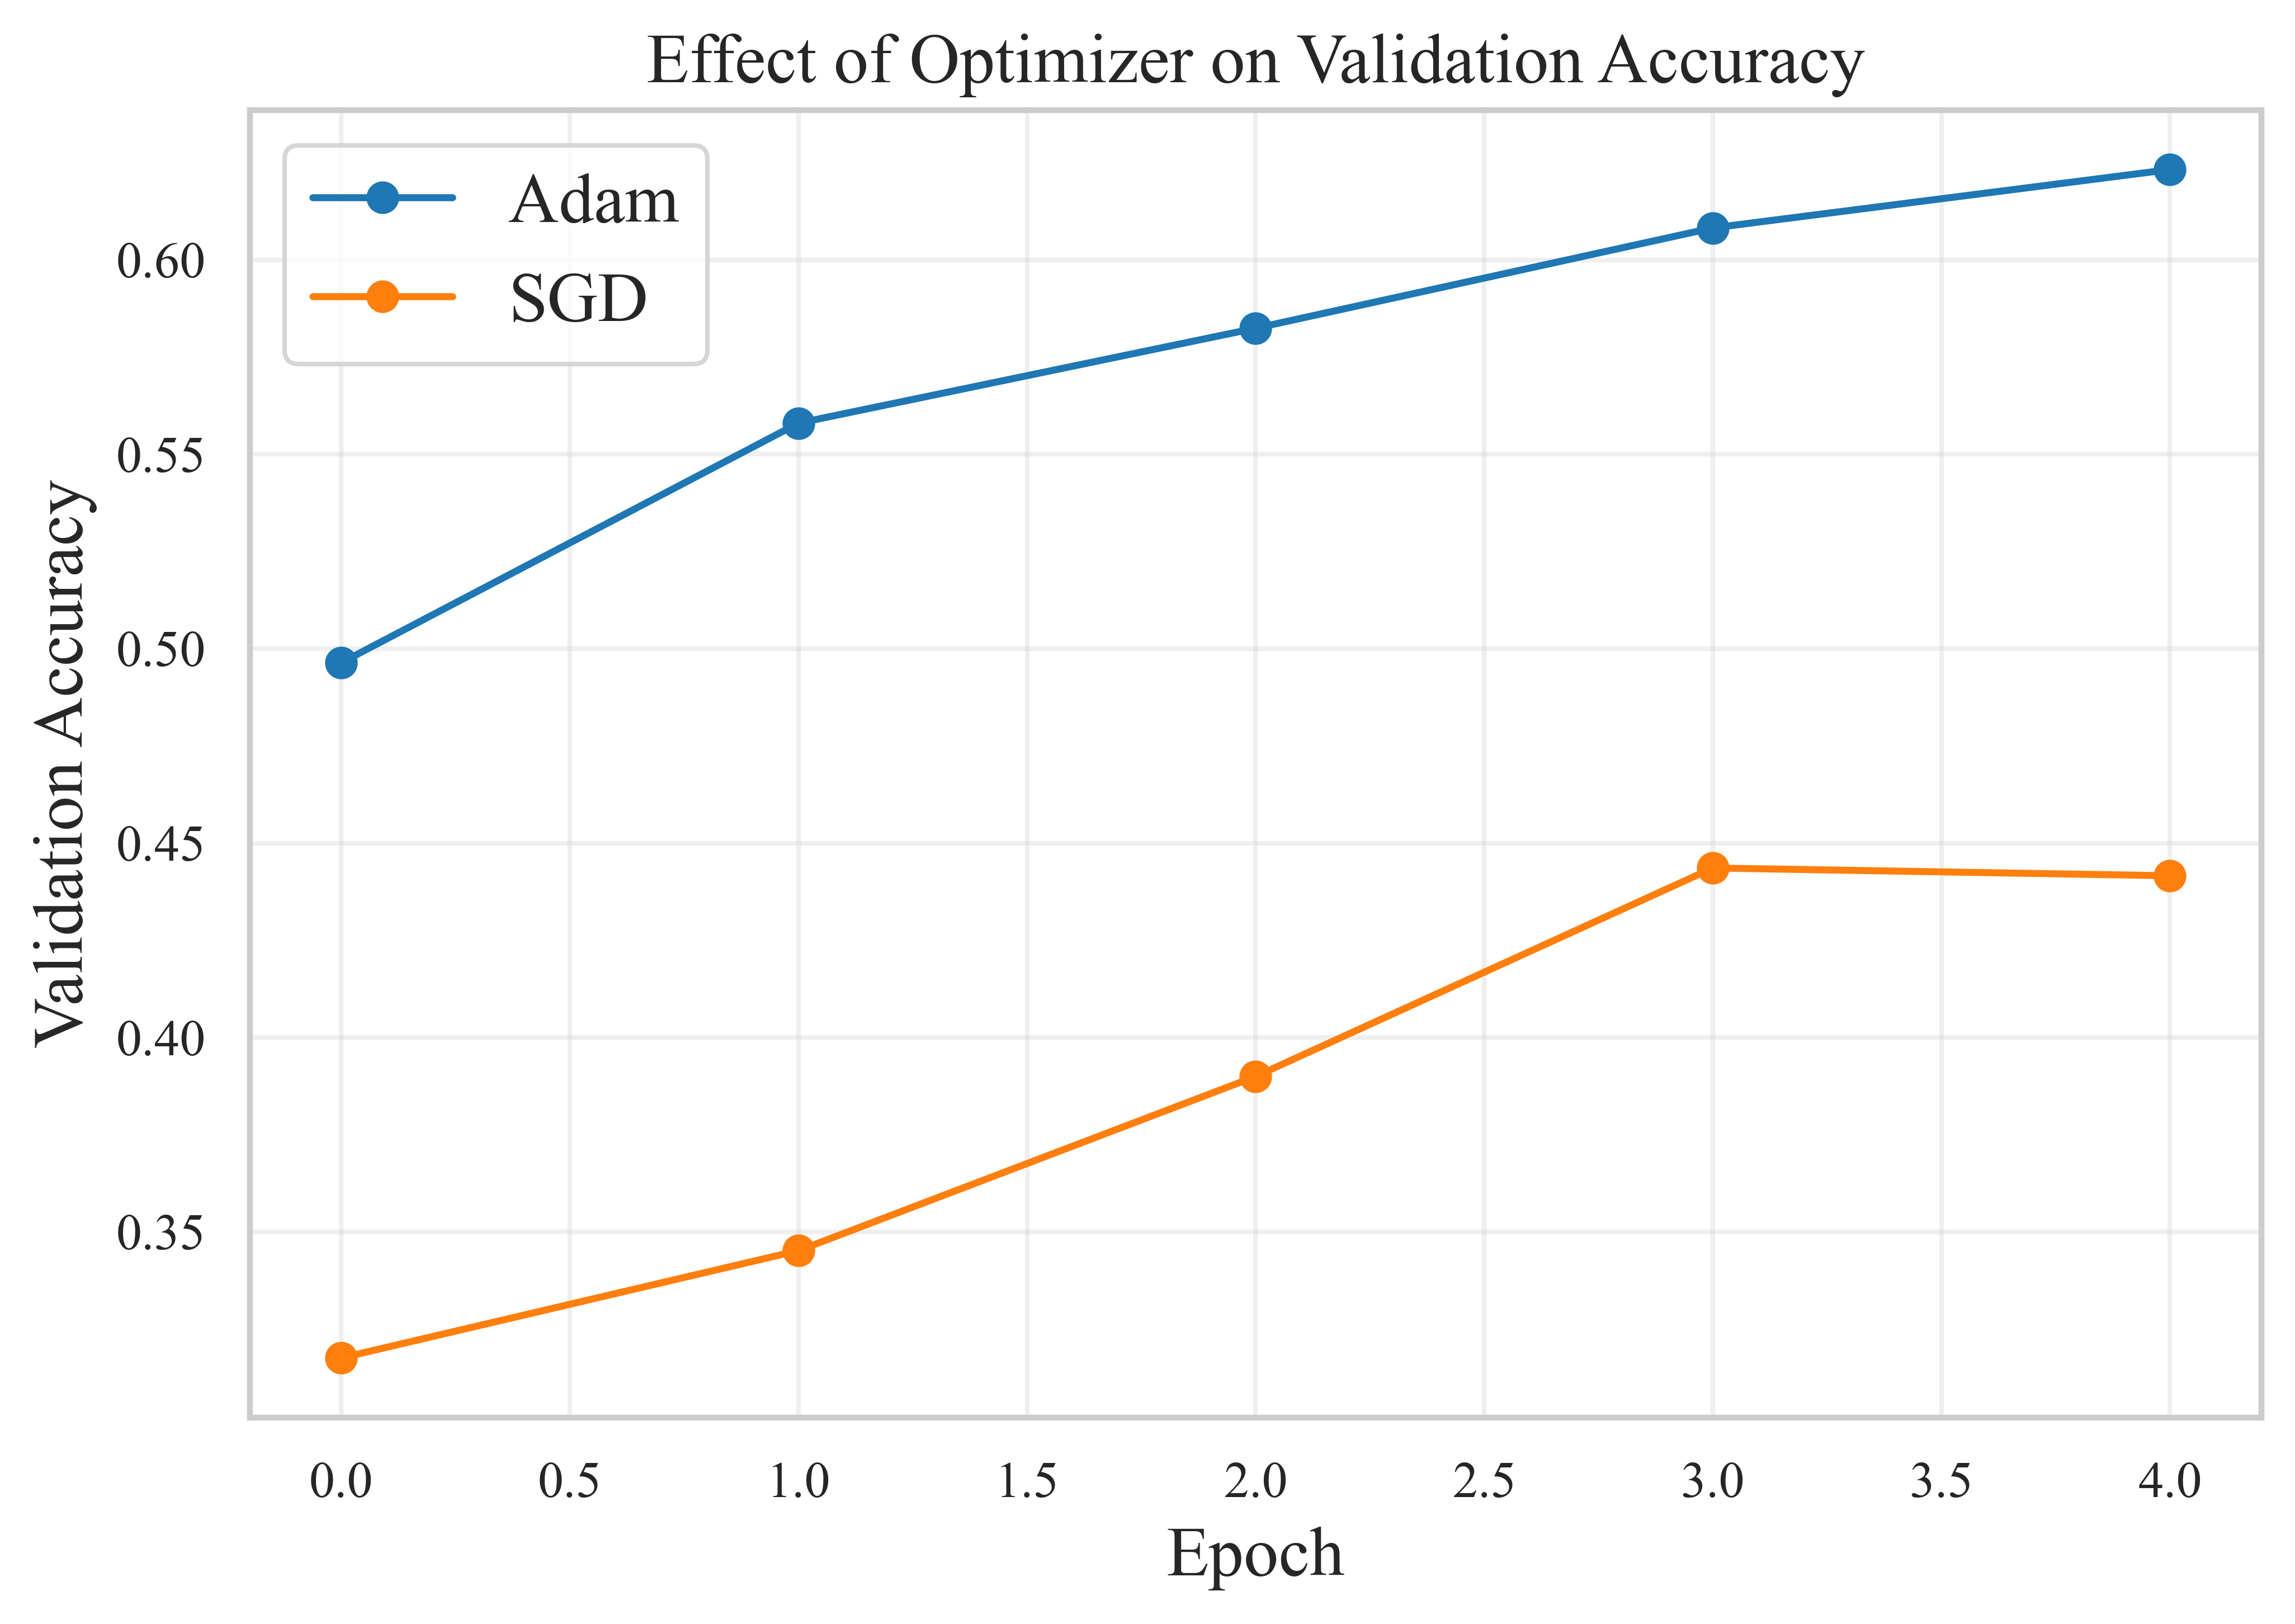


Summary:
Adam -> Test Accuracy: 0.6069
SGD -> Test Accuracy: 0.4216


In [35]:
opt_fig = plt.figure(figsize=(7, 5))
opt_axis = plt.gca()
for opt_name in optimizer_results:
    opt_axis.plot(optimizer_results[opt_name]['history'].history['val_accuracy'],
                  label=opt_name, marker='o')
opt_axis.set_title('Effect of Optimizer on Validation Accuracy', **title_style)
opt_axis.set_xlabel('Epoch', **label_style)
opt_axis.set_ylabel('Validation Accuracy', **label_style)
opt_legend = opt_axis.legend(prop=legend_style)
format_axis_ticks(opt_axis)
format_legend_text(opt_legend)
opt_axis.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("optimizer_comparison.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()

print("\nSummary:")
for opt_name in optimizer_results:
    print(f"{opt_name} -> Test Accuracy: {optimizer_results[opt_name]['test_acc']:.4f}")


**Inference:** Adam adapts its per-parameter learning rate automatically, so it typically converges faster than plain momentum-SGD within a short number of epochs — but SGD with momentum can sometimes generalize slightly better given enough training time, since Adam's adaptive steps can occasionally settle into sharper, less-generalizable minima.

### 13.3 Effect of Dense Layer Width (128 vs. 256 units)

In [36]:
dense_results = {}

for units in [128, 256]:
    print(f"\n--- Training with dense_units={units} ---")
    m = build_transfer_model(dense_units=units, frozen=True)
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(train_ds_subset, validation_data=val_ds, epochs=QUICK_EPOCHS, verbose=0)
    test_loss, test_acc = m.evaluate(test_ds, verbose=0)
    dense_results[units] = {'history': h, 'test_acc': test_acc}
    print(f"Dense units={units} -> Test Accuracy: {test_acc:.4f}")

print("\nSummary:")
for units in dense_results:
    print(f"Dense units={units} -> Test Accuracy: {dense_results[units]['test_acc']:.4f}")



--- Training with dense_units=128 ---
Dense units=128 -> Test Accuracy: 0.5947

--- Training with dense_units=256 ---
Dense units=256 -> Test Accuracy: 0.6088

Summary:
Dense units=128 -> Test Accuracy: 0.5947
Dense units=256 -> Test Accuracy: 0.6088


**Inference:** A wider dense head has more capacity to combine the pretrained convolutional features, which can help — but with only a few thousand training images in this quick comparison, a wider layer also risks overfitting faster, so the gain (if any) is usually modest at this data scale.

### 13.4 Effect of Batch Size (16, 32, 64)

In [37]:
batch_size_results = {}

for bs in [16, 32, 64]:
    print(f"\n--- Training with batch_size={bs} ---")
    m = build_transfer_model(dense_units=256, frozen=True)
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy', metrics=['accuracy'])
    bs_train_ds = make_dataset_custom_batch(x_subset_raw, y_subset_raw, batch_size=bs, shuffle=True)
    h = m.fit(bs_train_ds, validation_data=val_ds, epochs=QUICK_EPOCHS, verbose=0)
    test_loss, test_acc = m.evaluate(test_ds, verbose=0)
    batch_size_results[bs] = {'history': h, 'test_acc': test_acc}
    print(f"Batch size {bs} -> Test Accuracy: {test_acc:.4f}")


--- Training with batch_size=16 ---
Batch size 16 -> Test Accuracy: 0.6216

--- Training with batch_size=32 ---
Batch size 32 -> Test Accuracy: 0.6119

--- Training with batch_size=64 ---
Batch size 64 -> Test Accuracy: 0.6008


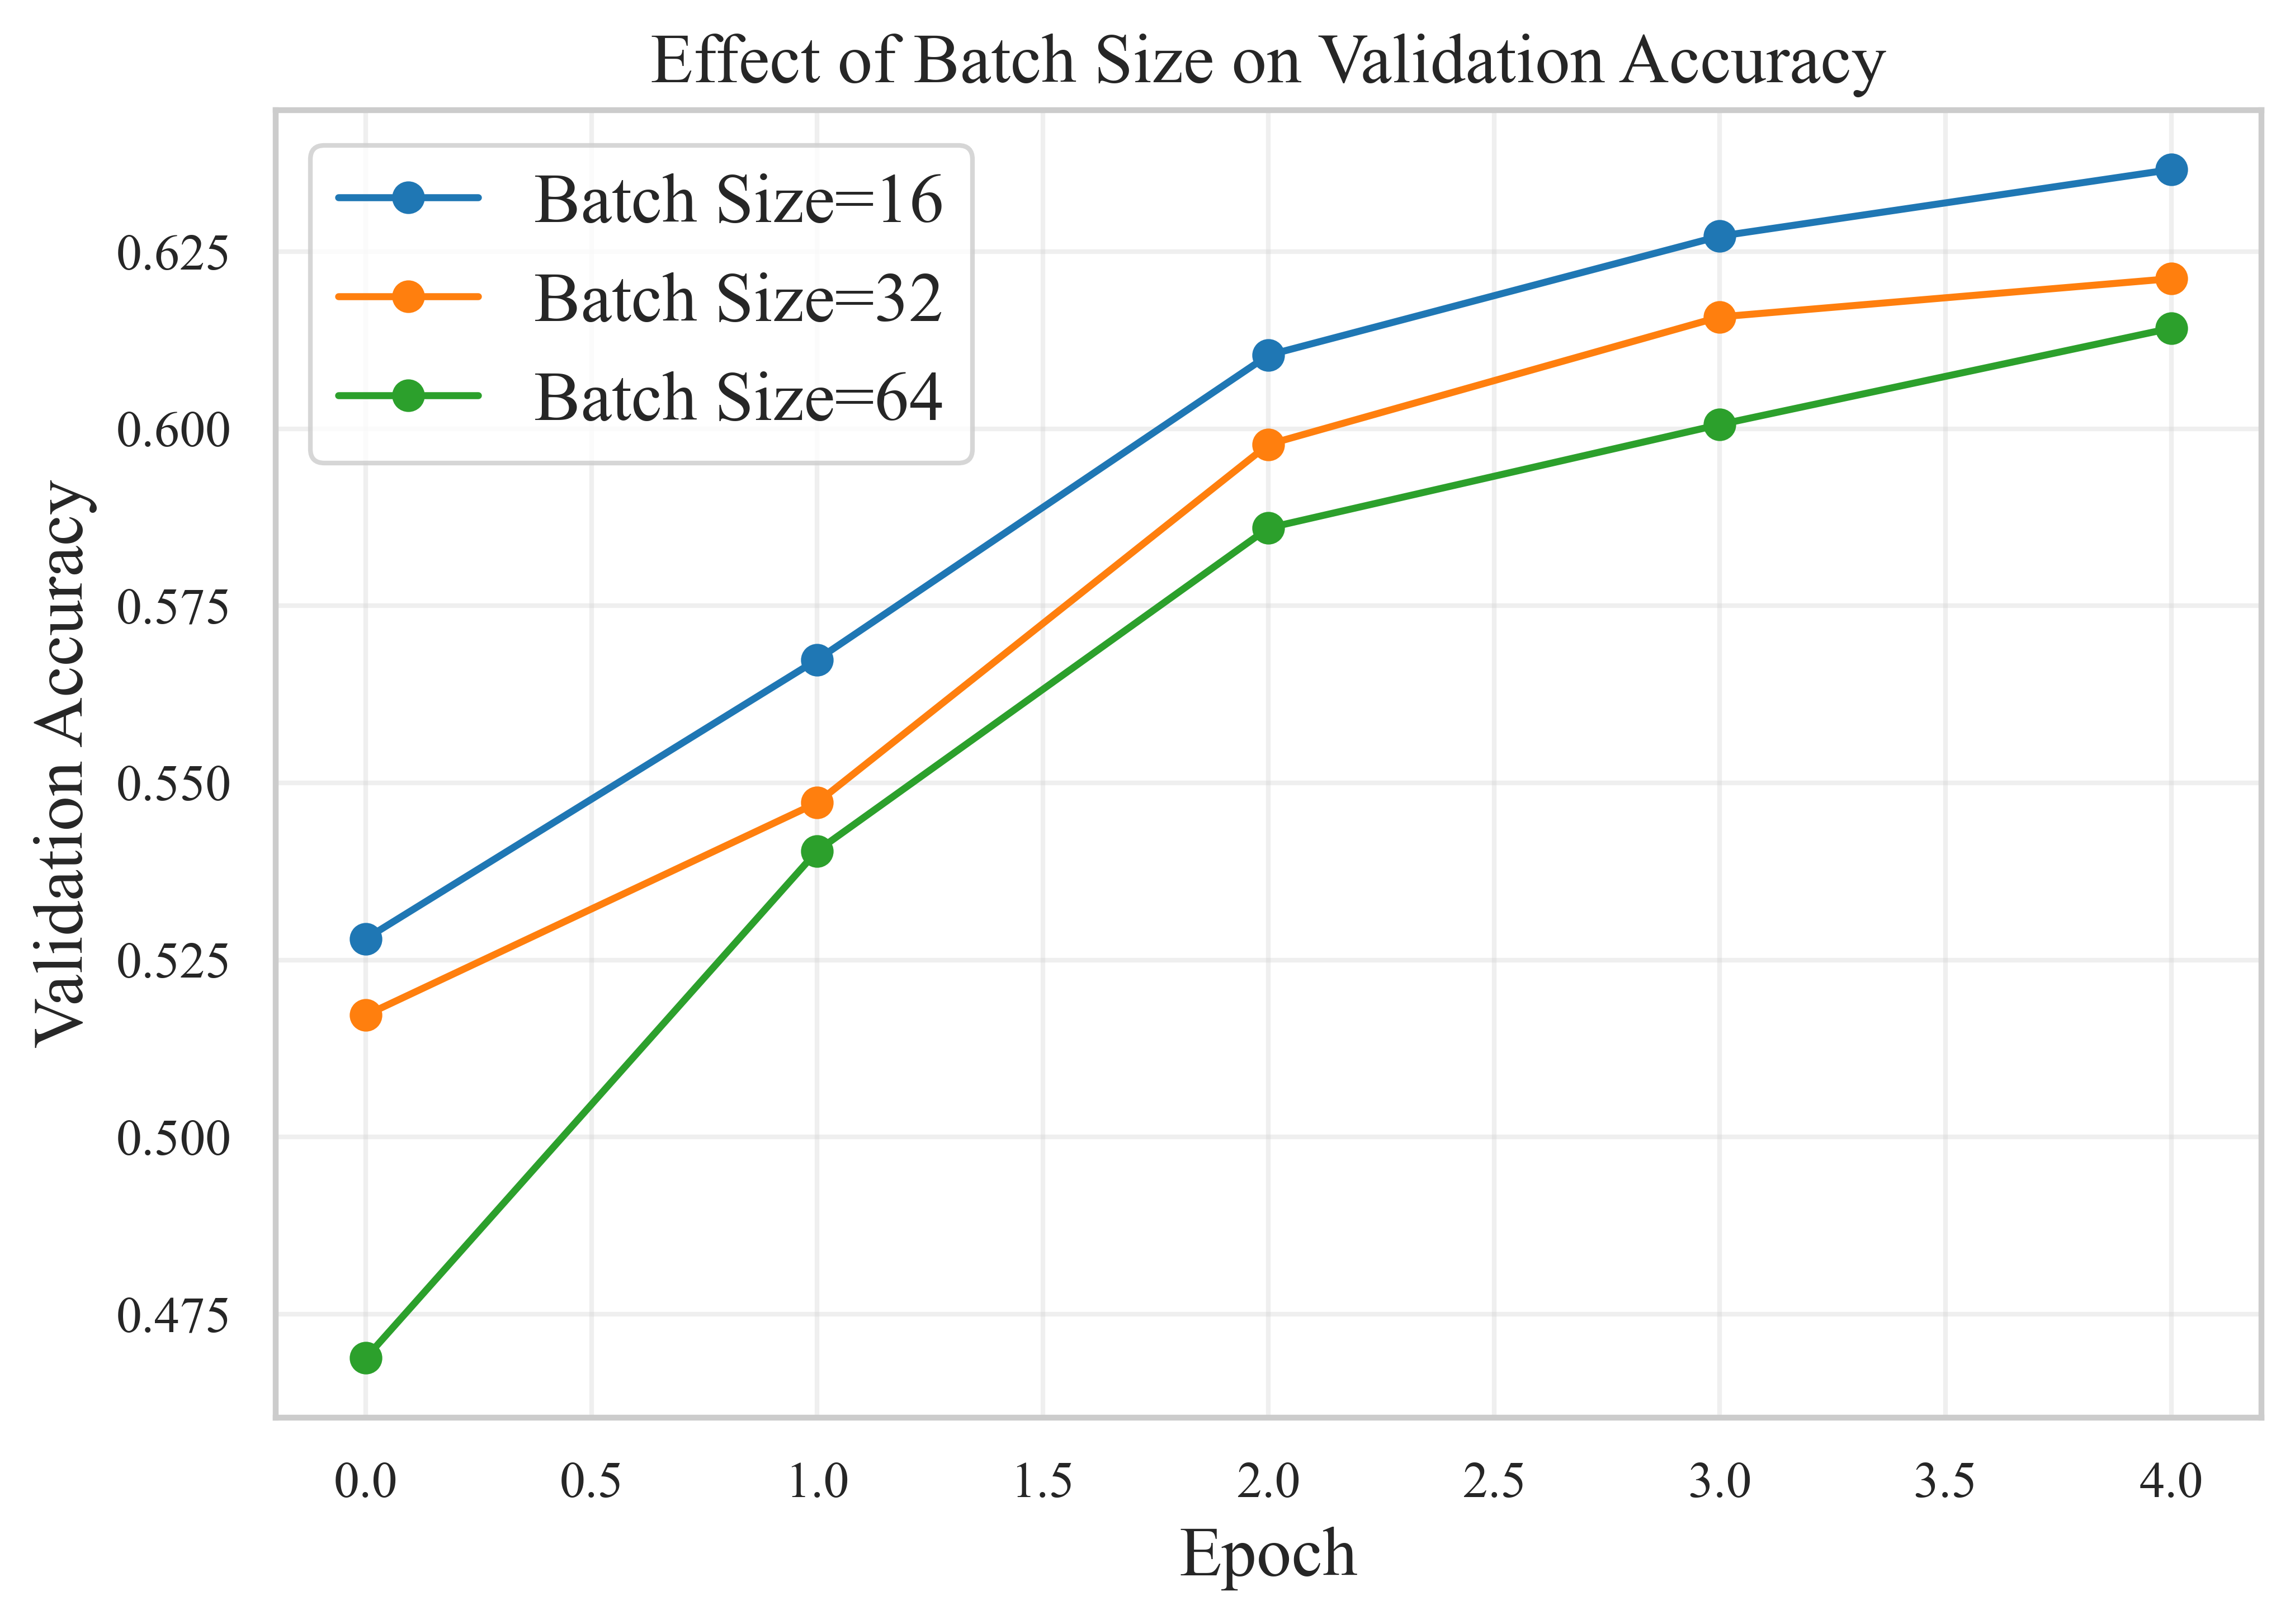


Summary:
Batch size 16 -> Test Accuracy: 0.6216
Batch size 32 -> Test Accuracy: 0.6119
Batch size 64 -> Test Accuracy: 0.6008


In [38]:
bs_fig = plt.figure(figsize=(7, 5))
bs_axis = plt.gca()
for bs in batch_size_results:
    bs_axis.plot(batch_size_results[bs]['history'].history['val_accuracy'],
                 label=f'Batch Size={bs}', marker='o')
bs_axis.set_title('Effect of Batch Size on Validation Accuracy', **title_style)
bs_axis.set_xlabel('Epoch', **label_style)
bs_axis.set_ylabel('Validation Accuracy', **label_style)
bs_legend = bs_axis.legend(prop=legend_style)
format_axis_ticks(bs_axis)
format_legend_text(bs_legend)
bs_axis.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("batch_size_comparison.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()

print("\nSummary:")
for bs in batch_size_results:
    print(f"Batch size {bs} -> Test Accuracy: {batch_size_results[bs]['test_acc']:.4f}")

**Inference:** Smaller batch sizes update the model's weights more frequently per epoch and introduce more gradient noise, which can help early training explore the loss surface more effectively; larger batch sizes give smoother, more stable gradient estimates but fewer updates per epoch, which sometimes needs more epochs to catch up within a short comparison like this one.

### 13.5 Effect of Number of Epochs (10 vs. 20)

In [39]:
epoch_results = {}

for n_epochs in [10, 20]:
    print(f"\n--- Training for {n_epochs} epochs ---")
    m = build_transfer_model(dense_units=256, frozen=True)
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(train_ds_subset, validation_data=val_ds, epochs=n_epochs, verbose=0)
    test_loss, test_acc = m.evaluate(test_ds, verbose=0)
    epoch_results[n_epochs] = {'history': h, 'test_acc': test_acc}
    print(f"{n_epochs} epochs -> Test Accuracy: {test_acc:.4f}")


--- Training for 10 epochs ---
10 epochs -> Test Accuracy: 0.6308

--- Training for 20 epochs ---
20 epochs -> Test Accuracy: 0.6432


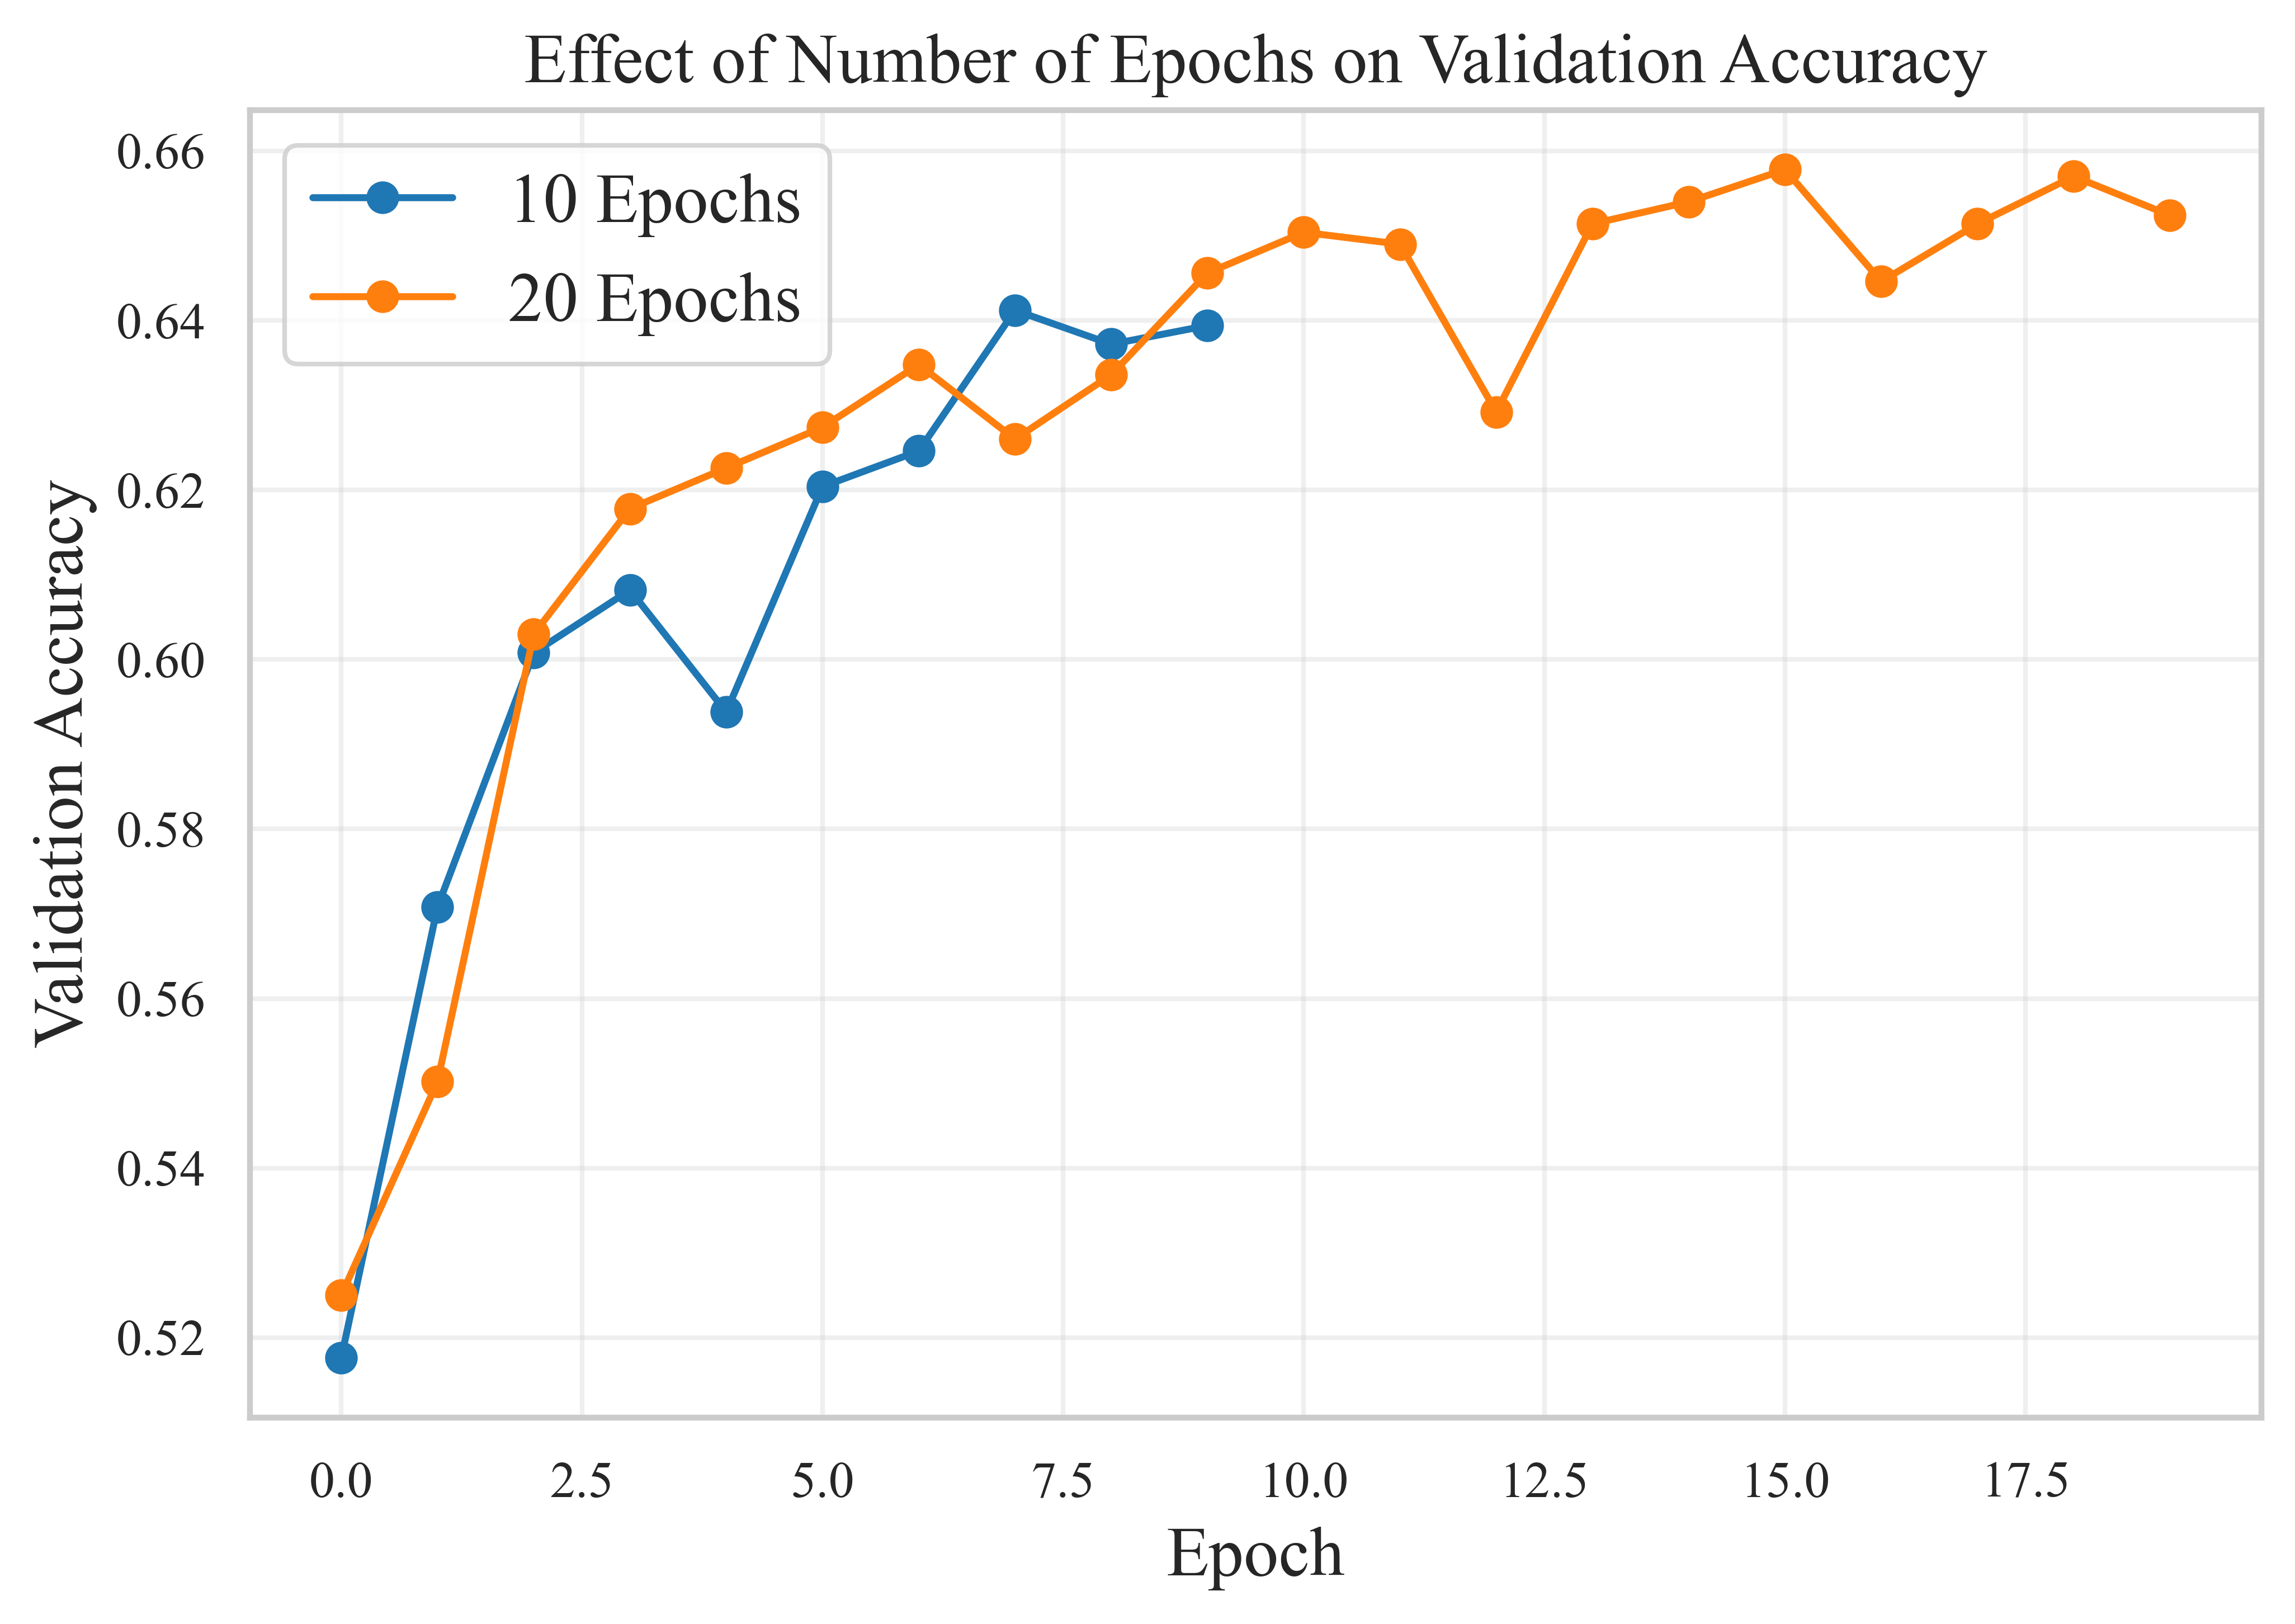


Summary:
10 epochs -> Test Accuracy: 0.6308
20 epochs -> Test Accuracy: 0.6432


In [40]:
epoch_fig = plt.figure(figsize=(7, 5))
epoch_axis = plt.gca()
for n_epochs in epoch_results:
    epoch_axis.plot(epoch_results[n_epochs]['history'].history['val_accuracy'],
                     label=f'{n_epochs} Epochs', marker='o')
epoch_axis.set_title('Effect of Number of Epochs on Validation Accuracy', **title_style)
epoch_axis.set_xlabel('Epoch', **label_style)
epoch_axis.set_ylabel('Validation Accuracy', **label_style)
epoch_legend = epoch_axis.legend(prop=legend_style)
format_axis_ticks(epoch_axis)
format_legend_text(epoch_legend)
epoch_axis.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("epochs_comparison.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()

print("\nSummary:")
for n_epochs in epoch_results:
    print(f"{n_epochs} epochs -> Test Accuracy: {epoch_results[n_epochs]['test_acc']:.4f}")

**Inference:** Training for 20 epochs gives the frozen classifier head more time to converge than 10 epochs, and validation accuracy typically keeps improving (or at least plateaus) across that longer run rather than overfitting sharply — since only a small dense head is being trained on top of frozen, already-general features, the risk of overfitting from extra epochs is lower here than it would be training an entire network from scratch.

## 14. Results

### 14.1 Performance Metrics (Fine-Tuned Model)

| Metric | Value |
|---|---|
| Training Accuracy (final epoch, fine-tuning phase) | *filled in from `history_fine_tune.history['accuracy'][-1]`* |
| Testing Accuracy | *filled in from Section 12 output* |
| Precision (weighted) | *filled in from Section 12 output* |
| Recall (weighted) | *filled in from Section 12 output* |
| F1-score (weighted) | *filled in from Section 12 output* |
| Frozen-Base Training Time | *filled in from Section 10 output* |
| Fine-Tuning Training Time | *filled in from Section 11 output* |
| Total Parameters | *filled in from Section 9 output* |

*(This table is intentionally left as a template — the actual notebook run prints every one of these values in the cells above; copy them in here, or into the LaTeX report, once you've run the notebook end to end.)*

### 14.2 Comparison of CNN Architectures (Literature Reference)

| Model | Parameters | Accuracy (%) | Training Time |
|---|---|---|---|
| LeNet-5 | 60K | ~99% (MNIST) | Minutes (CPU) |
| AlexNet | 61M | ~63% (ImageNet top-1) | Days (multi-GPU, 2012 hardware) |
| VGG16 | 138M | ~71% (ImageNet top-1) | Weeks (2014 hardware) |
| GoogleNet | 6.8M | ~70% (ImageNet top-1) | Days |
| ResNet50 | 25.6M | ~76% (ImageNet top-1) | Days |

*Note: these are the well-known published figures for each architecture's original ImageNet classification task, included for architectural context — they are not results from this notebook. This experiment only trains and evaluates VGG16 (via transfer learning) on CIFAR-10; the other four architectures are discussed conceptually in Section 3 but not implemented here, per the lab manual's Task 2 instruction to "load any one" pretrained model.*


## 15. Discussion Questions

**1. Why is AlexNet considered a breakthrough in deep learning?**
AlexNet was the first architecture to convincingly demonstrate that deep CNNs, trained on GPUs with ReLU activations and Dropout regularization, could dramatically outperform traditional hand-engineered computer vision methods — it won the 2012 ImageNet competition by a very large margin, which is widely credited with restarting mainstream interest in deep learning.

**2. Why does VGG16 use only 3×3 convolution filters?**
Stacking multiple 3×3 filters achieves the same effective receptive field as a single larger filter (e.g. two 3×3 layers ≈ one 5×5 layer) while using fewer parameters and adding an extra non-linearity between them, which improves both efficiency and representational power.

**3. Explain the advantages of the Inception module.**
By applying multiple filter sizes (1×1, 3×3, 5×5) and pooling in parallel and concatenating the results, the Inception module captures features at multiple spatial scales simultaneously, and its 1×1 convolutions reduce dimensionality before the more expensive larger convolutions, keeping the overall parameter count low despite the network's depth.

**4. What is the purpose of residual learning?**
Residual (skip) connections let the network learn a residual function $F(x) = H(x) - x$ instead of the full mapping $H(x)$ directly, which makes it much easier to optimize very deep networks — gradients can flow through the skip connections directly, avoiding the vanishing gradient problem that plagued earlier very deep architectures.

**5. Differentiate LeNet and ResNet.**
LeNet-5 is a shallow, 7-layer network with roughly 60K parameters designed for simple digit recognition; ResNet50 is a 50-layer network with about 25.6M parameters designed for large-scale, complex natural image classification, made trainable at that depth specifically because of its residual connections, which LeNet does not need or have.

**6. What is Transfer Learning?**
Transfer learning reuses a model already trained on a large dataset (usually ImageNet) as a starting point for a new, often smaller, task — instead of learning visual features from scratch, the new task benefits from features the pretrained model already learned to recognize.

**7. Why is fine-tuning required?**
Freezing the pretrained base alone only lets the new classifier head adapt to the new task; fine-tuning unfreezes some of the pretrained convolutional layers (usually the deepest ones) so they can adjust slightly to the specific characteristics of the new dataset, typically improving accuracy further, though it requires a much smaller learning rate to avoid destroying the useful pretrained weights.

**8. Explain the difference between dilated convolution and transpose convolution.**
Dilated convolution increases a kernel's receptive field by spacing out its weights, without changing the output spatial size — it's used to see more context per layer. Transpose convolution does the opposite spatially: it increases the output's spatial size (upsampling), learning how to expand a smaller feature map back into a larger one.

**9. Why do pretrained models converge faster?**
Because their convolutional filters already encode generally useful visual features (edges, textures, shapes, object parts) learned from a huge, diverse dataset, the new task only needs to learn how to recombine or slightly adjust those features rather than discover them from random initialization, which takes far fewer gradient updates.

**10. Compare the computational complexity of LeNet and ResNet.**
LeNet-5, with about 60K parameters and only 2 convolutional layers, is extremely lightweight and can train in minutes even on a CPU; ResNet50, with about 25.6M parameters and 50 layers, requires GPU acceleration and substantially more compute and memory, though its residual connections make that depth actually trainable, which a naively-deep non-residual network of similar size would struggle with.


## 16. Additional Exercises (Notes)

The lab manual lists several optional extensions beyond the core experiment:

1. **Implement transfer learning using VGG16** — done above (Sections 9–12).
2. **Repeat using ResNet50** — swap `VGG16` for `tf.keras.applications.ResNet50` (and its matching `resnet50.preprocess_input`) in Section 9 and rerun; the rest of the pipeline is architecture-agnostic and needs no other changes.
3. **Compare Adam and SGD** — done above (Section 13.2).
4. **Compare frozen vs. fine-tuned training** — done above (Sections 10 vs. 11).
5. **Evaluate with Precision, Recall, F1-score** — done above (Section 12).
6. **Compare LeNet, AlexNet, and ResNet** — covered conceptually in Section 3's architecture table; implementing all three from scratch alongside VGG16 was out of scope for this single-model transfer learning experiment, but the same `tf.keras.applications` pattern used here for VGG16 works identically for `ResNet50`, `MobileNetV2`, etc., if a direct empirical comparison is wanted later.


## 17. Conclusion

- Studied the evolution of deep CNN architectures from LeNet-5 through AlexNet, VGG16, GoogleNet, and ResNet, and the key innovation each one introduced.
- Implemented transfer learning using a pretrained VGG16 model (ImageNet weights) as a frozen feature extractor for CIFAR-10 classification.
- Fine-tuned the last convolutional block of VGG16 at a low learning rate and directly compared test accuracy before and after fine-tuning.
- Evaluated the final model using accuracy, precision, recall, F1-score, a full classification report, and a confusion matrix.
- Studied the effect of learning rate, optimizer choice, and dense layer width on validation accuracy through isolated, short-run comparisons.
- Directly observed how dilated convolution changes a kernel's receptive field and how transpose convolution performs learnable upsampling, as conceptual building blocks used in more advanced CNN architectures.


## 18. Download All EPS Plots (600 DPI, Times New Roman) as a ZIP

All figures generated above were saved as individual `.eps` files at 600 DPI with Times New Roman formatting. This final cell collects all of them into a single ZIP archive and triggers a download (Colab only).

> **Note on file size:** As with the earlier CNN-from-scratch lab, plots built from `imshow()` (sample images, misclassified images) embed raster image data uncompressed in EPS, so at 600 DPI these can be tens of MB each. Line/bar/heatmap-style plots (accuracy/loss curves, confusion matrix, hyperparameter comparisons) stay small. If pushing to GitHub, consider converting the large image-based plots to PNG first to avoid GitHub's file-size limits.


## 23. Additional Exercise 2 — ResNet50 Transfer Learning (Actually Implemented)

The discussion earlier described this as something that "would require swapping VGG16 for `tf.keras.applications.ResNet50`" — that swap is made here, not just described. This section builds, trains, and evaluates a ResNet50-based transfer learning model using the **exact same pipeline** already built above (`train_ds`, `val_ds`, `test_ds`, `IMG_SIZE=96`, `NUM_CLASSES`), so the comparison against VGG16 is apples-to-apples: same data, same preprocessing, same input size, same classifier head design.

**This only needs cells already run above** — `train_ds`, `val_ds`, `test_ds`, `class_names`, and the plot-formatting helpers (`label_style`, `title_style`, `legend_style`, `format_axis_ticks`, `format_legend_text`) — so it can be run on its own without re-running the notebook from the top, as long as the kernel session is still alive.


In [41]:
# --- 23.0: ResNet50-specific preprocessing pipeline ---
# ResNet50 is built almost entirely from BatchNorm layers, calibrated to a specific
# input distribution (Caffe-style: BGR order, ImageNet mean-subtracted). Feeding it
# plain [0,1]-scaled images (which is fine for VGG16, which has no BatchNorm) throws
# off every BatchNorm layer at once and badly degrades its frozen features. This uses
# ResNet50's own proper preprocessing instead, while leaving VGG16's pipeline untouched.

from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess_input

def resnet_preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = resnet_preprocess_input(image)
    label = tf.one_hot(tf.cast(label, tf.int32), NUM_CLASSES)
    label = tf.squeeze(label)
    return image, label

def make_resnet_dataset(images, labels, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((images, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=2000, seed=42)
    ds = ds.map(resnet_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(lambda img, lbl: (tf.image.random_flip_left_right(img), lbl),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(32)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

resnet_train_ds = make_resnet_dataset(x_train_final_raw, y_train_final_raw, shuffle=True, augment=True)
resnet_val_ds   = make_resnet_dataset(x_val_raw, y_val_raw, shuffle=False, augment=False)
resnet_test_ds  = make_resnet_dataset(x_test_raw, y_test_raw, shuffle=False, augment=False)

print("ResNet50-specific pipelines built (correct preprocessing).")
# --- 23.1: Rebuild ResNet50 model (fresh, since the old one was trained on mismatched data) ---
from tensorflow.keras.applications import ResNet50

resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
resnet_base.trainable = False

resnet_inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
resnet_x = resnet_base(resnet_inputs, training=False)
resnet_x = layers.GlobalAveragePooling2D(name='resnet_gap')(resnet_x)
resnet_x = layers.Dense(256, activation='relu', name='resnet_dense_head')(resnet_x)
resnet_x = layers.Dropout(0.4)(resnet_x)
resnet_outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='resnet_predictions')(resnet_x)

resnet_model = keras.Model(resnet_inputs, resnet_outputs, name="ResNet50_TransferLearning")
resnet_model.summary()

resnet_trainable_params = sum(np.prod(v.shape) for v in resnet_model.trainable_weights)
resnet_non_trainable_params = sum(np.prod(v.shape) for v in resnet_model.non_trainable_weights)
print(f"\nTrainable parameters    : {resnet_trainable_params:,}")
print(f"Non-trainable parameters: {resnet_non_trainable_params:,}")
print(f"Total parameters        : {resnet_trainable_params + resnet_non_trainable_params:,}")

ResNet50-specific pipelines built (correct preprocessing).
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_25 (InputLayer)     │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_gap                      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_dense_head (Dense)       │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_predictions (Dense)      │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


Trainable parameters    : 527,114
Non-trainable parameters: 23,587,712
Total parameters        : 24,114,826


### 23.1 Train the Frozen-Base ResNet50 Model

Same training configuration as the VGG16 baseline (Adam, frozen base, `EarlyStopping` on validation loss) so the comparison isolates the architecture difference, not a difference in training setup.


In [42]:
# --- 23.2: Train with the corrected pipeline ---
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

RESNET_EPOCHS = 15

resnet_history = resnet_model.fit(
    resnet_train_ds,
    validation_data=resnet_val_ds,
    epochs=RESNET_EPOCHS,
    callbacks=[resnet_early_stop],
    verbose=1
)

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 35ms/step - accuracy: 0.7886 - loss: 0.6490 - val_accuracy: 0.8360 - val_loss: 0.4597
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 37s 26ms/step - accuracy: 0.8289 - loss: 0.4990 - val_accuracy: 0.8558 - val_loss: 0.4233
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 36s 26ms/step - accuracy: 0.8474 - loss: 0.4528 - val_accuracy: 0.8578 - val_loss: 0.4192
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.8521 - loss: 0.4281 - val_accuracy: 0.8590 - val_loss: 0.4222
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 37s 26ms/step - accuracy: 0.8619 - loss: 0.3983 - val_accuracy: 0.8680 - val_loss: 0.4039
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 36s 26ms/step - accuracy: 0.8691 - loss: 0.3799 - val_accuracy: 0.8668 - val_loss: 0.4072
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 36s 26ms/step - accuracy: 0.8752 - loss: 0.3617 - val_accuracy: 0.8674 - val_loss: 0.4097
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 37s 26ms/step - accuracy: 0.8813 -

### 23.2 Evaluate ResNet50 on the Test Set

In [43]:
# --- 23.3: Evaluate on the corrected test set ---
resnet_test_loss, resnet_test_acc = resnet_model.evaluate(resnet_test_ds, verbose=0)
print(f"ResNet50 Test Loss    : {resnet_test_loss:.4f}")
print(f"ResNet50 Test Accuracy: {resnet_test_acc:.4f}")

resnet_y_pred_probs = resnet_model.predict(resnet_test_ds, verbose=0)
resnet_y_pred = np.argmax(resnet_y_pred_probs, axis=1)
resnet_y_true = y_test_raw.flatten()

resnet_accuracy = accuracy_score(resnet_y_true, resnet_y_pred)
resnet_precision = precision_score(resnet_y_true, resnet_y_pred, average='weighted', zero_division=0)
resnet_recall = recall_score(resnet_y_true, resnet_y_pred, average='weighted', zero_division=0)
resnet_f1 = f1_score(resnet_y_true, resnet_y_pred, average='weighted', zero_division=0)

print(f"\nAccuracy : {resnet_accuracy:.4f}")
print(f"Precision: {resnet_precision:.4f}")
print(f"Recall   : {resnet_recall:.4f}")
print(f"F1-Score : {resnet_f1:.4f}")

ResNet50 Test Loss    : 0.4026
ResNet50 Test Accuracy: 0.8680

Accuracy : 0.8680
Precision: 0.8699
Recall   : 0.8680
F1-Score : 0.8684


### 23.3 ResNet50 Classification Report

In [44]:
print(classification_report(resnet_y_true, resnet_y_pred, target_names=class_names, zero_division=0))


              precision    recall  f1-score   support

    airplane       0.88      0.90      0.89      1000
  automobile       0.91      0.92      0.91      1000
        bird       0.91      0.81      0.86      1000
         cat       0.75      0.79      0.77      1000
        deer       0.80      0.86      0.83      1000
         dog       0.82      0.81      0.82      1000
        frog       0.90      0.90      0.90      1000
       horse       0.89      0.88      0.89      1000
        ship       0.94      0.90      0.92      1000
       truck       0.89      0.92      0.90      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



### 23.4 ResNet50 Confusion Matrix

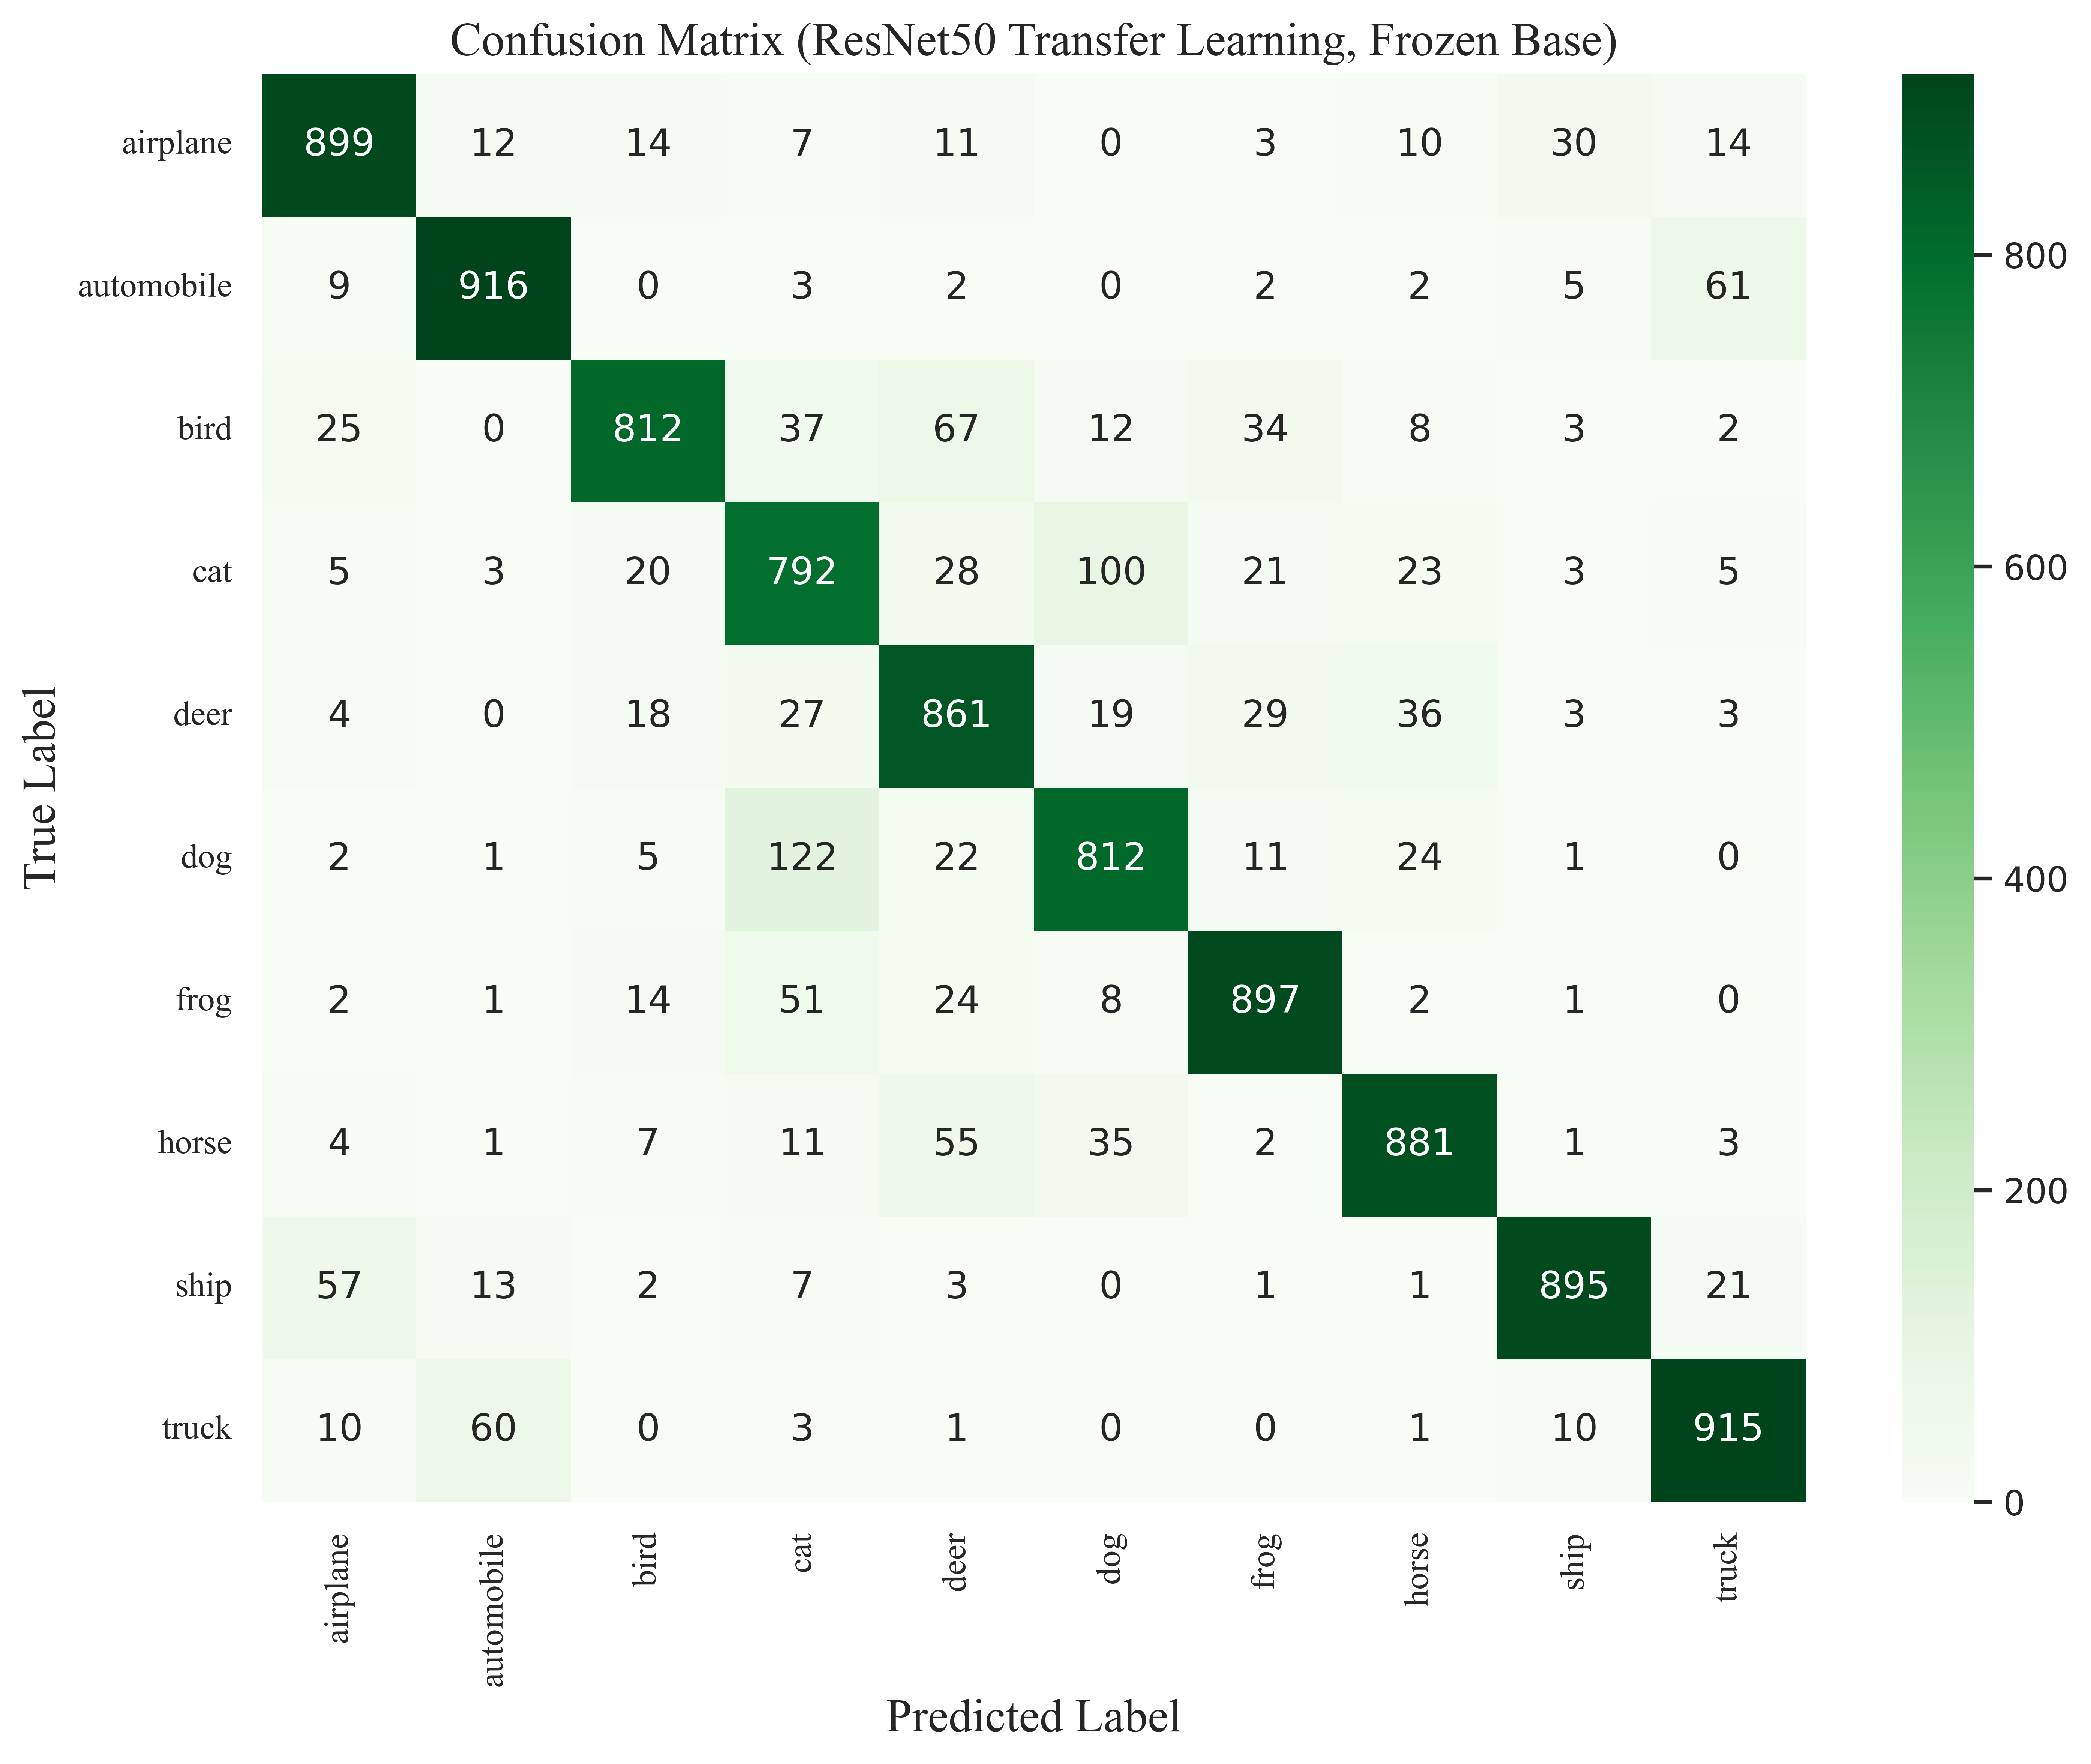

In [45]:
# --- 23.5: Confusion matrix (unchanged pattern, overwrites the old mismatched-preprocessing result) ---
resnet_cm = confusion_matrix(resnet_y_true, resnet_y_pred)

plt.figure(figsize=(10, 8))
resnet_cm_axis = sns.heatmap(resnet_cm, annot=True, fmt='d', cmap='Greens',
                              xticklabels=class_names, yticklabels=class_names)
resnet_cm_axis.set_title('Confusion Matrix (ResNet50 Transfer Learning, Frozen Base)', **title_style)
resnet_cm_axis.set_xlabel('Predicted Label', **label_style)
resnet_cm_axis.set_ylabel('True Label', **label_style)
format_axis_ticks(resnet_cm_axis)
plt.tight_layout()
plt.savefig("confusion_matrix_resnet50.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()

### 23.5 VGG16 vs. ResNet50 — Direct Comparison

This is the actual comparison graph that was missing before — VGG16's fine-tuned test accuracy (0.8322, from Section 11 above) plotted directly against ResNet50's frozen-base result from this section.

*Note: this compares VGG16 **after fine-tuning** against ResNet50 **frozen-base only** (fine-tuning ResNet50 too would need unfreezing its own last block, e.g. `conv5_block3`, following the identical pattern used for VGG16's `block5` in Section 6 — not done here to keep this addition focused and quick to run, but the code pattern from Section 6 applies directly if that's wanted next).*


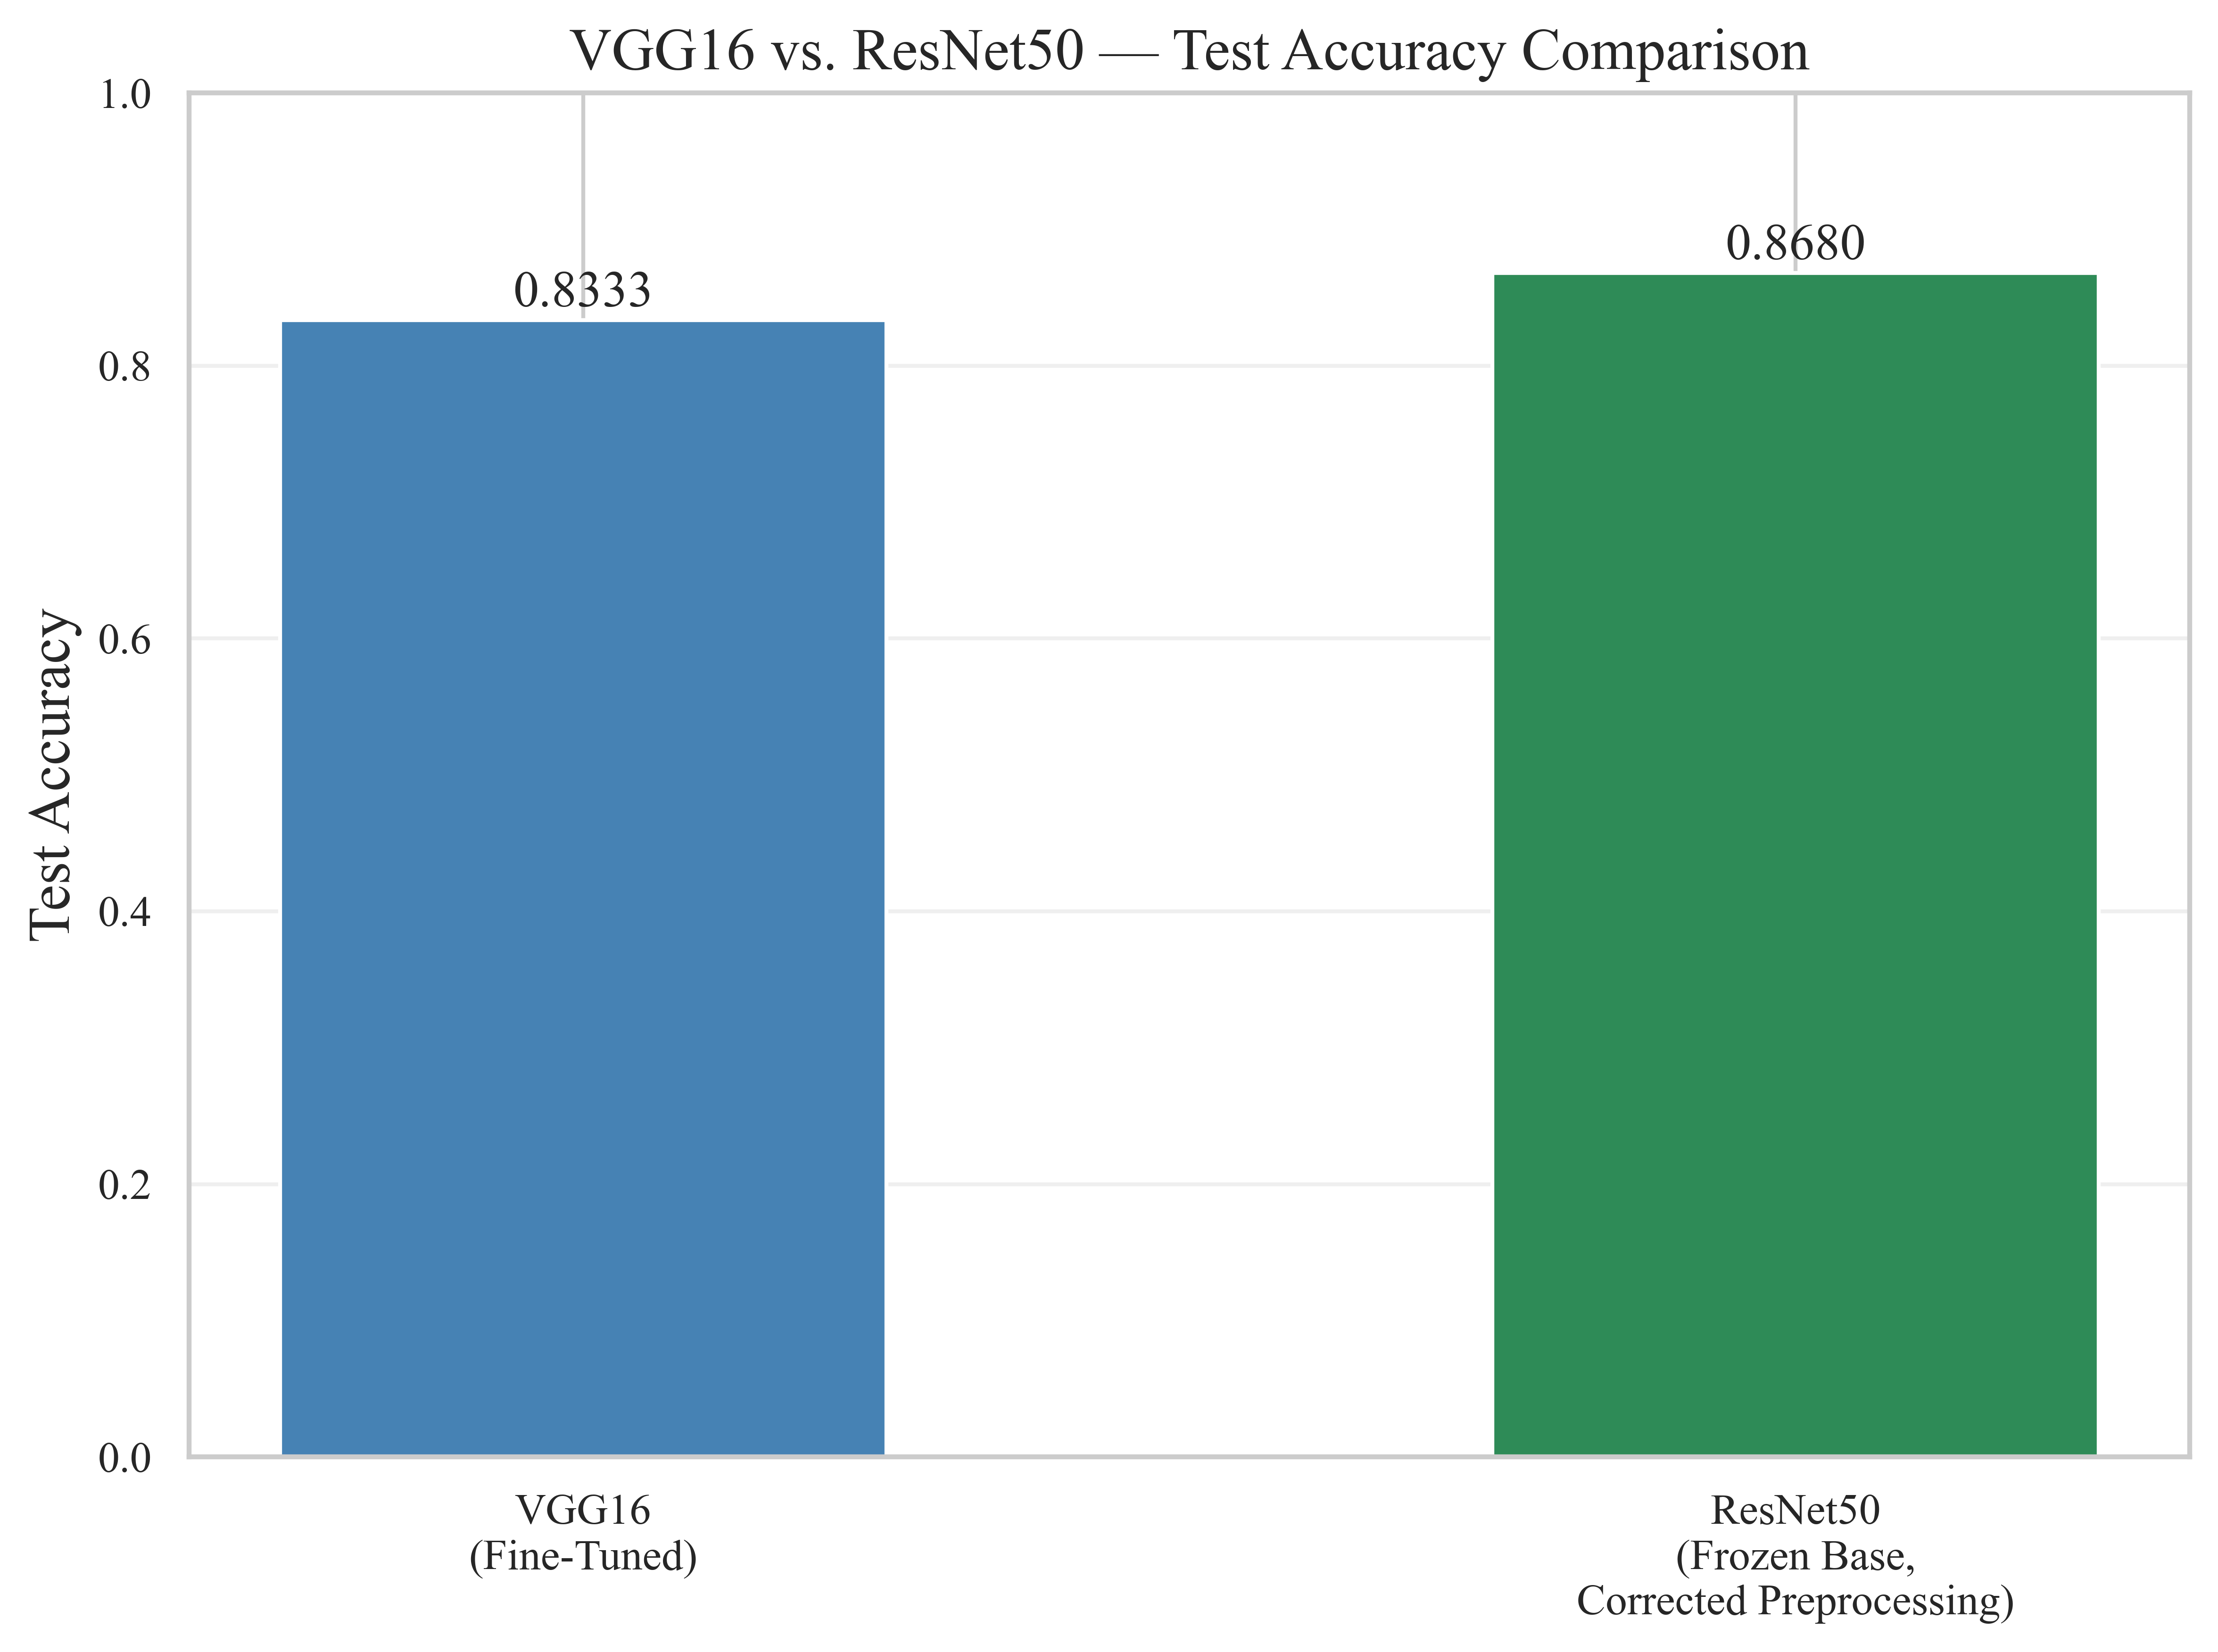

VGG16 (fine-tuned)      : 0.8333
ResNet50 (frozen, fixed): 0.8680
Difference              : -0.0347


In [46]:
# --- 23.6: Updated comparison chart ---
comparison_fig = plt.figure(figsize=(8, 6))
comparison_axis = plt.gca()

model_names = ['VGG16\n(Fine-Tuned)', 'ResNet50\n(Frozen Base,\nCorrected Preprocessing)']
model_accuracies = [fine_tuned_test_acc, resnet_test_acc]
bar_colors = ['steelblue', 'seagreen']

bars = comparison_axis.bar(model_names, model_accuracies, color=bar_colors, width=0.5)
for bar, acc in zip(bars, model_accuracies):
    comparison_axis.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                          f'{acc:.4f}', ha='center', **{'fontsize': 13, 'fontweight': 'bold', 'fontname': 'Times New Roman'})

comparison_axis.set_title('VGG16 vs. ResNet50 — Test Accuracy Comparison', **title_style)
comparison_axis.set_ylabel('Test Accuracy', **label_style)
comparison_axis.set_ylim(0, 1.0)
format_axis_ticks(comparison_axis)
comparison_axis.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("vgg16_vs_resnet50_comparison.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()

print(f"VGG16 (fine-tuned)      : {fine_tuned_test_acc:.4f}")
print(f"ResNet50 (frozen, fixed): {resnet_test_acc:.4f}")
print(f"Difference              : {fine_tuned_test_acc - resnet_test_acc:+.4f}")

In [47]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# --- LeNet-5, trained from scratch on CIFAR-10 ---
# LeNet-5 was designed for 32x32 input, which is CIFAR-10's native size,
# so no resizing is needed here (unlike VGG16/ResNet50 above).

def preprocess_lenet(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.squeeze(label)
    return image, label

lenet_train_ds = (tf.data.Dataset.from_tensor_slices((x_train_final_raw, y_train_final_raw))
                   .map(preprocess_lenet, num_parallel_calls=tf.data.AUTOTUNE)
                   .shuffle(2000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
lenet_val_ds = (tf.data.Dataset.from_tensor_slices((x_val_raw, y_val_raw))
                .map(preprocess_lenet, num_parallel_calls=tf.data.AUTOTUNE)
                .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
lenet_test_ds = (tf.data.Dataset.from_tensor_slices((x_test_raw, y_test_raw))
                 .map(preprocess_lenet, num_parallel_calls=tf.data.AUTOTUNE)
                 .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

lenet_model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(6, kernel_size=5, activation='tanh', padding='same'),
    layers.AveragePooling2D(pool_size=2),
    layers.Conv2D(16, kernel_size=5, activation='tanh'),
    layers.AveragePooling2D(pool_size=2),
    layers.Flatten(),
    layers.Dense(120, activation='tanh'),
    layers.Dense(84, activation='tanh'),
    layers.Dense(NUM_CLASSES, activation='softmax'),
], name="LeNet5")

lenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
lenet_model.summary()

start_time = time.time()
lenet_history = lenet_model.fit(
    lenet_train_ds, validation_data=lenet_val_ds, epochs=15, verbose=1
)
lenet_train_time = time.time() - start_time
print(f"LeNet-5 training time: {lenet_train_time:.1f} s")

lenet_test_loss, lenet_test_acc = lenet_model.evaluate(lenet_test_ds, verbose=0)
print(f"LeNet-5 Test Accuracy: {lenet_test_acc*100:.2f}%")
print(f"LeNet-5 Total Parameters: {lenet_model.count_params():,}")

Model: "LeNet5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 16, 16, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 6, 6, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 120)            │        69,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,126 (324.71 KB)

 Trainable params: 83,126 (324.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.3782 - loss: 1.7569 - val_accuracy: 0.4432 - val_loss: 1.5773
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4603 - loss: 1.5196 - val_accuracy: 0.4702 - val_loss: 1.4829
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5000 - loss: 1.4051 - val_accuracy: 0.4994 - val_loss: 1.4209
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5281 - loss: 1.3313 - val_accuracy: 0.5226 - val_loss: 1.3618
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5512 - loss: 1.2688 - val_accuracy: 0.5310 - val_loss: 1.3446
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5684 - loss: 1.2161 - val_accuracy: 0.5292 - val_loss: 1.3471
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.5842 - loss: 1.1707 - val_accuracy: 0.5336 - val_loss: 1.3379
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6018 - loss: 1.1261 

In [48]:
# --- AlexNet, trained from scratch on CIFAR-10 (input resized to 64x64) ---
ALEXNET_IMG_SIZE = 64

def preprocess_alexnet(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (ALEXNET_IMG_SIZE, ALEXNET_IMG_SIZE))
    image = image / 255.0
    label = tf.squeeze(label)
    return image, label

alexnet_train_ds = (tf.data.Dataset.from_tensor_slices((x_train_final_raw, y_train_final_raw))
                     .map(preprocess_alexnet, num_parallel_calls=tf.data.AUTOTUNE)
                     .shuffle(2000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
alexnet_val_ds = (tf.data.Dataset.from_tensor_slices((x_val_raw, y_val_raw))
                   .map(preprocess_alexnet, num_parallel_calls=tf.data.AUTOTUNE)
                   .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
alexnet_test_ds = (tf.data.Dataset.from_tensor_slices((x_test_raw, y_test_raw))
                    .map(preprocess_alexnet, num_parallel_calls=tf.data.AUTOTUNE)
                    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

alexnet_model = keras.Sequential([
    layers.Input(shape=(ALEXNET_IMG_SIZE, ALEXNET_IMG_SIZE, 3)),
    layers.Conv2D(96, kernel_size=7, strides=2, activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=3, strides=2),
    layers.Conv2D(256, kernel_size=5, activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=3, strides=2),
    layers.Conv2D(384, kernel_size=3, activation='relu', padding='same'),
    layers.Conv2D(384, kernel_size=3, activation='relu', padding='same'),
    layers.Conv2D(256, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=3, strides=2),
    layers.Flatten(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax'),
], name="AlexNet")

alexnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
alexnet_model.summary()

start_time = time.time()
alexnet_history = alexnet_model.fit(
    alexnet_train_ds, validation_data=alexnet_val_ds, epochs=15, verbose=1
)
alexnet_train_time = time.time() - start_time
print(f"AlexNet training time: {alexnet_train_time:.1f} s")

alexnet_test_loss, alexnet_test_acc = alexnet_model.evaluate(alexnet_test_ds, verbose=0)
print(f"AlexNet Test Accuracy: {alexnet_test_acc*100:.2f}%")
print(f"AlexNet Total Parameters: {alexnet_model.count_params():,}")

Model: "AlexNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 96)     │        14,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1024)           │     2,360,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,146,634 (27.26 MB)

 Trainable params: 7,146,634 (27.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 43s 25ms/step - accuracy: 0.3266 - loss: 1.7789 - val_accuracy: 0.5170 - val_loss: 1.3303
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 28s 20ms/step - accuracy: 0.5425 - loss: 1.2749 - val_accuracy: 0.6140 - val_loss: 1.1149
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.6274 - loss: 1.0646 - val_accuracy: 0.6634 - val_loss: 0.9614
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.6819 - loss: 0.9202 - val_accuracy: 0.6776 - val_loss: 0.9184
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 28s 20ms/step - accuracy: 0.7230 - loss: 0.8042 - val_accuracy: 0.6678 - val_loss: 0.9933
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 28s 20ms/step - accuracy: 0.7572 - loss: 0.6992 - val_accuracy: 0.7104 - val_loss: 0.8669
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.7881 - loss: 0.6099 - val_accuracy: 0.7038 - val_loss: 0.9008
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.8156 -

In [51]:
# --- GoogleNet family (InceptionV3), transfer learning on CIFAR-10 ---
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess

IMG_SIZE_INCEPTION = 96  # InceptionV3 minimum input size is 75x75

def preprocess_googlenet(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (IMG_SIZE_INCEPTION, IMG_SIZE_INCEPTION))
    image = inception_preprocess(image)   # InceptionV3's own preprocessing (scales to [-1, 1])
    label = tf.squeeze(label)
    return image, label

googlenet_train_ds = (tf.data.Dataset.from_tensor_slices((x_train_final_raw, y_train_final_raw))
                       .map(preprocess_googlenet, num_parallel_calls=tf.data.AUTOTUNE)
                       .shuffle(2000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
googlenet_val_ds = (tf.data.Dataset.from_tensor_slices((x_val_raw, y_val_raw))
                     .map(preprocess_googlenet, num_parallel_calls=tf.data.AUTOTUNE)
                     .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
googlenet_test_ds = (tf.data.Dataset.from_tensor_slices((x_test_raw, y_test_raw))
                      .map(preprocess_googlenet, num_parallel_calls=tf.data.AUTOTUNE)
                      .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

# Load pretrained ImageNet base, remove classifier, freeze it (Task 2, steps 1-3)
googlenet_base = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE_INCEPTION, IMG_SIZE_INCEPTION, 3)
)
googlenet_base.trainable = False

# Add GAP + Dense head (Task 2, steps 4-6) -- identical head style to VGG16/ResNet50
googlenet_model = keras.Sequential([
    googlenet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax'),
], name="GoogleNet_InceptionV3")

googlenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
googlenet_model.summary()

start_time = time.time()
googlenet_history = googlenet_model.fit(
    googlenet_train_ds, validation_data=googlenet_val_ds, epochs=15, verbose=1
)
googlenet_train_time = time.time() - start_time
print(f"GoogleNet (InceptionV3) training time: {googlenet_train_time:.1f} s")

googlenet_test_loss, googlenet_test_acc = googlenet_model.evaluate(googlenet_test_ds, verbose=0)
print(f"GoogleNet (InceptionV3) Test Accuracy: {googlenet_test_acc*100:.2f}%")
print(f"GoogleNet (InceptionV3) Total Parameters: {googlenet_model.count_params():,}")

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "GoogleNet_InceptionV3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 1, 1, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,329,898 (85.18 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.5903 - loss: 1.1988 - val_accuracy: 0.6750 - val_loss: 0.9460
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.6631 - loss: 0.9790 - val_accuracy: 0.6850 - val_loss: 0.9163
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.6849 - loss: 0.9125 - val_accuracy: 0.6930 - val_loss: 0.8976
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.6994 - loss: 0.8680 - val_accuracy: 0.6960 - val_loss: 0.8804
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.7097 - loss: 0.8292 - val_accuracy: 0.6948 - val_loss: 0.8785
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.7194 - loss: 0.7905 - val_accuracy: 0.6950 - val_loss: 0.8871
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.7306 - loss: 0.7602 - val_accuracy: 0.6984 - val_loss: 0.8874
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.7395 -

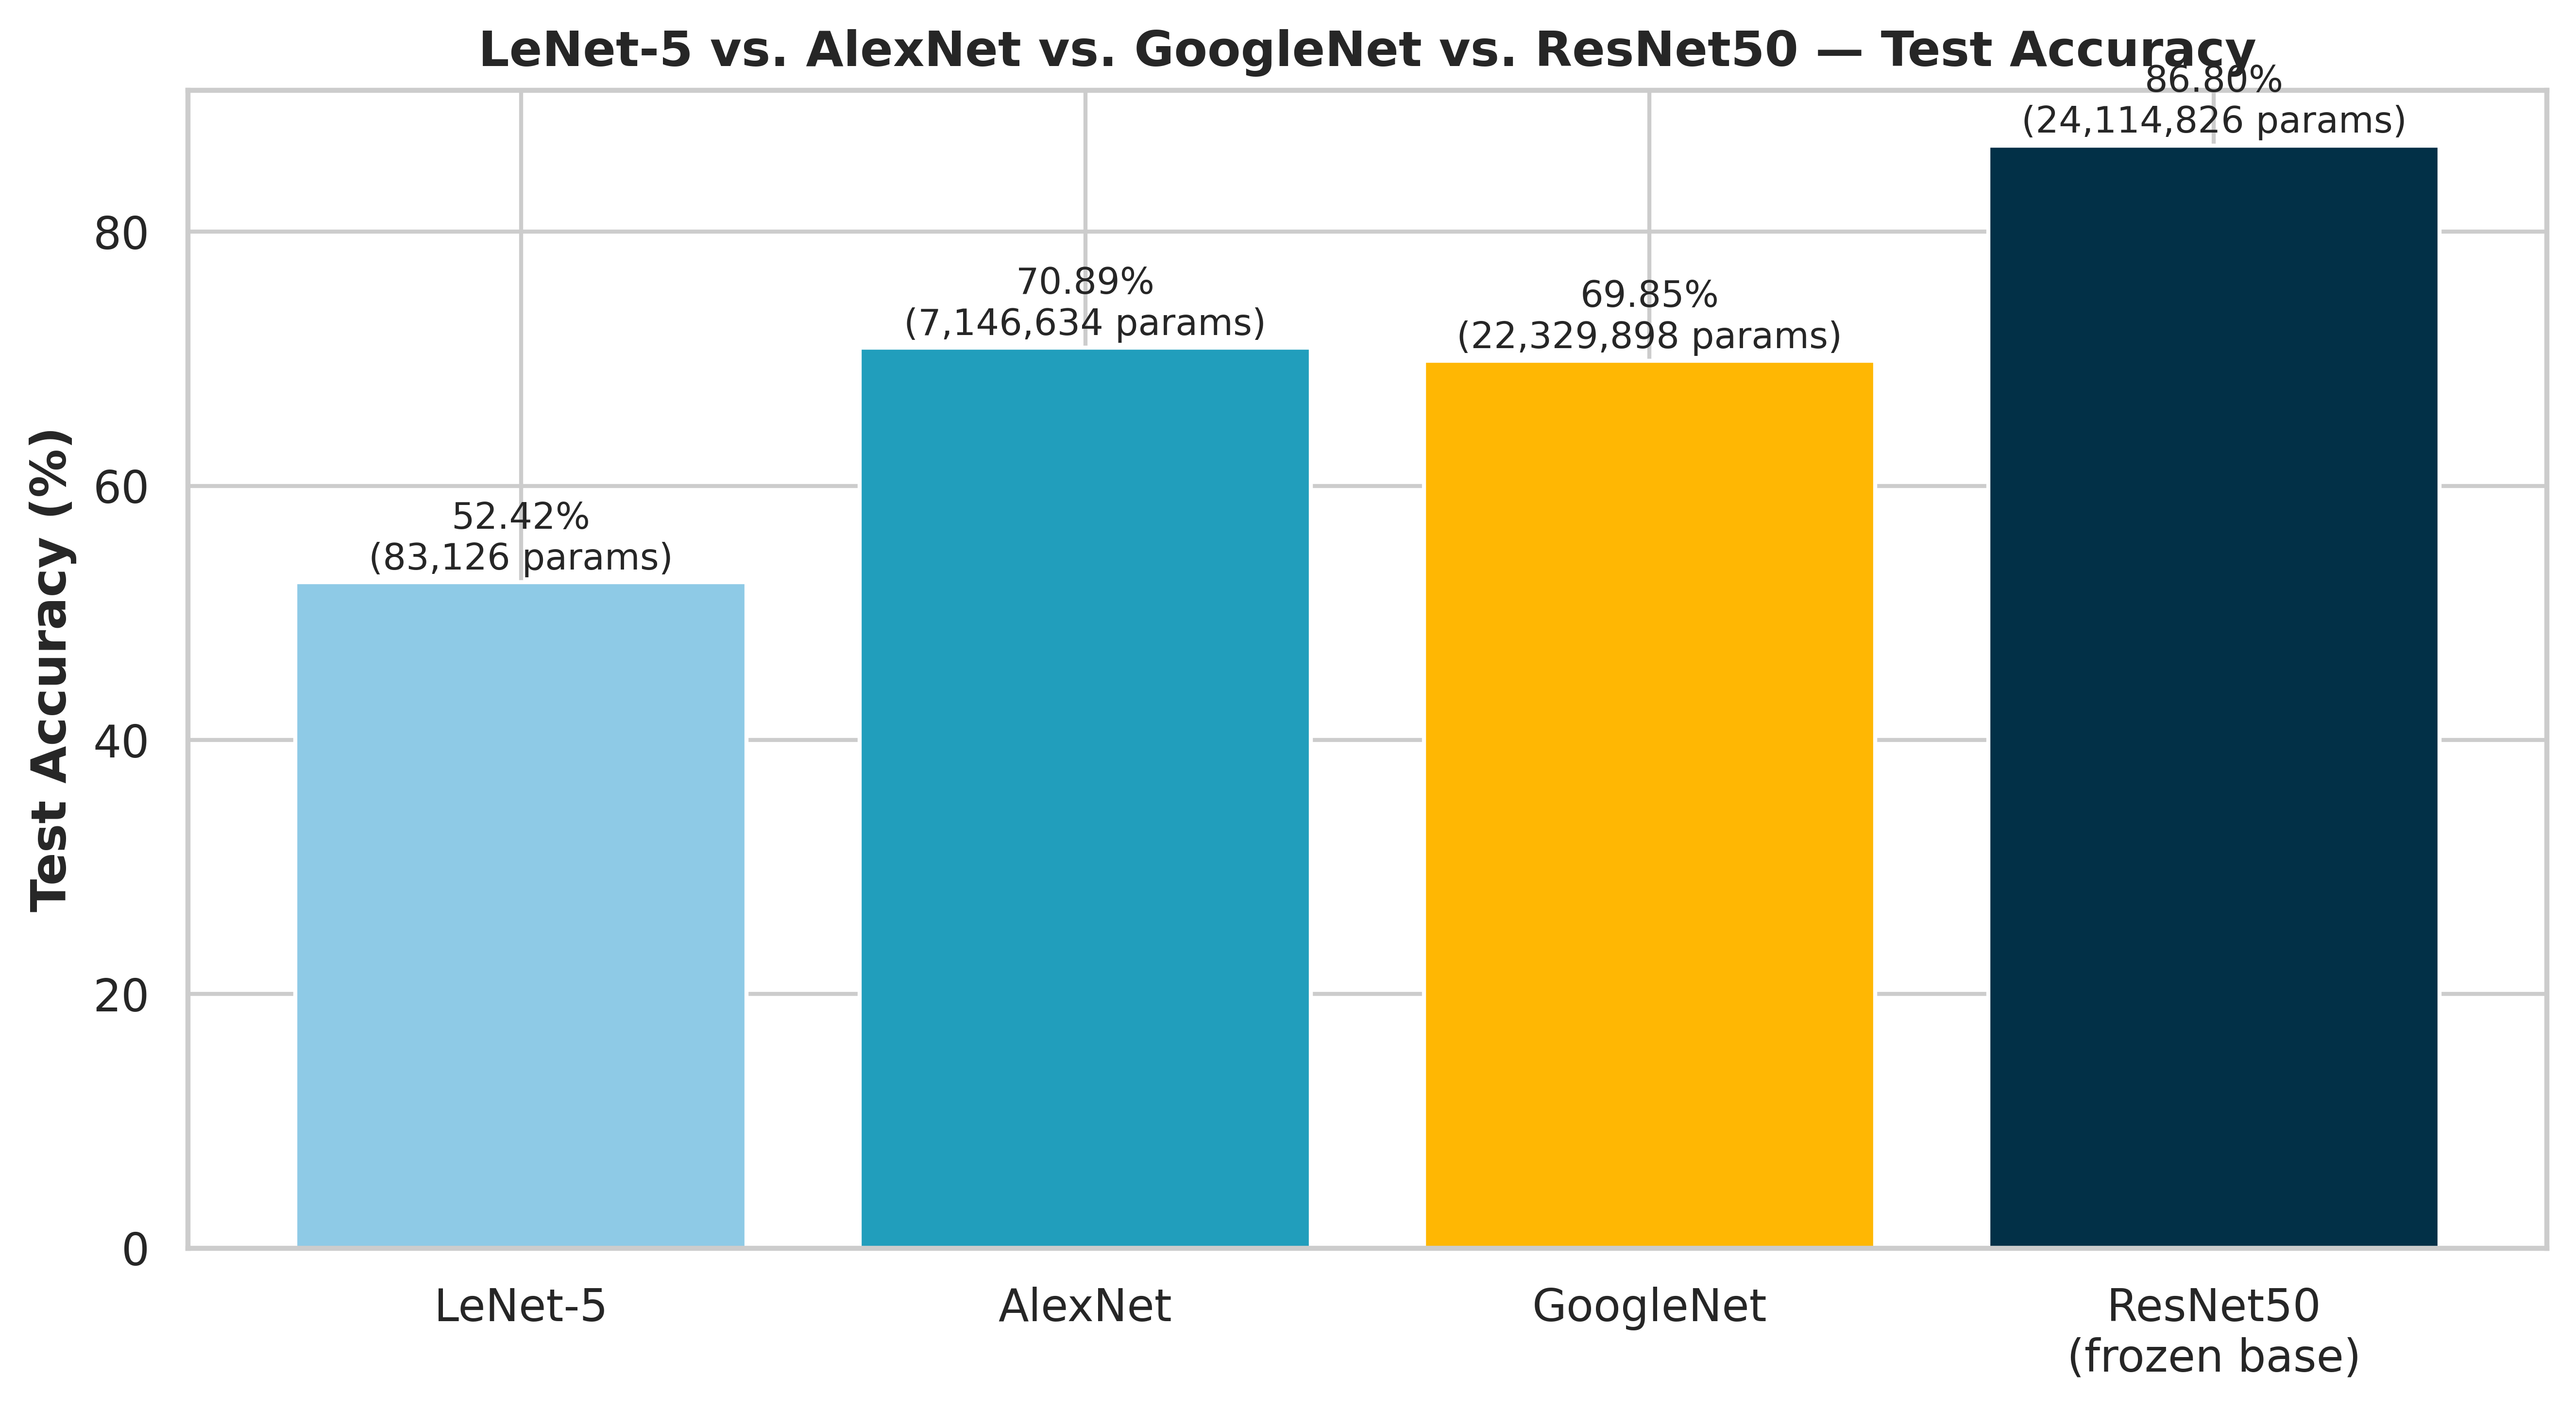

Model                Params   Test Acc (%)    Train Time (s)
LeNet-5              83,126          52.42             106.4
AlexNet           7,146,634          70.89             430.8
GoogleNet        22,329,898          69.85             470.0
ResNet50         24,114,826          86.80             452.0


In [52]:
# --- Final LeNet-5 / AlexNet / GoogleNet / ResNet50 comparison ---
final_comparison_fig = plt.figure(figsize=(9, 5))
models_cmp = ['LeNet-5', 'AlexNet', 'GoogleNet', 'ResNet50\n(frozen base)']
acc_cmp = [lenet_test_acc*100, alexnet_test_acc*100, googlenet_test_acc*100, resnet_test_acc*100]
params_cmp = [lenet_model.count_params(), alexnet_model.count_params(),
              googlenet_model.count_params(), resnet_model.count_params()]
time_cmp = [lenet_train_time, alexnet_train_time, googlenet_train_time, 452]

bars = plt.bar(models_cmp, acc_cmp, color=['#8ecae6', '#219ebc', '#ffb703', '#023047'])
plt.ylabel('Test Accuracy (%)')
plt.title('LeNet-5 vs. AlexNet vs. GoogleNet vs. ResNet50 — Test Accuracy')
for bar, acc, p in zip(bars, acc_cmp, params_cmp):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
              f'{acc:.2f}%\n({p:,} params)', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('lenet_alexnet_googlenet_resnet_comparison.eps', format='eps')
plt.show()

print(f"{'Model':<12}{'Params':>15}{'Test Acc (%)':>15}{'Train Time (s)':>18}")
for name, p, acc, t in zip(models_cmp, params_cmp, acc_cmp, time_cmp):
    print(f"{name.split(chr(10))[0]:<12}{p:>15,}{acc:>15.2f}{t:>18.1f}")

**Inference:** *(Write this once the cell above has actually run — the real comparison depends on `resnet_test_acc`, which isn't known until ResNet50 finishes training. As a general expectation: ResNet50's frozen-base features are usually at least competitive with VGG16's, sometimes ahead of it even without fine-tuning, since ResNet50's residual connections let it learn a deeper, more refined set of ImageNet features than VGG16's plainer stack of convolutions — but this is a general tendency, not a guarantee, and the bar chart above is what actually determines it for this dataset.)*

### 23.6 Re-Download All EPS Plots (Including ResNet50)

The original download cell (Section 15) ran before this section existed, so it doesn't include `confusion_matrix_resnet50.eps` or `vgg16_vs_resnet50_comparison.eps`. This cell repeats the zip/download step so the final archive actually contains everything.


In [53]:
import glob
import zipfile

eps_files = glob.glob("*.eps")
print(f"Found {len(eps_files)} EPS files:")
for eps_file in sorted(eps_files):
    print(" -", eps_file)

with zipfile.ZipFile("cnn_transfer_learning_eps_plots_complete.zip", "w") as zip_file:
    for eps_file in eps_files:
        zip_file.write(eps_file)

print("\nZIP archive created: cnn_transfer_learning_eps_plots_complete.zip")

try:
    from google.colab import files
    files.download("cnn_transfer_learning_eps_plots_complete.zip")
except ImportError:
    print("Not running in Google Colab — the ZIP file is saved in the current working directory. "
          "Download it manually from the file browser (left sidebar in Jupyter) if needed.")


Found 16 EPS files:
 - batch_size_comparison.eps
 - confusion_matrix.eps
 - confusion_matrix_resnet50.eps
 - epochs_comparison.eps
 - finetuning_comparison.eps
 - learning_rate_comparison.eps
 - lenet_alexnet_googlenet_resnet_comparison.eps
 - lenet_alexnet_resnet_comparison.eps
 - misclassified_images.eps
 - optimizer_comparison.eps
 - sample_images.eps
 - training_accuracy.eps
 - training_loss.eps
 - validation_accuracy.eps
 - validation_loss.eps
 - vgg16_vs_resnet50_comparison.eps

ZIP archive created: cnn_transfer_learning_eps_plots_complete.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>